In [3]:
import os
import numpy as np
import pandas as pd
#import scanpy as sc
import pyranges as pr
import warnings
pd.options.mode.chained_assignment = None  # default='warn'

In [4]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
import matplotlib.colors as colors
import seaborn as sns

from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
from scipy import stats
from tabulate import tabulate
from sklearn.decomposition import PCA
import os
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [6]:
%matplotlib inline
# figure size & color
matplotlib.rcParams['figure.dpi'] = 100 # 150 dpi resolution
matplotlib.rcParams['image.cmap'] = 'Spectral_r' # preferred color map
matplotlib.rcParams['figure.figsize'] = [8, 8] # Square
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


# no bounding boxes or axis:
matplotlib.rcParams['axes.spines.bottom'] = "on"
matplotlib.rcParams['axes.spines.top'] = "on"
matplotlib.rcParams['axes.spines.left'] = "on"
matplotlib.rcParams['axes.spines.right'] = "on"
warnings.filterwarnings(action="ignore", module="matplotlib", message="findfont")

In [7]:
font = {#'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 15}

matplotlib.rc('font', **font)
matplotlib.rcParams['axes.linewidth'] = 2 #set the value globally

In [8]:
fig_dir = 'figures'
# c074 writes RNAPII_cellCycle_0.0001.csv here. The raw (disabled) cell c025
# used a lab share; this keeps the live write inside the repo.
out_dir = fig_dir

# helper functions

In [9]:
import numpy as np

def van_der_corput(n, base=2):
    """
    Generate n terms of a van der Corput sequence in [0, 1).
    """
    seq = np.zeros(n, dtype=float)
    for i in range(n):
        x = i + 1  # start at 1 to avoid all zeros
        vdc = 0.0
        denom = 1.0
        while x > 0:
            x, remainder = divmod(x, base)
            denom *= base
            vdc += remainder / denom
        seq[i] = vdc
    return seq


def quasirandom_offsets(y, width=0.4, nbins=None):
    """
    Compute horizontal offsets for points y using a quasirandom layout
    similar in spirit to ggbeeswarm::geom_quasirandom.

    Parameters
    ----------
    y : array-like
        1D array of y-values (single group/category).
    width : float
        Maximum total horizontal spread (in x-units).
    nbins : int, optional
        Number of vertical bins for density-ish calculation.
        Defaults to round(sqrt(n_points)).

    Returns
    -------
    offsets : np.ndarray
        1D array of x-offsets (same length/order as y).
    """
    y = np.asarray(y, dtype=float)
    offsets = np.zeros_like(y, dtype=float)

    # mask NaNs, operate only on valid values
    mask = ~np.isnan(y)
    y_valid = y[mask]
    if y_valid.size == 0:
        return offsets

    n = y_valid.size
    if nbins is None:
        nbins = max(5, int(round(np.sqrt(n))))

    # vertical bins
    ymin, ymax = y_valid.min(), y_valid.max()
    if ymin == ymax:
        # all points at same y => just place them quasirandomly in full width
        seq = van_der_corput(n) - 0.5   # [-0.5, 0.5)
        offsets[mask] = seq * width
        return offsets

    edges = np.linspace(ymin, ymax, nbins + 1)
    bin_idx = np.digitize(y_valid, edges) - 1
    bin_idx = np.clip(bin_idx, 0, nbins - 1)

    # counts per bin → scale width by relative bin density
    counts = np.bincount(bin_idx, minlength=nbins)
    max_count = counts.max()
    bin_halfwidths = (width / 2.0) * (counts / max_count)  # 0..width/2

    offsets_valid = np.zeros_like(y_valid, dtype=float)

    for b in range(nbins):
        idx = np.where(bin_idx == b)[0]
        if idx.size == 0 or bin_halfwidths[b] == 0.0:
            continue

        # van der Corput in [-0.5, 0.5), scaled by that bin's halfwidth
        seq = van_der_corput(idx.size) - 0.5
        offsets_valid[idx] = seq * (2.0 * bin_halfwidths[b])

    offsets[mask] = offsets_valid
    return offsets

import matplotlib.pyplot as plt

def geom_quasirandom(
    ax,
    data,
    x_col,
    y_col,
    order=None,
    width=0.4,
    nbins=None,
    colors=None,
    alpha=0.7,
    size=10,
    **scatter_kwargs,
):
    """
    Simple ggbeeswarm-style quasirandom scatter for 1D categories.

    Parameters
    ----------
    ax : matplotlib Axes
    data : pandas.DataFrame
    x_col, y_col : str
        Column names for category (x) and value (y).
    order : list, optional
        Order of categories on x-axis. Defaults to sorted unique.
    width, nbins : passed to quasirandom_offsets.
    colors : list, optional
        One color per category in 'order'. If None, let Matplotlib choose.
    alpha, size : appearance params for scatter.
    scatter_kwargs : passed through to ax.scatter.
    """
    import numpy as np

    if order is None:
        order = list(dict.fromkeys(data[x_col]))  # preserve first-seen order

    x_positions = np.arange(len(order))

    for i, cat in enumerate(order):
        sub = data.loc[data[x_col] == cat, y_col].dropna()
        if sub.empty:
            continue

        vals = sub.values
        dx = quasirandom_offsets(vals, width=width, nbins=nbins)
        x_base = np.full_like(vals, x_positions[i], dtype=float)

        color = None
        if colors is not None and i < len(colors):
            color = colors[i]

        ax.scatter(
            x_base + dx,
            vals,
            alpha=alpha,
            s=size,
            color=color,
            edgecolors="none",
            **scatter_kwargs,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(order)


In [10]:
import os
import pandas as pd
import numpy as np
import pyranges as pr

def annotate_center_overlap_multi(
    df: pd.DataFrame,
    beds,                                   # dict[label->path] or list[str]
    *,
    id_col: str = "genehancer_id",
    chrom_col: str = "seqnames",
    center_col: str = "center",
    zero_based: bool = True,                # False if center is 1-based inclusive
    flank: int = 0,                         # e.g., 250 -> test ±250bp around center
    col_prefix: str = "center_overlaps_"
) -> pd.DataFrame:
    """
    Add one boolean column per BED indicating whether a center-point interval
    (1 bp or ±flank window) overlaps any BED interval.

    Parameters
    ----------
    df : DataFrame with columns [id_col, chrom_col, center_col]
    beds : dict {label: bed_path} or list[str] (auto-names from filename)
    zero_based : if False, converts center to 0-based before building intervals
    flank : half-window size; 0 -> 1-bp at center
    """
    # Normalize beds into {label: path}
    if isinstance(beds, dict):
        bed_map = beds
    else:
        bed_map = {os.path.splitext(os.path.basename(p))[0]: p for p in beds}

    # Build 0-based, half-open intervals from center
    center = df[center_col].to_numpy()
    if zero_based:
        pos0 = center.astype(np.int64)
    else:
        pos0 = (center - 1).astype(np.int64)

    starts = pos0 - flank
    ends   = pos0 + flank + 1  # half-open

    pts_df = pd.DataFrame({
        "Chromosome": df[chrom_col].astype(str).to_numpy(),
        "Start": starts,
        "End": ends,
        id_col: df[id_col].astype(str).to_numpy(),
    })

    pts_pr = pr.PyRanges(pts_df)

    out = df.copy()
    ids = out[id_col].astype(str)

    for label, bed_path in bed_map.items():
        peaks_pr = pr.read_bed(bed_path)
        hits = pts_pr.join(peaks_pr)
        hit_ids = set(hits.df[id_col].astype(str))
        out[f"{col_prefix}{label}"] = ids.isin(hit_ids)

    return out


# load

In [11]:
marks = ['K27me3','K27me2','K27me1','K27ac','P2S25p']
dfs = []
for mark in marks:
    fp = f'data/2024/RepliTag/filtered_sams_WT_1.0/251113_DGE/{mark}/output.tsv'
    df = pd.read_csv(fp, sep='\t',index_col = 'Geneid')
    dfs.append(df)

# Add RT

In [12]:
df_path = 'data/2024/RepliTag/Matrices/coverage_scores_gencode.v44.basic.TSS-1000_TES_sorted_bulk.tab'
bins = pd.read_csv(df_path, sep='\t', header = 0)
bins.columns = ['chr','start','end','K27ac', 'K27me1', 'K27me2', 'K27me3', 'RNAPII', 'RT']

TSS_names_path = 'data/2024/K562_annotations/processed_beds/sorted/gencode.v44.basic.TSS-1000_TES_sorted.bed'
TSS_names = pd.read_csv(TSS_names_path, sep='\t', header = None)
TSS_names.columns = ['chr','str', 'end','none1','none2', 'strand','ENSEMBL','Geneid', 'gene']
TSS_names['ID'] = TSS_names['chr'].astype('str') + '_' + TSS_names['str'].astype('str') + '_' +TSS_names['end'].astype('str')
TSS_names.index = TSS_names['Geneid']
TSS_names

bins['ID'] = bins['chr'].astype('str') + '_' + bins['start'].astype('str') + '_' +bins['end'].astype('str')
bins = bins.merge(TSS_names[['ID', 'Geneid']], on='ID', how='left')
bins['RT'] = (bins['RT']/100).clip(upper =1)

# prepare the bins table with Geneid as its index
bins_idx = bins.set_index('Geneid')[['RT','chr','start','end']]
bins_idx = bins_idx.loc[~bins_idx.index.duplicated(keep='first')]

dfs = [
  df.join(bins_idx, how='left')
  for df in dfs
]
for df in dfs:
    df['ratio'] = df['min_RPKM']/df['max_RPKM']

# dilution

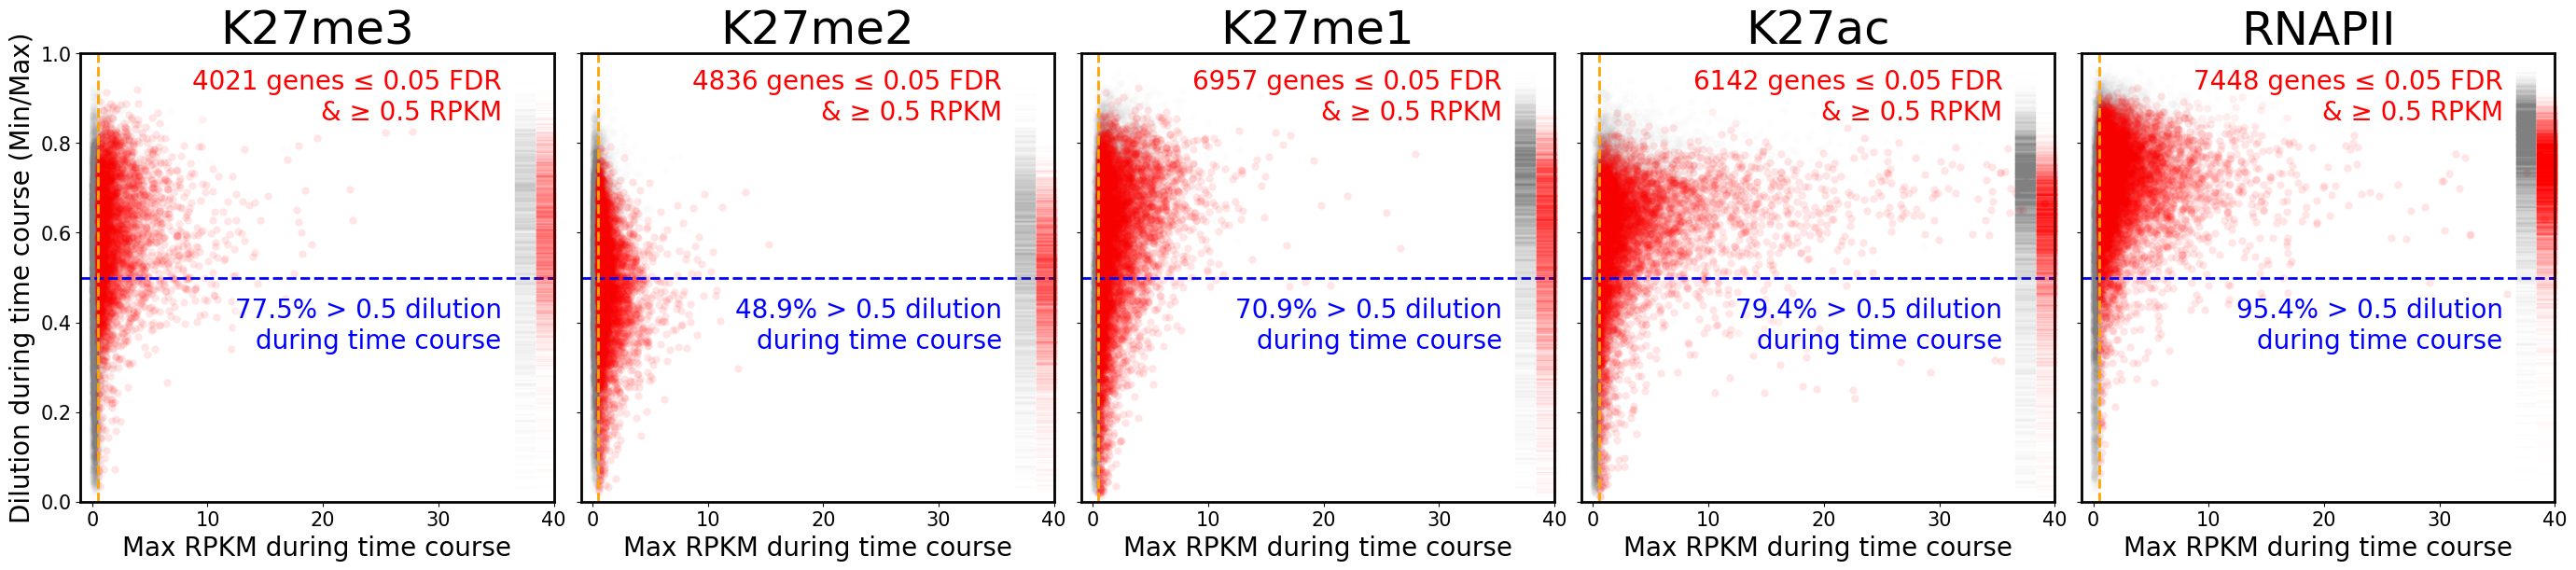

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

marks = ['K27me3','K27me2','K27me1','K27ac','RNAPII']

fig, axes = plt.subplots(1, len(dfs), figsize=(5.5 * len(dfs), 6), sharey=True, constrained_layout=True)

for ax, df, mark in zip(axes, dfs, marks):
    df = df[~df.index.str.startswith("TAF11L")].copy()
    
    fdr_col = 'FDR_allTP'
    rpkm_thresh = 0.5
    
    sig      = (df[fdr_col] <= 0.05) & (df['max_RPKM'] >= rpkm_thresh)
    nonsig   = (df[fdr_col] > 0.05) & (df['max_RPKM'] >= rpkm_thresh)
    df['ratio'] = df['min_RPKM']/df['max_RPKM']
    df = df[df['ratio'] != 0]
    
    # ✱ use nonsig instead of ~sig, and intersect
    sns.scatterplot(
        x=df.loc[~sig, 'max_RPKM'],
        y=df.loc[~sig, 'ratio'],
        color='gray', ax=ax, alpha=0.01, legend=False, linewidth=0
    )
    sns.scatterplot(
        x=df.loc[sig, 'max_RPKM'],
        y=df.loc[sig, 'ratio'],
        color='red', ax=ax, alpha=0.1, legend=False, linewidth=0
    )

    # right-side rugs (same masks to avoid NAs)
    divider  = make_axes_locatable(ax)
    ax_right = divider.append_axes("right", size="5%", pad=-0.2, sharey=ax)
    sns.rugplot(
        y=df.loc[sig, 'ratio'], color='red',
        height=0.9, lw=0.9, alpha=0.015, ax=ax_right, clip_on=False
    )
    sns.rugplot(
        y=df.loc[nonsig, 'ratio'], color='gray',
        height=-0.9, lw=0.9, alpha=0.015, ax=ax_right, clip_on=False
    )
    ax_right.axis('off')

    # axes/annotations unchanged...
    ax.set_xlabel('Max RPKM during time course', fontsize=20)
    ax.set_ylabel('Dilution during time course (Min/Max)', fontsize=20)
    ax.set_xlim(left=-1, right=40)
    ax.set_ylim(bottom=0, top=1)
    ax.set_title(mark, fontsize = 36)
    ax.axhline(y=0.5, color='blue', linestyle="--",lw = 2)
    ax.axvline(x=rpkm_thresh, color="orange", linestyle="--",lw = 2)

    sig_total = (sig).sum()
    sig_above_half = (sig & (df['ratio'] >= 0.5)).sum()
    percent_above = 100 * sig_above_half / sig_total if sig_total > 0 else 0

    ax.text(0.89, 0.84, f'{sig_total} genes ≤ 0.05 FDR\n& ≥ {rpkm_thresh} RPKM', color='red',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=20, 
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)) 
    ax.text(0.89, 0.33, f'{percent_above:.1f}% > 0.5 dilution\nduring time course', color='blue',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=20, 
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)) 

# plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Fig3a_MarkDilution.pdf"), bbox_inches="tight")

plt.show()


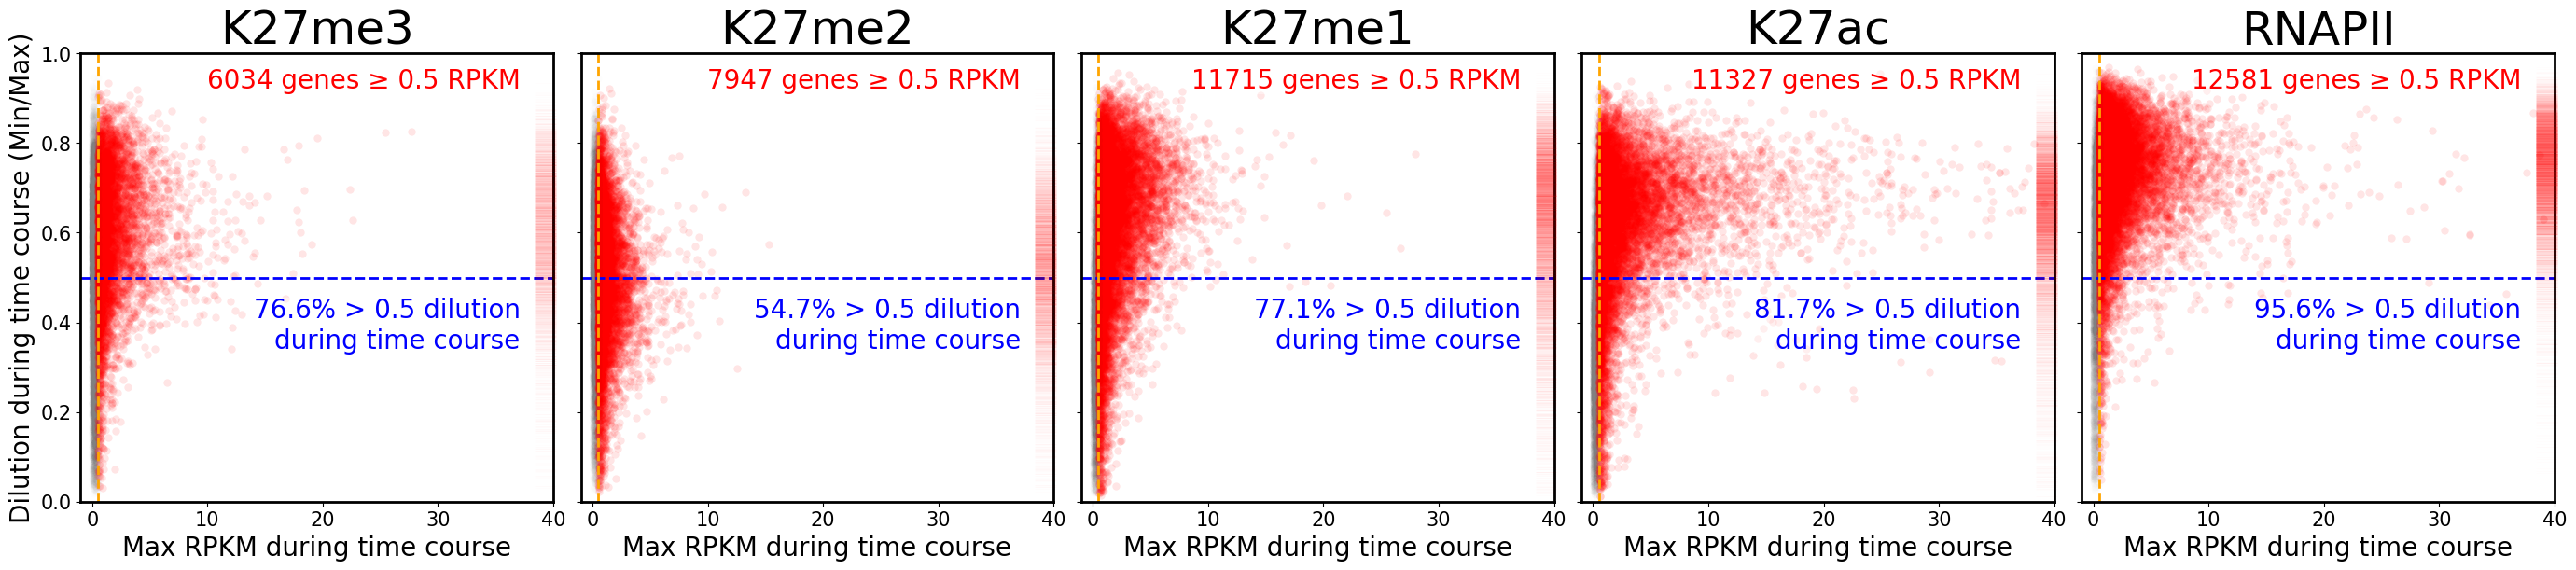

In [14]:
#no sig threshold

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

marks = ['K27me3','K27me2','K27me1','K27ac','RNAPII']

fig, axes = plt.subplots(1, len(dfs), figsize=(5.5 * len(dfs), 6), sharey=True, constrained_layout=True)

for ax, df, mark in zip(axes, dfs, marks):
    df = df[~df.index.str.startswith("TAF11L")].copy()
    
    fdr_col = 'FDR_allTP'
    rpkm_thresh = 0.5
    
    sig      = (df['max_RPKM'] >= rpkm_thresh)#(df[fdr_col] <= 0.05) & 
    nonsig   = (df['max_RPKM'] >= rpkm_thresh)#(df[fdr_col] > 0.05) & 
    df['ratio'] = df['min_RPKM']/df['max_RPKM']
    df = df[df['ratio'] != 0]
    
    # ✱ use nonsig instead of ~sig
    sns.scatterplot(
        x=df.loc[~sig, 'max_RPKM'],
        y=df.loc[~sig, 'ratio'],
        color='gray', ax=ax, alpha=0.01, legend=False, linewidth=0
    )
    sns.scatterplot(
        x=df.loc[sig, 'max_RPKM'],
        y=df.loc[sig, 'ratio'],
        color='red', ax=ax, alpha=0.1, legend=False, linewidth=0
    )

    # right-side rugs (same masks to avoid NAs)
    divider  = make_axes_locatable(ax)
    ax_right = divider.append_axes("right", size="5%", pad=-0.2, sharey=ax)
    sns.rugplot(
        y=df.loc[sig, 'ratio'], color='red',
        height=0.9, lw=0.9, alpha=0.007, ax=ax_right, clip_on=False
    )
    # sns.rugplot(
    #     y=df.loc[nonsig, 'ratio'], color='gray',
    #     height=-0.9, lw=0.9, alpha=0.015, ax=ax_right, clip_on=False
    # )
    ax_right.axis('off')

    # axes/annotations unchanged...
    ax.set_xlabel('Max RPKM during time course', fontsize=20)
    ax.set_ylabel('Dilution during time course (Min/Max)', fontsize=20)
    ax.set_xlim(left=-1, right=40)
    ax.set_ylim(bottom=0, top=1)
    ax.set_title(mark, fontsize = 36)
    ax.axhline(y=0.5, color='blue', linestyle="--",lw = 2)
    ax.axvline(x=rpkm_thresh, color="orange", linestyle="--",lw = 2)

    sig_total = (sig).sum()
    sig_above_half = (sig & (df['ratio'] >= 0.5)).sum()
    percent_above = 100 * sig_above_half / sig_total if sig_total > 0 else 0

    ax.text(0.93, 0.91, f'{sig_total} genes ≥ {rpkm_thresh} RPKM', color='red',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=20, 
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)) 
    ax.text(0.93, 0.33, f'{percent_above:.1f}% > 0.5 dilution\nduring time course', color='blue',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=20, 
            bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', pad=0.2)) 

# plt.tight_layout()
plt.show()


# Roadmap classification

In [15]:
dom_fp = 'data/2024/ENCODE_states/K562_E123_15_coreMarks_domains.bed'
dom = pd.read_csv(dom_fp, sep='\t', index_col=None,header = None)
dom.columns = ['chr', 'start', 'end']
genes = dfs[0][['chr', 'start', 'end','max_RPKM']].copy()

In [16]:
import numpy as np
import pandas as pd

def add_domain_frac(genes: pd.DataFrame, dom: pd.DataFrame, out="frac_overlap_domains") -> pd.DataFrame:
    g0 = genes[['chr','start','end']].copy().reset_index(drop=False)  # keep original index as a column
    d  = dom[['chr','start','end']].copy()

    g0[['start','end']] = g0[['start','end']].astype(np.int64)
    d[['start','end']]  = d[['start','end']].astype(np.int64)

    glen = (g0.end - g0.start).to_numpy()
    out_bp = np.zeros(len(g0), dtype=np.int64)

    # pre-split domains by chr (fast lookup)
    d_by_chr = {c: x[['start','end']].to_numpy()[np.argsort(x['start'].to_numpy())]
                for c, x in d.groupby('chr', sort=False)}

    for c, sub in g0.groupby('chr', sort=False):
        di = d_by_chr.get(c)
        if di is None or di.size == 0:
            continue

        ds, de = di[:, 0], di[:, 1]
        idx = sub.index.to_numpy()                 # positional row indices (int)
        gs  = sub['start'].to_numpy()
        ge  = sub['end'].to_numpy()

        hi = np.searchsorted(ds, ge, side="left")
        lo = np.searchsorted(de, gs, side="right")

        for k in range(idx.size):
            a, b = lo[k], hi[k]
            if a >= b:
                continue
            ov = np.minimum(ge[k], de[a:b]) - np.maximum(gs[k], ds[a:b])
            out_bp[idx[k]] = ov[ov > 0].sum()

    genes2 = genes.copy()
    genes2[out] = np.divide(out_bp, glen, out=np.zeros(len(g0), dtype=float), where=glen > 0)
    return genes2

genes = add_domain_frac(genes, dom)
genes = genes[~genes.index.str.startswith("TAF11L") & ~genes.index.str.startswith("FAM90A") & ~genes.index.str.startswith("USP17L")]
genes

,chr,start,end,max_RPKM,frac_overlap_domains
Geneid,,,,,
OR4F5,chr1,64418,71585,0.063833,0.000000
OR4F29,chr1,450739,452678,0.269004,0.000000
OR4F16,chr1,685715,687654,0.246672,0.000000
SAMD11,chr1,922922,944575,6.382133,0.535723
NOC2L,chr1,944202,960309,0.357943,0.000000
...,...,...,...,...,...
BPY2B,chrY,24606559,24639207,0.000994,0.000000
DAZ3,chrY,24763068,24814492,0.023883,0.000000
DAZ4,chrY,24832842,24907040,0.009739,0.000000


,chr,start,end,max_RPKM,frac_overlap_domains
Geneid,,,,,
SAMD11,chr1,922922,944575,6.382133,0.535723
PLEKHN1,chr1,965481,975865,1.815246,0.000000
PERM1,chr1,975197,983117,12.051852,0.820328
HES4,chr1,998961,1001172,0.704085,0.000000
RNF223,chr1,1070966,1075306,1.348867,0.111982
...,...,...,...,...,...
ENSG00000284987,chrX,153872220,153910223,0.846289,0.000000
TKTL1,chrX,154294794,154330350,1.063903,0.000000
CTAG1A,chrX,154584132,154586816,0.637757,0.000000


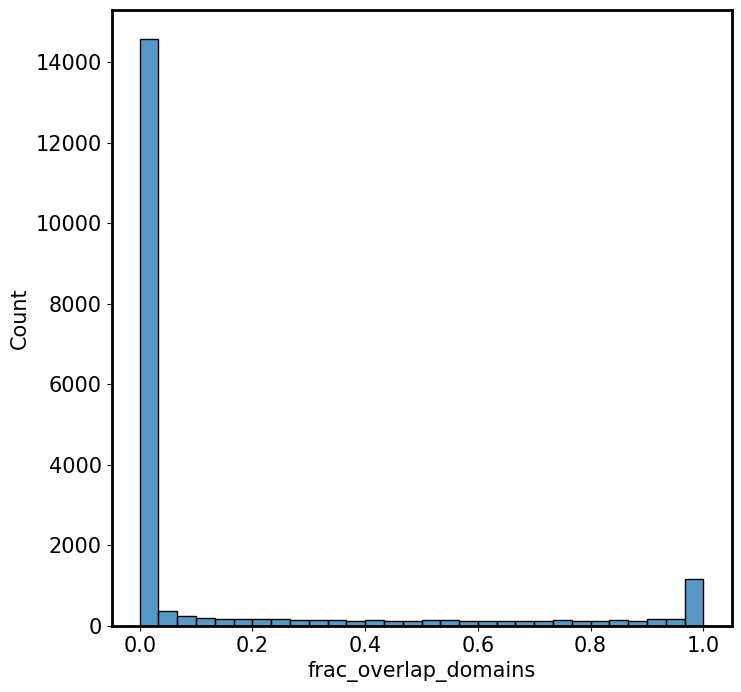

In [17]:
genes = genes[~genes.index.str.startswith("TAF11L") & ~genes.index.str.startswith("FAM90A") & ~genes.index.str.startswith("USP17L")]
sns.histplot(genes, x = 'frac_overlap_domains', bins = 30)
len(genes[genes['frac_overlap_domains']>0.5])
genes[genes['max_RPKM'] >= 0.5]

2861

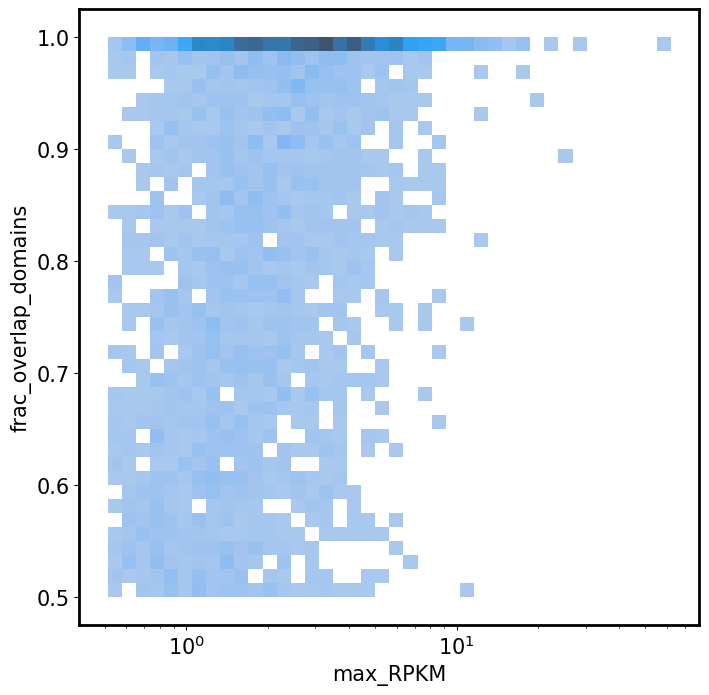

In [18]:
sub = genes[genes['frac_overlap_domains']>0.5].copy()
sub.sort_values(by = 'frac_overlap_domains',ascending = False, inplace=True)
sub = sub[sub['max_RPKM'] >= 0.5]
sns.histplot(sub, x = sub['max_RPKM']+0.01, y = 'frac_overlap_domains', log_scale = (True,False), bins = 40)#, cmap='mako_r')
len(sub)

In [19]:
import numpy as np
import pandas as pd
from functools import reduce

# Inputs expected:
# - reordered_dfs: list of 5 DataFrames [me3, me2, me1, ac, rna]
#   each indexed by gene_id, with 'Length' and *_meanCPM columns
# - Fullwood_me3, Fullwood_ac: DataFrames with a 'class' column and index=gene_id

MIN_RPKM = 0.5 # change your threshold here
MARK_COLS = ["me3", "me2", "me1", "ac"]  # tie-break order for idxmax

# --- Super sets (no ref_shape dependency) ---
me3_super = sub.index

# --- Helper: max RPKM (no log), skip TAF11L* and _WT_ lanes ---
def max_rpkm(df: pd.DataFrame, genes: pd.Index) -> pd.Series:
    sub = df.loc[~df.index.to_series().str.startswith("TAF11L")].copy()
    rpkm = sub['max_RPKM']
    return rpkm.reindex(genes, fill_value=0.0)

# --- Universe of genes across marks (skip TAF11L*) ---
all_idx = [df.index if hasattr(df, "index") else pd.Index([]) for df in dfs]
genes_all = reduce(pd.Index.union, all_idx)
genes_all = genes_all[~genes_all.to_series().str.startswith("TAF11L") & ~genes_all.to_series().str.startswith("FAM90A") & ~genes_all.to_series().str.startswith("USP17L")]

# --- Start with super assignments (prefer me3 if in both) ---
assign = pd.Series(index=genes_all, dtype="string")
assign.loc[me3_super] = "me3_domain"

# --- Remaining genes: assign by argmax of RPKM with threshold ---
remaining = assign[assign.isna()].index

rpkm_df = pd.DataFrame({
    "me3": max_rpkm(dfs[0], remaining),
    "me2": max_rpkm(dfs[1], remaining),
    "me1": max_rpkm(dfs[2], remaining),
    "ac":  max_rpkm(dfs[3], remaining),
}).reindex(remaining)

row_max = rpkm_df[MARK_COLS].max(axis=1)
argmax_mark = rpkm_df[MARK_COLS].idxmax(axis=1)

eligible = row_max >= MIN_RPKM
assign.loc[eligible.index[eligible]] = argmax_mark.loc[eligible].astype("string")
assign.loc[eligible.index[~eligible]] = "Unassigned"

# --- Results ---
counts = assign.value_counts()
print(counts)


ac            6694
me1           3877
me3_domain    2861
Unassigned    2635
me2           2278
me3           1601
Name: count, dtype: Int64


/loc/scratch/59465656/ipykernel_5709/1094635695.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['' for _ in categories])
/loc/scratch/59465656/ipykernel_5709/1094635695.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['' for _ in categories])
/loc/scratch/59465656/ipykernel_5709/1094635695.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['' for _ in categories])
/loc/scratch/59465656/ipykernel_5709/1094635695.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['' for _ in categories])
/loc/scratch/59465656/ipykernel_5709/1094635695.py:58: UserWarning: set_ticklabe

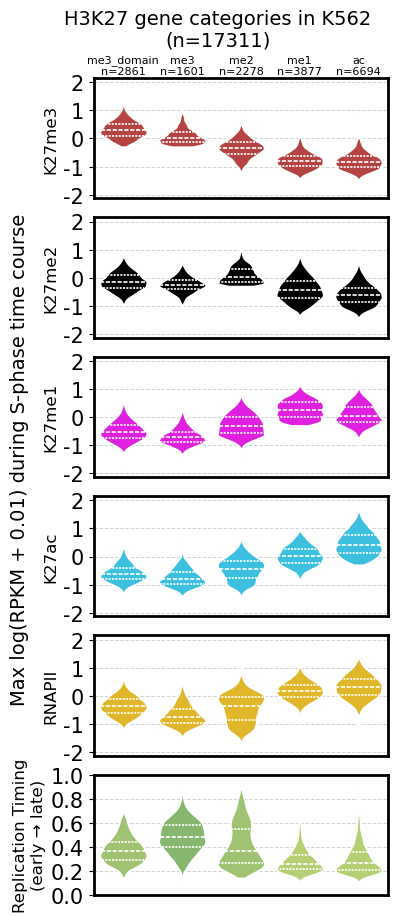

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import colormaps as cm
# ——— Setup ———
categories = ['me3_domain', 'me3','me2', 'me1', 'ac']
row_colors = ["#C73131", "#000000", "#FF00FF", "#22D0FB", "#FFC60B"]
marks = ["K27me3", "K27me2", "K27me1", "K27ac", "RNAPII"]
n_rows = len(dfs)

fig, axes = plt.subplots(n_rows + 1, 1, figsize=(4, 9), sharex=True, sharey=False)

# ——— RT violin plot (last panel) ———
rt_data = 1-bins_idx.reindex(genes_all)[['RT']].copy()
rt_data['shape_category'] = assign
rt_plot_df = pd.concat([
    rt_data[rt_data['shape_category'] == cat].assign(Category=cat)
    for cat in categories
])
n_genes = len(assign[assign != 'Unassigned'])
# ——— Plot histone/RNAPII violins ———
for i, df in enumerate(dfs):
    df2 = df.loc[:, ~df.columns.str.contains("_WT_")].copy()
    df2 = df2[~df2.index.str.startswith("TAF11L") & ~df2.index.str.startswith("FAM90A") & ~df2.index.str.startswith("USP17L")]
    df2 = df2.reindex(genes_all)
    df2['max_val'] = df2['max_RPKM'] + 0.01

    df2['shape_category'] = assign
    plot_df = pd.concat([
        df2[df2['shape_category'] == cat].assign(Category=cat)
        for cat in categories
    ])

    ax = axes[i]
    sns.violinplot(
        data=plot_df,
        x='Category',
        y='max_val',
        ax=ax,
        color=row_colors[i],
        cut=0,
        inner='quartile',
        linecolor="white",
        density_norm='width',
        log_scale=True,
        linewidth=1.2,
        zorder=2
    )
    ax.set_yscale('log')
    ax.set_yticks([0.01, 0.1, 1, 10, 100])
    ax.set_yticklabels([-2, -1, 0, 1, 2])
    ax.set_ylim(0.0075, 140)
    ax.set_xlabel('')
    ax.set_ylabel(marks[i], fontsize=12)
    ax.grid(axis='y', color='lightgray', linestyle='--', linewidth=0.7, zorder=1)
    ax.set_xticklabels(['' for _ in categories])
    ax.tick_params(axis='x', length=0)

    if i == 0:
        labs = categories
        for tick, (cat, label) in enumerate(zip(categories, labs)):
            n = (rt_data['shape_category'] == cat).sum()
            ax.text(tick, 160, f"{label}\nn={n}", ha='center', va='bottom', fontsize=8)

# Step 1: Compute medians
medians = rt_plot_df.groupby("Category")["RT"].median()

# Step 2: Normalize median values for colormap
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = cm.get_cmap("summer_r")
category_colors = {cat: cmap(norm(val)) for cat, val in medians.items()}

# Step 3: Plot one violin per category
ax = axes[-1]
ax = plt.gca()

for i, cat in enumerate(categories):
    subset = rt_plot_df[rt_plot_df["Category"] == cat]
    
    sns.violinplot(
        data=subset,
        x='Category',
        y='RT',
        ax=ax,
        color=category_colors[cat],
        cut=0,
        inner='quartile',
        linecolor="white",
        density_norm='width',
        zorder=2,
        linewidth=1.2
    )
ax.set_ylim(0, 1)
ax.set_ylabel("Replication Timing\n(early → late)", fontsize=12)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.grid(axis='y', color='lightgray', linestyle='--', linewidth=0.7, zorder=1)
ax.set_xticklabels(['' for _ in categories])
ax.set_xlabel('')
ax.tick_params(axis='x', length=0)

# ——— Final Labels ———
fig.supylabel("Max log(RPKM + 0.01) during S-phase time course", fontsize=14, x=0.05)
fig.suptitle(f'H3K27 gene categories in K562\n(n={n_genes})', x=0.57, y=1.0,fontsize=14)

plt.tight_layout(pad = .1, rect=[0.00, 0, 1, 1])
fig.savefig(os.path.join(fig_dir, "20260205_Sup4a_genesByMaxRPKM.pdf"), bbox_inches="tight")

plt.show()


/loc/scratch/59465656/ipykernel_5709/3641680015.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pct.index, rotation=90, fontsize=12)


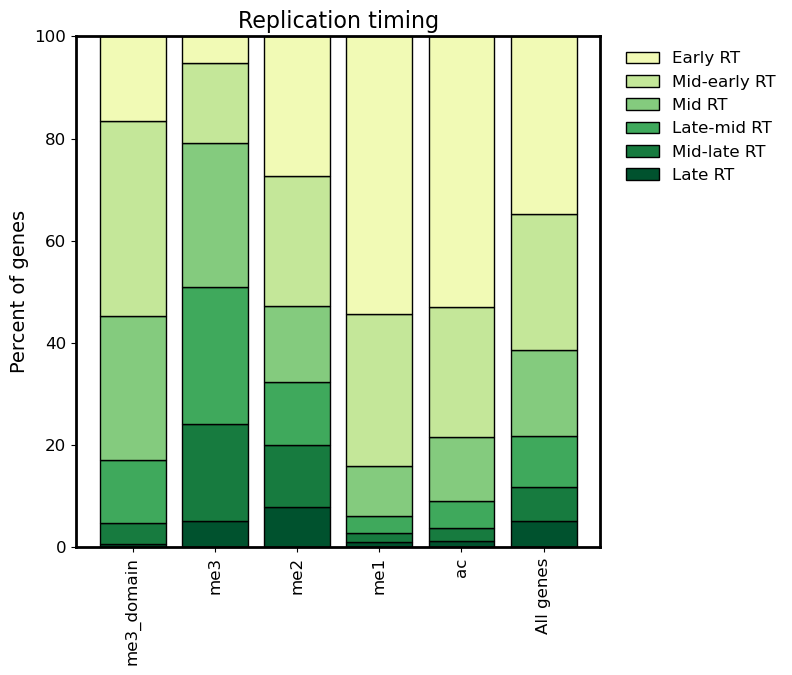

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Bins and labels (Early → Late) ----
#rt_bins   = [0, 0.25, 0.3, 0.4, 0.5, 0.6, 1]
# rt_labels = [
#     "Early RT (0.1–0.25)",
#     "Mid-early RT (0.25–0.3)",
#     "Mid RT (0.3–0.4)",
#     "Late-mid RT (0.4–0.5)",
#     "Mid-late RT (0.5–0.6)",
#     "Late RT (0.6–0.8)",
# ]

from scipy import stats
# rt_bins = stats.mstats.mquantiles(rt_data['RT'].dropna(), [0, 1/6, 2/6, 3/6, 4/6, 5/6, 1])
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num = 7
)
rt_bins[0] = 0
rt_bins[6] = 1
rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

# ---- Data prep ----
df = rt_data.dropna(subset=["RT", "shape_category"]).copy()
df["RT_bin"] = pd.cut(df["RT"], bins=rt_bins, labels=rt_labels, include_lowest=True)

# % within each shape_category
pct = pd.crosstab(df["shape_category"], df["RT_bin"], normalize="index") * 100
pct = pct.reindex(columns=rt_labels, fill_value=0)

# Overall “All genes”
overall = (df["RT_bin"].value_counts(normalize=True) * 100).reindex(rt_labels, fill_value=0)
pct.loc["All genes"] = overall

# Order categories on x-axis
x_order = ["me3_domain", "me3", "me2", "me1", "ac", "All genes"]
x_order = [c for c in x_order if c in pct.index]
pct = pct.reindex(index=x_order)

# ---- Colors: Early → Late (light → dark) ----
cmap = plt.get_cmap("YlGn")
# avoid the very pale/yellow end; tweak bounds if you like
stops = np.linspace(0.15, 0.95, len(rt_labels))
palette = [cmap(s) for s in stops]
color_for = dict(zip(rt_labels, palette))  # Early..Late

# ---- Plot (stacked) ----
fig, ax = plt.subplots(figsize=(8.2, 7))
bottom = np.zeros(len(pct), dtype=float)

# stack Late → Early so Late bars are at the bottom
for label in reversed(rt_labels):
    vals = pct[label].values
    ax.bar(
        pct.index, vals,
        bottom=bottom,
        edgecolor="black", linewidth=1,
        color=color_for[label]
    )
    bottom += vals

ax.set_ylim(0, 100)
ax.set_ylabel("Percent of genes", fontsize=14)
ax.set_title("Replication timing", fontsize=16)
ax.set_xticklabels(pct.index, rotation=90, fontsize=12)
ax.tick_params(axis="y", labelsize=12)

# Legend built directly from the mapping (Early → Late)
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color_for[l], edgecolor="black")
           for l in rt_labels]
ax.legend(handles, rt_labels, loc="upper left",
          bbox_to_anchor=(1.02, 1), frameon=False, fontsize=12)

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Sup4b_genesByMaxRPKM_RT.pdf"), bbox_inches="tight")

plt.show()


In [22]:
rt_data[rt_data['shape_category'] == 'me3']

,RT,shape_category
Geneid,,
AJAP1,0.634072,me3
KCNAB2,0.326609,me3
ENSG00000285629,0.264073,me3
PRAMEF7,0.390233,me3
HNRNPCL3,NaN,me3
...,...,...
ATP2B3,0.324505,me3
PDZD4,0.220702,me3
L1CAM,0.212842,me3


In [22]:
rt_data.to_csv('data/2024/LAD_data/JG_coding_genes_maxRPKM.tsv',sep = '\t')

# GO

In [106]:
import pandas as pd
import numpy as np
import gseapy as gp
from statsmodels.stats.multitest import multipletests

# -----------------------------
# Config
# -----------------------------
gene_set_name = 'ENCODE_TF_ChIP-seq_2015'
outdir_base   = 'enrichr_results'   # parent folder; gseapy will create subfolders
filter_pattern = r'\bK562\b'        # keep only terms containing 'K562'
organism = 'Human'                  # change to 'Mouse' if needed
top_n = None                        # e.g., 100 to limit genes per category; None = use all

# -----------------------------
# Collect categories
# -----------------------------
cats = (
    rt_data['shape_category']
    .dropna()
    .astype(str)
    .unique()
)

# Optional: sort them in a stable order
cats = sorted(cats)

all_results = []

for cat in cats:
    # 1) Genes for this category
    sub = rt_data[rt_data['shape_category'] == cat].copy()
    genes = sub.index.astype(str).tolist()
    if top_n is not None:
        genes = genes[:top_n]  # keep first N if you want to limit
    
    if len(genes) == 0:
        continue  # skip empty categories

    # 2) Run Enrichr
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_set_name,
        organism=organism,
        outdir=f"{outdir_base}/{cat}",  # gseapy will create this
        cutoff=1                        # keep everything; we'll filter ourselves
    )

    res = enr.res2d.copy()
    if res is None or res.empty:
        continue

    # 3) Filter for K562 terms
    res = res[res['Term'].str.contains(filter_pattern, case=False, na=False)].copy()
    if res.empty:
        continue

    # 4) Recompute BH FDR from raw P-values
    # (Enrichr already provides 'Adjusted P-value' but we overwrite to be explicit/consistent)
    res['Adjusted P-value'] = multipletests(res['P-value'].values, method='fdr_bh')[1]

    # 5) Attach category & metadata you might want later
    res['cat'] = cat
    res['n_input_genes'] = len(genes)   # helpful downstream for Odds Ratio
    # Optional: ensure stable sort
    res = res.sort_values('Adjusted P-value').reset_index(drop=True)

    all_results.append(res)

# -----------------------------
# Combine all categories
# -----------------------------
combined_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# Peek
print(f"Combined rows: {len(combined_df)} across {len(cats)} categories")
display(combined_df.head(10))


Combined rows: 694 across 6 categories


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cat,n_input_genes
0,ENCODE_TF_ChIP-seq_2015,FOSL1 K562 hg19,20/849,0.999993,0.999996,0,0,0.152558,1.024054e-06,MAGI1;RBM25;GBE1;NBEAL1;HELZ;EFCAB11;NT5C2;SLF...,Unassigned,2635
1,ENCODE_TF_ChIP-seq_2015,TAF7 K562 hg19,17/793,0.999993,0.999996,0,0,0.138815,9.159408e-07,INTS12;GTF3C3;NUBPL;CSTF3;CCDC59;TMEM74;RNF6;S...,Unassigned,2635
2,ENCODE_TF_ChIP-seq_2015,GTF3C2 K562 hg19,17/773,0.999993,0.999996,0,0,0.142660,9.352298e-07,LRRC36;ZRANB3;ZNF582;CCDC14;RPA1;NBEAL1;RNASE4...,Unassigned,2635
3,ENCODE_TF_ChIP-seq_2015,GATA1 K562 hg19,29/727,0.999994,0.999996,0,0,0.265721,1.714854e-06,ITSN2;EXD1;ATP8A2;C2ORF66;CHM;ACSM4;FNBP1L;SCF...,Unassigned,2635
4,ENCODE_TF_ChIP-seq_2015,SIN3A K562 hg19,29/698,0.999994,0.999996,0,0,0.277722,1.773590e-06,EXD2;FCF1;POLD3;HMGXB4;CALB1;SESN1;VPS53;ZNF42...,Unassigned,2635
5,ENCODE_TF_ChIP-seq_2015,CEBPD K562 hg19,22/691,0.999994,0.999996,0,0,0.210121,1.338378e-06,ZNF221;ABCD3;HIBADH;CCDC138;PCGF5;CSTF3;MRPS31...,Unassigned,2635
6,ENCODE_TF_ChIP-seq_2015,STAT1 K562 hg19,15/345,0.999995,0.999996,0,0,0.295541,1.558123e-06,SP100;ZNF197;GINS3;UBR1;SCAMP1;BRCA2;PARP9;DDX...,Unassigned,2635
7,ENCODE_TF_ChIP-seq_2015,NELFE K562 hg19,1/334,0.999995,0.999996,0,0,0.019418,1.012678e-07,OR51B5,Unassigned,2635
8,ENCODE_TF_ChIP-seq_2015,MEF2A K562 hg19,6/316,0.999995,0.999996,0,0,0.125560,6.442752e-07,MEF2A;HEATR5A;MYO18B;CCDC59;TAS2R13;NUP88,Unassigned,2635
9,ENCODE_TF_ChIP-seq_2015,STAT2 K562 hg19,18/271,0.999821,0.999996,0,0,0.465210,8.332069e-05,CD274;SP100;TDRD7;UBR1;SCAMP1;BRCA2;PARP9;DDX6...,Unassigned,2635


/loc/scratch/46009368/ipykernel_9052/3617028795.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


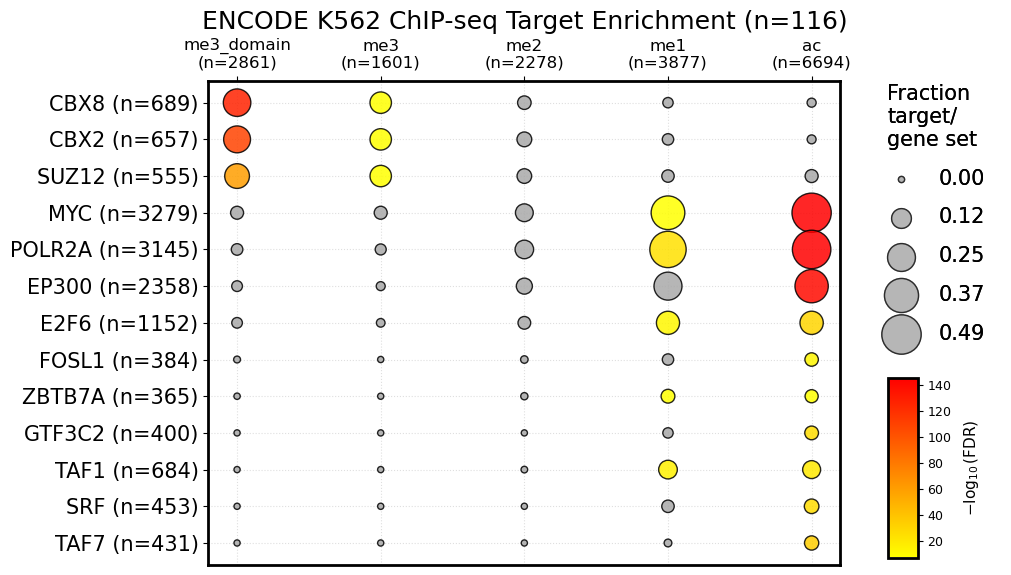

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import re

df = combined_df.copy()

# Parse counts and compute GeneRatio
df['genes_in_set'] = df['Overlap'].str.split('/').apply(lambda x: int(x[0]))
if 'n_input_genes' not in df.columns:
    raise ValueError("combined_df must include 'n_input_genes' per category to compute GeneRatio.")
df['GeneRatio'] = df['genes_in_set'] / df['n_input_genes'].astype(float)

# Clean TF names
def clean_tf(term: str) -> str:
    return term.split()[0] if isinstance(term, str) else term
df['TF'] = df['Term'].apply(clean_tf)

# Keep only top-3 per category
top_per_cat = (
    df.sort_values(['cat', 'Adjusted P-value'])
      .groupby('cat', group_keys=False)
      .head(3)
)
terms_keep = set(top_per_cat['Term'].unique())
df_keep = df[df['Term'].isin(terms_keep)].copy()

# --- Keep only Terms with GeneRatio >= 0.15 in at least one category ---
# gene_ratio_min = 0.15
# keep_terms = (
#     df_keep.groupby('Term', as_index=True)['GeneRatio']
#            .max()
#            .pipe(lambda s: s[s >= gene_ratio_min])
#            .index
# )
# df_keep = df_keep[df_keep['Term'].isin(keep_terms)].copy()

# Desired x order
desired_order = ['me3_domain','me3','me2','me1','ac']
cats_present = [c for c in desired_order if c in df_keep['cat'].unique()]
xpos = {c: i for i, c in enumerate(cats_present)}

# Sort y by GeneRatio in cat priority order
pivot = (
    df_keep.pivot_table(index='TF', columns='cat', values='GeneRatio', aggfunc='max')
          .reindex(columns=cats_present)
)
pivot = pivot.fillna(-np.inf)
pivot = pivot.sort_values(by=cats_present, ascending=[True]*len(cats_present))
terms = pivot.index.tolist()
ypos = {t: i for i, t in enumerate(terms)}

# Figure
fig, ax = plt.subplots(figsize=(max(10, 1.2*len(cats_present)), max(6, 0.45*len(terms))))

# Size scaling
gr = df_keep['GeneRatio']
size_scale = 800 / max(gr.max(), 1e-9)
sizes = np.clip(df_keep['GeneRatio'] * size_scale, 20, None)

# ---- Color + significance handling ----
df_keep['neglog10FDR'] = -np.log10(df_keep['Adjusted P-value'].clip(lower=np.finfo(float).tiny))

sig_thresh = 0.05
sig_mask = (df_keep['Adjusted P-value'] < sig_thresh).values

# Robust color range: prefer sig points
if sig_mask.any():
    vmin = np.quantile(df_keep.loc[sig_mask, 'neglog10FDR'], 0.05)
    vmax = np.quantile(df_keep.loc[sig_mask, 'neglog10FDR'], 0.95)
else:
    vmin = np.quantile(df_keep['neglog10FDR'], 0.05)
    vmax = np.quantile(df_keep['neglog10FDR'], 0.95)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.autumn_r

# Build RGBA colors and grey out non-sig
base_colors = cmap(norm(df_keep['neglog10FDR'].values))
base_colors[~sig_mask] = mcolors.to_rgba('darkgrey')
base_colors[~sig_mask, 3] = 0.5  # make non-sig slightly transparent

# Scatter plot
ax.scatter(
    df_keep['cat'].map(xpos),
    df_keep['TF'].map(ypos),
    s=sizes,
    c=base_colors,
    edgecolor='black',
    alpha=0.85,
    zorder = 2
)

# Count n genes per TF
n_genes_per_tf = df_keep.groupby('TF')['genes_in_set'].max().to_dict()

# Top x-axis
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xticks(range(len(cats_present)))
n_per_cat = df_keep.groupby('cat')['n_input_genes'].max().to_dict()
ax.set_xticklabels([f"{c}\n(n={n_per_cat.get(c, '?')})" for c in cats_present], fontsize =12)

# Y-axis with n genes per TF
ax.set_yticks(range(len(terms)))
ax.set_yticklabels([f"{tf} (n={n_genes_per_tf.get(tf, '?')})" for tf in terms])

ax.set_xlabel("")
ax.set_ylabel("")
n_TFs = len(combined_df['Term'].unique())
ax.set_title(f"ENCODE K562 ChIP-seq Target Enrichment (n={n_TFs})")

# Colorbar for significant values only
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cax = fig.add_axes([0.9, 0.05, 0.03, 0.3])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$-\log_{10}(\mathrm{FDR})$", fontsize=11, labelpad=8)
cbar.ax.tick_params(labelsize=9)

# Size legend
gr_ticks = np.linspace(df_keep['GeneRatio'].min(), df_keep['GeneRatio'].max(), 5)
gr_ticks = np.unique(np.round(gr_ticks, 3))
handles = [
    plt.scatter([], [], s=max(20, g*size_scale), edgecolor='black', facecolor='darkgray', alpha=0.6)
    for g in gr_ticks
]
labels = [f"{g:.2f}" for g in gr_ticks]
leg = ax.legend(handles, labels, title="Fraction\ntarget/\ngene set", frameon=False,
                loc='upper left', bbox_to_anchor=(1.02, 1.05),
                borderpad=0.8, labelspacing=0.9)
ax.add_artist(leg)

ax.grid(axis='both', linestyle=':', alpha=0.4, zorder = 1)

plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(os.path.join(fig_dir, "20260205_Sup4c_CHEA.pdf"), bbox_inches="tight")

plt.show()


# heatmaps

In [23]:
def get_norm_df(df, thresh=0):
    """
    Given a DataFrame for one histone mark, 
    filters, normalizes, and returns:
      - norm_df: genes × stage columns (G1, S1, S2, S3, S4, G2), values scaled 0–1
      - max_rpkm: Series of raw max RPKM per gene (before log)
    """

    # 1) drop WT samples & TAF11L‐prefixed genes
    df = df.loc[:, ~df.columns.str.contains("_WT_")].copy()
    df = df[~df.index.str.startswith("TAF11L")].copy()

    # 2) stages of interest and their meanCPM columns
    stages = ["G1", "S1", "S2", "S3", "S4", "G2"]
    mean_cols = [f"meanCPM_{s}" for s in stages if f"meanCPM_{s}" in df.columns]

    if not mean_cols:
        raise ValueError("No meanCPM_ columns for G1/S1/S2/S3/S4/G2 found in dataframe.")

    # 3) get raw max RPKM per gene (prefer existing column if present)
    max_rpkm = df[mean_cols].max(axis=1) / (df["Length"] / 1000)
    
    # 4) optional expression threshold
    if thresh is not None and thresh > 0:
        keep = max_rpkm >= thresh
        df = df.loc[keep].copy()
        max_rpkm = max_rpkm.loc[keep]

    # 5) normalize each gene's meanCPM profile to [0,1]
    sel = df[mean_cols].copy()
    row_max = sel.max(axis=1)
    nonzero = row_max != 0
    sel.loc[nonzero] = sel.loc[nonzero].div(row_max[nonzero], axis=0)

    # 6) ensure correct order, then strip 'meanCPM_' prefix so columns are just G1, S1, ...
    sel = sel[[f"meanCPM_{s}" for s in stages if f"meanCPM_{s}" in sel.columns]]
    sel.columns = [c.split("_", 1)[1] for c in sel.columns]  # -> ["G1","S1",...]

    return sel, max_rpkm


/loc/scratch/59465656/ipykernel_23270/1085414721.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/59465656/ipykernel_23270/1085414721.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/59465656/ipykernel_23270/1085414721.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
/loc/scratch/594

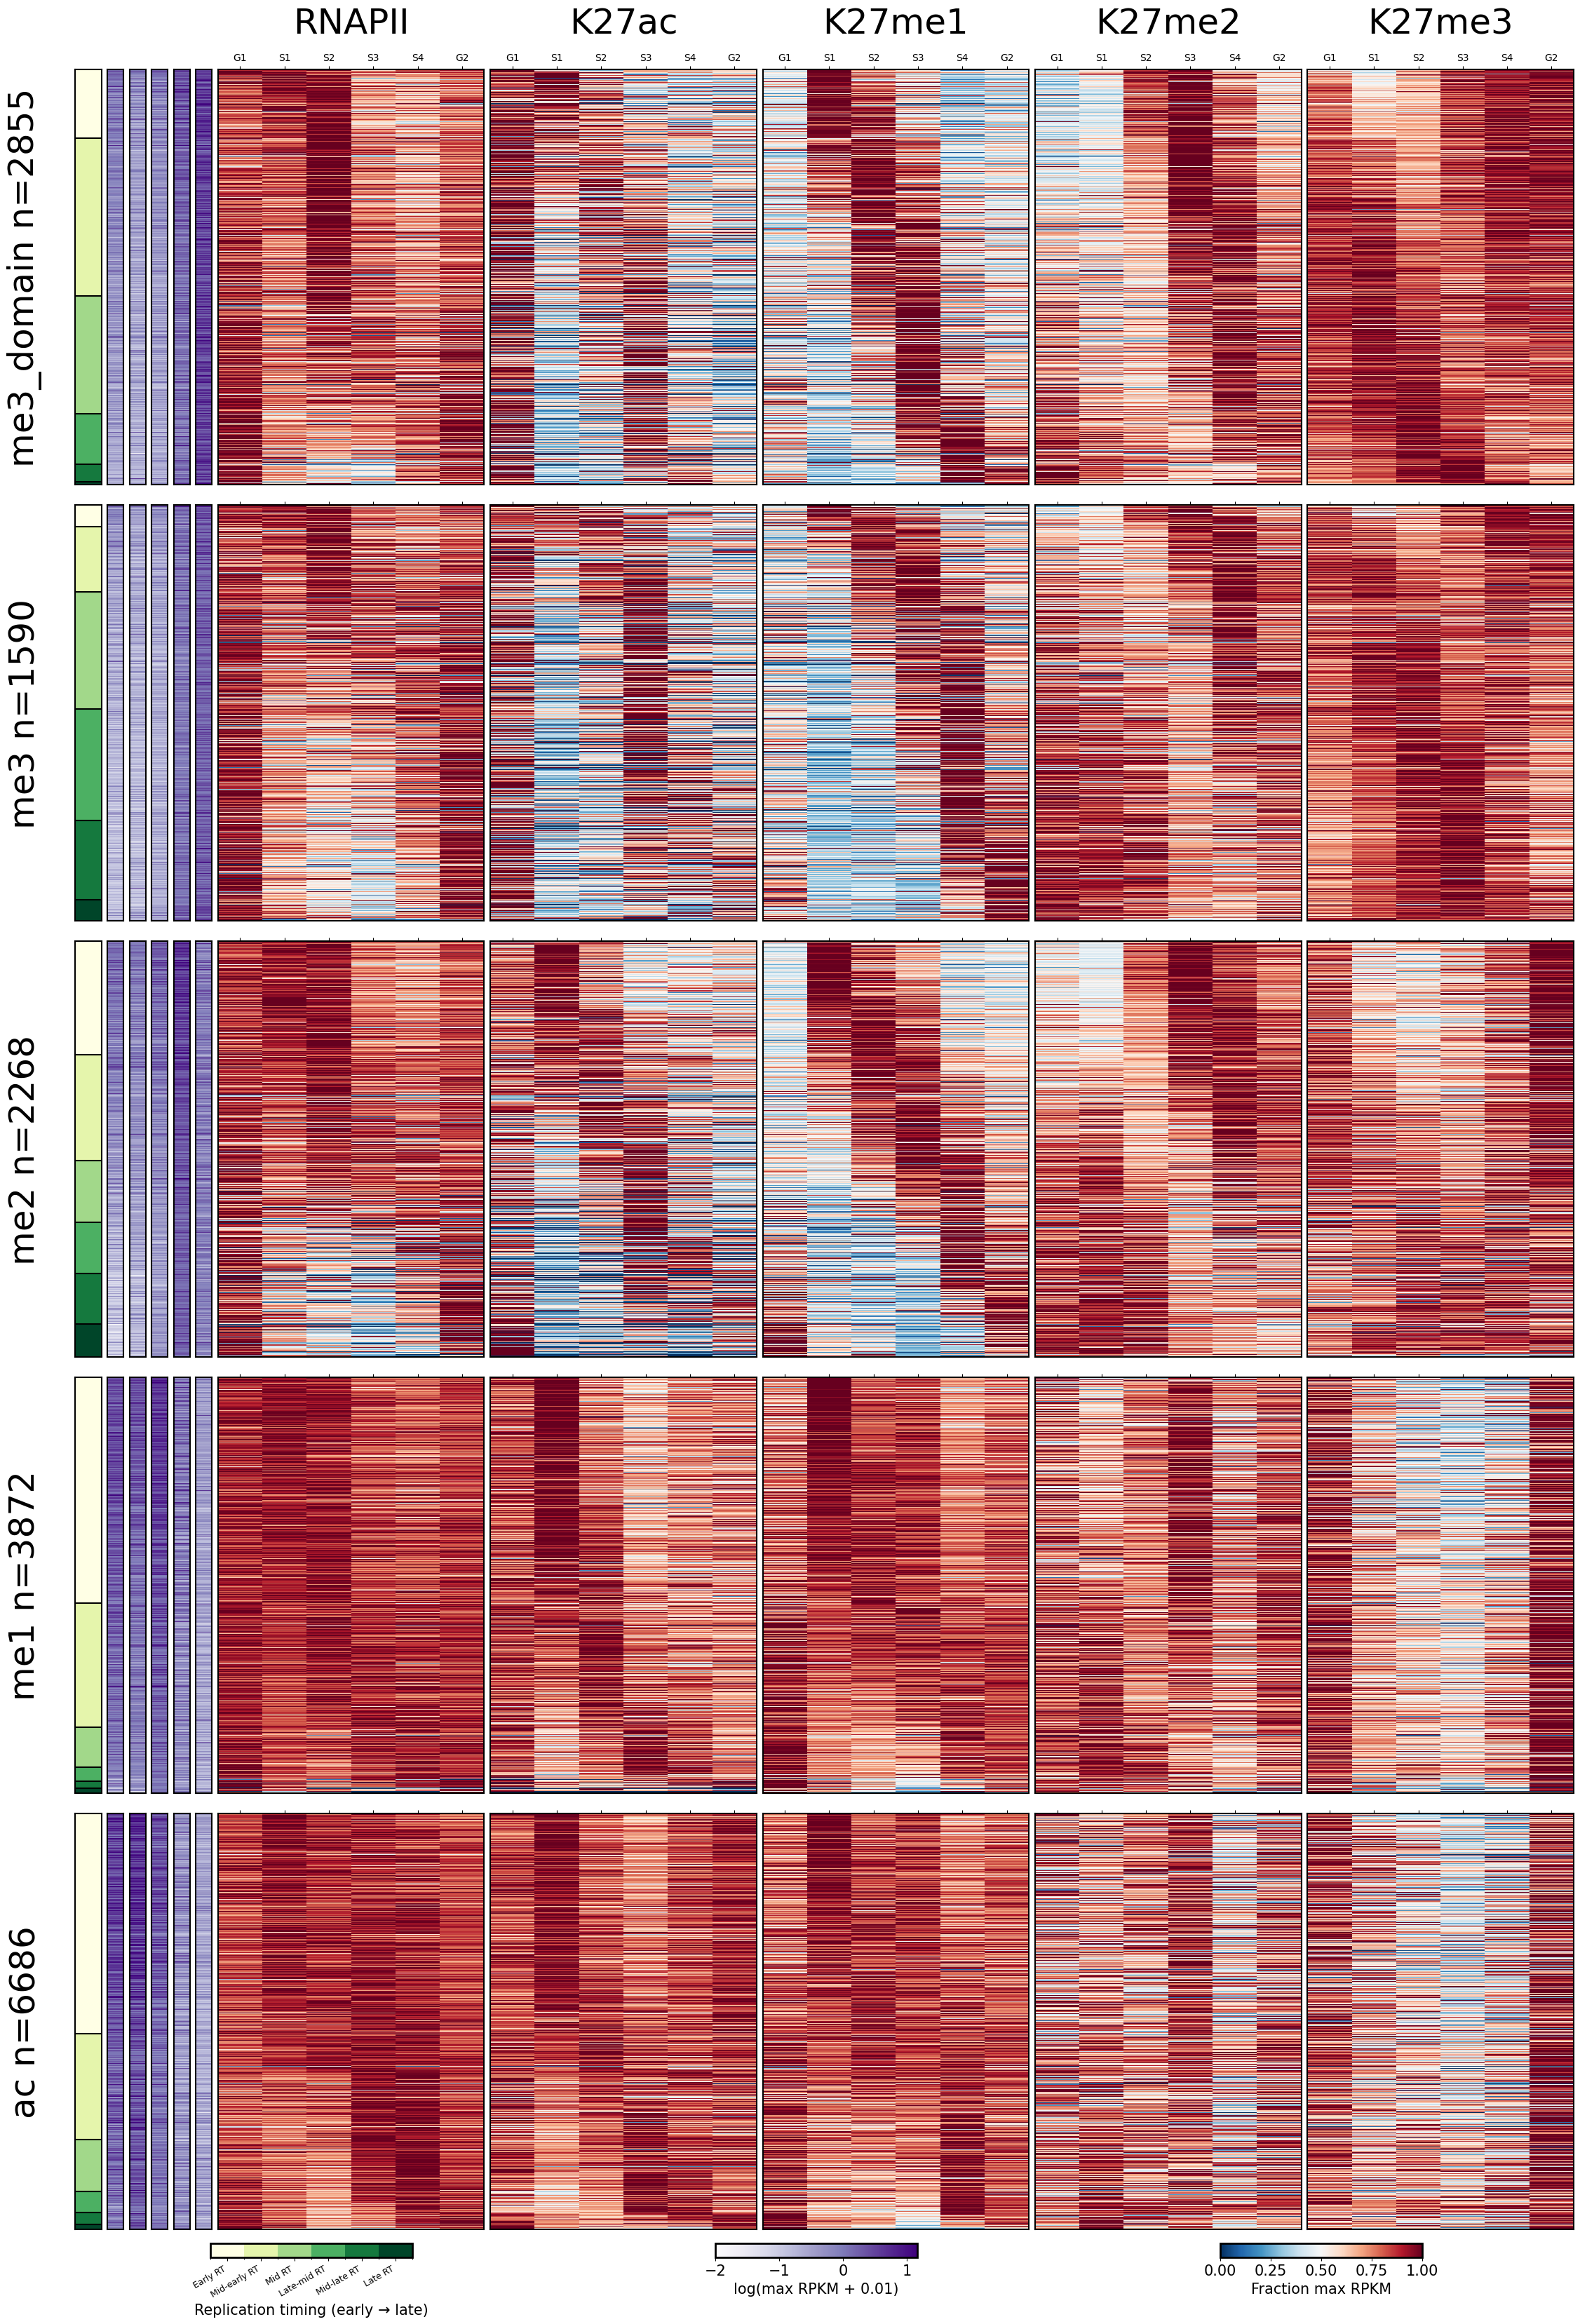

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ————————————————————————————————————————————
# Helper to add a black border around axes
def add_frame(ax, lw=1.5):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(lw)

# ————————————————————————————————————————————
# Configuration
categories = ['me3_domain', 'me3', 'me2', 'me1', 'ac']
rt_cmap = 'YlGn'
hm_cmap = 'RdBu_r'
rpkm_cmap = 'Purples'
xlabels = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']

rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[6] = 1
cutoffs = rt_bins

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

# ————————————————————————————————————————————
# Load normalized matrices
marks = ['RNAPII', 'K27ac', 'K27me1', 'K27me2', 'K27me3']

# original dfs order was:
# ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
raw_marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
hm_raw = [get_norm_df(dfs[i])[0] for i in range(5)]
hm_max = [get_norm_df(dfs[i])[1] for i in range(5)]

hm_dict_raw = dict(zip(raw_marks, hm_raw))
max_dict_raw = dict(zip(raw_marks, hm_max))

hm_dict = {m: hm_dict_raw[m] for m in marks}
max_dict = {m: max_dict_raw[m] for m in marks}

max_dict_log = {k: np.log10(v + 0.01) for k, v in max_dict.items()}
r_min, r_max = -2, np.nanquantile(
    np.concatenate([max_dict_log[k].values for k in ['K27me3', 'K27me2', 'K27me1', 'K27ac']]),
    0.99
)

# ————————————————————————————————————————————
# Set up figure layout
# New order:
# label | RT | 5 purple RPKM strips | 5 fraction heatmaps
n_rows = len(categories)
fig = plt.figure(figsize=(24, 8 * n_rows))
grid = fig.add_gridspec(
    n_rows, 12,
    left=0.05, right=0.96, top=0.95, bottom=0.18,
    hspace=0.05, wspace=0.05,
    width_ratios=[
        0.10,  # label
        0.10,  # RT
        0.06, 0.06, 0.06, 0.06, 0.06,  # grouped purple strips
        1, 1, 1, 1, 1                  # grouped heatmaps
    ]
)

# ————————————————————————————————————————————
# Loop through each category
for row_idx, cat_name in enumerate(categories):
    common = set().union(*[hm.index for hm in hm_dict.values()])
    common = common.intersection(rt_data.loc[rt_data['shape_category'] == cat_name].index)

    rt = bins_idx.loc[list(common), "RT"].dropna()
    rt = 1 - rt
    rt = rt.sort_values()
    genes = rt.index

    # Reindex all matrices and max values
    hm_data = {m: hm_dict[m].reindex(genes) for m in marks}
    max_data = {m: np.log10(max_dict[m].reindex(genes) + 0.01) for m in marks}

    # Create axes in the new order
    axes = [fig.add_subplot(grid[row_idx, i]) for i in range(12)]
    (
        ax_label,
        ax_rt,
        ax_r_rnapII, ax_r_ac, ax_r_me1, ax_r_me2, ax_r_me3,
        ax_hm_rnapII, ax_hm_ac, ax_hm_me1, ax_hm_me2, ax_hm_me3
    ) = axes

    # ——— Category label —
    ax_label.axis('off')
    ax_label.text(
        0, 0.5, f"{cat_name} n={len(genes)}",
        fontsize=36, va='center', ha='right',
        rotation=90, transform=ax_label.transAxes
    )

    # ——— RT stripe —
    rt_binned = pd.cut(rt, bins=rt_bins, labels=False, include_lowest=True)
    rt_binned = rt_binned.astype(float)

    sns.heatmap(
        rt_binned.values[:, None],
        ax=ax_rt,
        cmap=plt.cm.get_cmap(rt_cmap, len(rt_labels)),
        vmin=0, vmax=len(rt_labels) - 1,
        cbar=False, xticklabels=False, yticklabels=False
    )

    bin_edges = [np.searchsorted(rt_binned.values, i) for i in range(1, len(rt_labels))]
    for edge in bin_edges:
        ax_rt.hlines(edge, *ax_rt.get_xlim(), colors='black', linewidth=1.5)
    add_frame(ax_rt)

    # ——— Grouped purple strips: RNAPII, K27ac, K27me1, K27me2, K27me3 —
    rpkm_axes = {
        'RNAPII': ax_r_rnapII,
        'K27ac': ax_r_ac,
        'K27me1': ax_r_me1,
        'K27me2': ax_r_me2,
        'K27me3': ax_r_me3,
    }

    for mark, ax in rpkm_axes.items():
        sns.heatmap(
            max_data[mark].to_frame(),
            ax=ax,
            cmap=rpkm_cmap,
            vmin=r_min, vmax=r_max,
            cbar=False,
            xticklabels=False, yticklabels=False,
            mask=max_data[mark].isna().to_frame()
        )
        add_frame(ax)
        ax.set_ylabel('')

    # ——— Grouped fraction heatmaps in same order —
    hm_axes = {
        'RNAPII': ax_hm_rnapII,
        'K27ac': ax_hm_ac,
        'K27me1': ax_hm_me1,
        'K27me2': ax_hm_me2,
        'K27me3': ax_hm_me3,
    }

    for mark, ax in hm_axes.items():
        sns.heatmap(
            hm_data[mark],
            ax=ax,
            cmap=hm_cmap,
            vmin=0, vmax=1,
            cbar=False,
            xticklabels=True, yticklabels=False,
            mask=hm_data[mark].isna()
        )
        ax.set_xticklabels(xlabels, ha="center", rotation=0, fontsize=10)
        ax.xaxis.tick_top()
        add_frame(ax)
        ax.set_ylabel('')

    # ——— Titles only on top row —
    if row_idx == 0:
        ax_hm_rnapII.text(0.5, 1.07, "RNAPII", fontsize=36, ha='center', va='bottom', transform=ax_hm_rnapII.transAxes)
        ax_hm_ac.text(0.5, 1.07, "K27ac", fontsize=36, ha='center', va='bottom', transform=ax_hm_ac.transAxes)
        ax_hm_me1.text(0.5, 1.07, "K27me1", fontsize=36, ha='center', va='bottom', transform=ax_hm_me1.transAxes)
        ax_hm_me2.text(0.5, 1.07, "K27me2", fontsize=36, ha='center', va='bottom', transform=ax_hm_me2.transAxes)
        ax_hm_me3.text(0.5, 1.07, "K27me3", fontsize=36, ha='center', va='bottom', transform=ax_hm_me3.transAxes)

    # ——— Remove repeated x tick labels from lower rows —
    if row_idx != 0:
        for ax in hm_axes.values():
            ax.set_xticklabels([])
        for ax in rpkm_axes.values():
            ax.set_xticklabels([])

# ————————————————————————————————————————————
# Shared colorbars (bottom)
cbar_y = 0.17
cbar_h = 0.005
cbar_w = 0.12

# RT
cax_rt = fig.add_axes([0.15, cbar_y, cbar_w, cbar_h])
cmap_rt = plt.cm.get_cmap(rt_cmap, len(rt_labels))
bounds = np.arange(len(rt_labels) + 1) - 0.5
norm = mpl.colors.BoundaryNorm(bounds, cmap_rt.N)
cb = mpl.colorbar.ColorbarBase(
    cax_rt, cmap=cmap_rt, norm=norm,
    boundaries=bounds, ticks=np.arange(len(rt_labels)),
    orientation='horizontal'
)
cb.ax.set_xticklabels(rt_labels, rotation=30, ha='right', fontsize=9)
cb.set_label("Replication timing (early → late)")

# log(max RPKM)
cax_rpkm = fig.add_axes([0.45, cbar_y, cbar_w, cbar_h])
sm_rpkm = plt.cm.ScalarMappable(cmap=rpkm_cmap, norm=plt.Normalize(r_min, r_max))
plt.colorbar(sm_rpkm, cax=cax_rpkm, orientation="horizontal", label="log(max RPKM + 0.01)")

# Fraction max RPKM
cax_main = fig.add_axes([0.75, cbar_y, cbar_w, cbar_h])
sm_main = plt.cm.ScalarMappable(cmap=hm_cmap, norm=plt.Normalize(0, 1))
plt.colorbar(sm_main, cax=cax_main, orientation="horizontal", label="Fraction max RPKM")

plt.tight_layout()
#fig.savefig(os.path.join(fig_dir, "20260205_Fig1d_Dilution_heatmaps.pdf"), bbox_inches="tight")
plt.show()

/loc/scratch/59465656/ipykernel_23270/2151420760.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.01, 0, 0.95, 1])


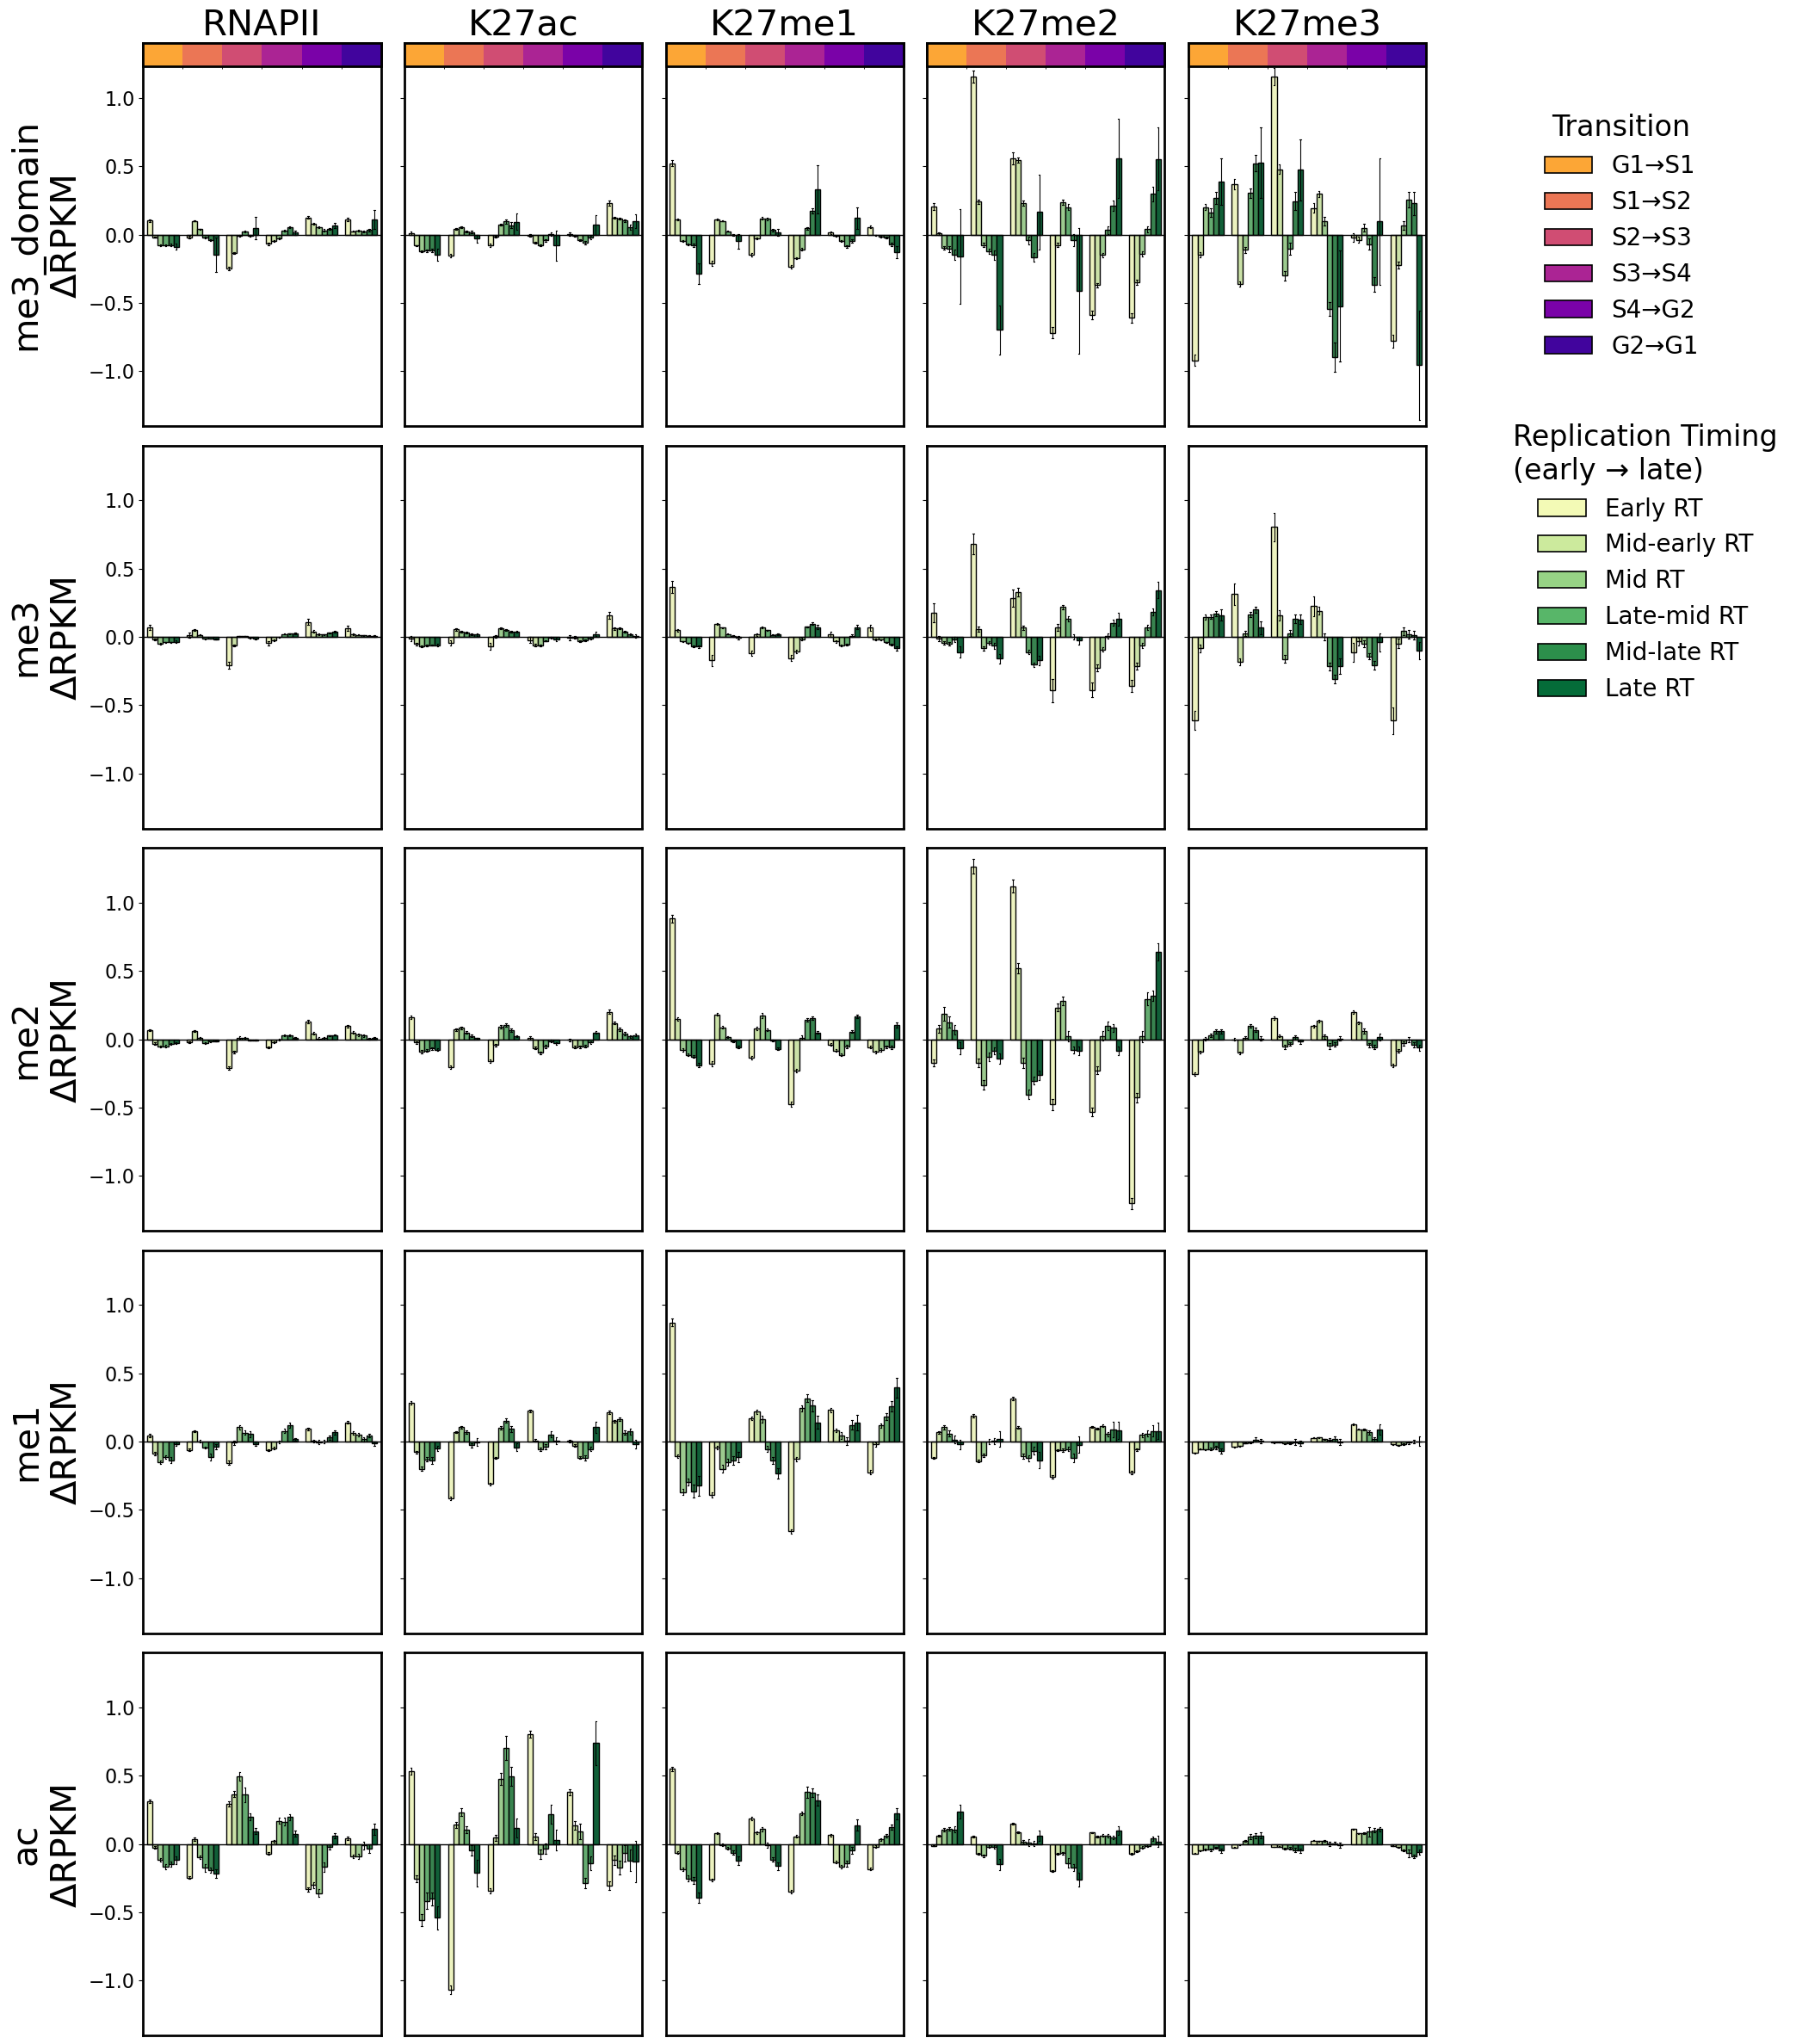

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# ————————————————————————————————————————————
# Load normalized matrices
# ————————————————————————————————————————————
marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII'][::-1]

hm_dict_raw = {
    mark: get_norm_df(dfs[::-1][i])[0] for i, mark in enumerate(marks)
}
hm_max = {
    mark: get_norm_df(dfs[::-1][i])[1] for i, mark in enumerate(marks)
}

# ————————————————————————————————————————————
# RT bin setup
# ————————————————————————————————————————————
# rt_bins = rt_bins[0, 0.25, 0.3, 0.4, 0.5, 0.6, 1]
# rt_labels = [ 'Early RT\n(0–0.25)', 
#              'Mid-early RT\n(0.25–0.3)', 
#              'Mid RT\n(0.3–0.4)', 
#              'Late-mid RT\n(0.4–0.5)', 
#              'Mid-late RT\n(0.5–0.6)', 
#              'Late RT\n(0.6–1)' ]
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num = 7
           )
rt_bins[0] = 0
rt_bins[6] = 1
rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]
bar_order = rt_labels

# ————————————————————————————————————————————
# Define stage and transition labels
# ————————————————————————————————————————————
stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
stage_with_wrap = stage_order + ['G1']
transition_labels = [f"{stage_with_wrap[i]}→{stage_with_wrap[i+1]}" for i in range(len(stage_with_wrap)-1)]

# ————————————————————————————————————————————
# Main loop: one row per shape category
# ————————————————————————————————————————————
shape_categories = ['me3_domain', 'me3', 'me2', 'me1', 'ac']
fig, axes = plt.subplots(len(shape_categories), len(marks), figsize=(18, 4.8 * len(shape_categories)), sharex=True, sharey=True)

palette = sns.color_palette("YlGn", len(rt_labels))

for row_idx, cat_name in enumerate(shape_categories):
    # Step 1: Gene selection and RT binning
    super_genes = set(rt_data[rt_data['shape_category'] == cat_name].index)
    rt = bins_idx.loc[bins_idx.index.intersection(super_genes), 'RT'].dropna()
    if rt.empty:
        print(f"Skipping category {cat_name} — no RT values.")
        continue

    rt = 1 - rt
    rt = rt.sort_values()
    genes = rt.index.tolist()
    if not genes:
        print(f"Skipping category {cat_name} — no valid genes.")
        continue

    rt_bin_assignment = pd.cut(rt, bins=rt_bins, labels=range(len(rt_labels)), include_lowest=True, right=True)

    # Step 2: Prepare per-category hm_dict copy with RT bin info
    hm_dict = {}
    for mark in marks:
        df = hm_dict_raw[mark].copy()
        df = df.loc[df.index.intersection(genes)].copy()
        df["rt_bin"] = rt_bin_assignment.reindex(df.index)
        df = df[df["rt_bin"].notna()]
        hm_dict[mark] = df

    # Step 3: Calculate Δ × max for all transitions
    rate_list = []
    for mark in marks:
        df = hm_dict[mark].copy()
        if df.empty:
            continue

        stage_cols = [s for s in stage_order if s in df.columns]
        if len(stage_cols) != len(stage_order):
            # if something is off, skip this mark to avoid cryptic errors
            print(f"Skipping {mark} in {cat_name}: missing stage columns {set(stage_order) - set(stage_cols)}")
            continue

        df_stages = df[stage_cols].copy()

        # wrap G1 for the G2→G1 transition
        df_stages["G1_wrap"] = df_stages["G1"]

        # compute differences across transitions G1→S1,...,G2→G1
        diff_df = df_stages[stage_with_wrap].diff(axis=1).iloc[:, 1:]

        # scale by max RPKM
        max_val = hm_max[mark].reindex(df.index)
        scaled_rate = diff_df.multiply(max_val, axis=0)

        # add metadata columns
        scaled_rate["gene"] = df.index
        scaled_rate["mark"] = mark
        scaled_rate["rt_bin"] = df["rt_bin"].values

        rate_list.append(scaled_rate)


    # Step 4: Melt into long form and assign labels
    rate_df = pd.concat(rate_list)
    trans_cols = rate_df.columns.difference(["gene", "mark", "rt_bin"], sort=False)
    rate_df = rate_df.rename(columns=dict(zip(trans_cols, transition_labels)))

    rate_long = (
        rate_df
        .reset_index(drop=True)
        .melt(
            id_vars=["gene", "mark", "rt_bin"],
            var_name="transition",
            value_name="scaled_rate"
        )
    )
    rate_long = rate_long[rate_long["scaled_rate"].notna() & (rate_long["scaled_rate"] != 0)]
    rate_long["transition"] = pd.Categorical(rate_long["transition"], categories=transition_labels, ordered=True)
    rate_long["rt_label"] = rate_long["rt_bin"].map(dict(enumerate(rt_labels)))
    rate_long["rt_label"] = pd.Categorical(rate_long["rt_label"], categories=bar_order, ordered=True)

    # Step 5: Plot one row of barplots per category
    for col_idx, mark in enumerate(marks):
        ax = axes[row_idx][col_idx] if len(shape_categories) > 1 else axes[col_idx]
        plot_df = rate_long[rate_long["mark"] == mark]
        if plot_df.empty:
            ax.set_visible(False)
            continue

        sns.barplot(
            data=plot_df,
            x="transition", y="scaled_rate", hue="rt_label",
            palette=palette, ax=ax,
            edgecolor='black',
            errorbar="se", err_kws={'color': 'black', 'linewidth': 0.8}, capsize=0.2,
            # order=bar_order,
            hue_order=rt_labels
        )
        
        if row_idx == 0:
            ax.set_title(f"{mark}", fontsize=30)
        if col_idx == 0:
            ax.set_ylabel(f"{cat_name}\nΔRPKM", fontsize=30)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.axhline(0, color='black', linewidth=1)
        ax.set_ylim(-1.4,1.4)

        # ——— Move x tick labels to the top ———
        ax.xaxis.set_ticks_position('top')
        ax.tick_params(axis='x', labeltop=True, labelbottom=False, rotation=90, labelsize=16)
        ax.tick_params(axis='y', labelsize=16)
        if row_idx != 0:
            ax.tick_params(axis='x', labeltop=False, labelbottom=False)

        ax.legend_.remove()

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# bin colormap setup
trans_cmap = mpl.colormaps['plasma_r']
trans_colors = trans_cmap(np.linspace(0.2, 0.9, len(transition_labels)))
cmap = mpl.colors.ListedColormap(trans_colors)
bounds = np.arange(len(transition_labels) + 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Inside your plotting loop:
for row_idx, cat_name in enumerate(shape_categories):
    for col_idx, mark in enumerate(marks):
        ax = axes[row_idx][col_idx] if len(shape_categories) > 1 else axes[col_idx]
        if not ax.get_visible():
            continue

        # Remove xticklabels everywhere
        ax.set_xticklabels([])
        ax.set_xticks([])

        # Add colorbar only for the first row
        if row_idx == 0:
            # inset_axes aligned at the top of current ax
            cax = inset_axes(ax, width="100%", height="6%", loc='upper center',
                             bbox_to_anchor=(0, 0, 1, 1),  # fine-tune vertical offset
                             bbox_transform=ax.transAxes, borderpad=0)

            cb = mpl.colorbar.ColorbarBase(
                cax, cmap=cmap, norm=norm,
                boundaries=bounds, ticks=np.arange(len(transition_labels)) + 0.5,
                orientation='horizontal'
            )
            cb.set_ticklabels('')
            cb.ax.set_xticks([])

from matplotlib.patches import Patch

trans_handles = [
    Patch(facecolor=trans_colors[i], edgecolor='black', linewidth=1.2, label=transition_labels[i])
    for i in range(len(transition_labels))
]

trans_legend = fig.legend(
    handles=trans_handles,
    title="Transition", title_fontsize=24, fontsize=20,
    loc="upper left", bbox_to_anchor=(1.00, 0.95), frameon=False
)

rt_handles = [
    Patch(facecolor=palette[i], edgecolor='black', linewidth=1.2, label=rt_labels[i])
    for i in range(len(rt_labels))
]

rt_legend = fig.legend(
    handles=rt_handles,
    title="Replication Timing\n(early → late)", title_fontsize=24, fontsize=20,
    loc="upper left", bbox_to_anchor=(0.98, 0.8), frameon=False
)

plt.tight_layout(rect=[0.01, 0, 0.95, 1])
fig.savefig(os.path.join(fig_dir, "20260205_Fig2b_deltaRPKM_barplot.pdf"), bbox_inches="tight")

plt.show()


# Promoter activity

In [36]:
#coordinates are TSS to TES
input_file = "data/2024/LAD_data/Dataset_S1_Promoter_SuRE_Classification.tsv"
df = pd.read_csv(input_file, sep="\t")
df['size'] = df['end'] - df['start']
df.head()

,seqname,start,end,strand,gene_id,class,log10_SuRE,log10_GROcap,LRS,size
0,chr1,633535,633741,+,ENSG00000240409.1,iLAD,-0.439499,-1.342423,1.500070,206
1,chr1,634376,634922,+,ENSG00000198744.5,iLAD,-0.383809,-1.305829,1.548710,546
2,chr1,725885,778626,-,ENSG00000228327.3,iLAD,1.466189,0.393755,0.702763,52741
3,chr1,826832,852225,+,ENSG00000228794.8,iLAD,0.864785,-0.961020,0.119342,25393
4,chr1,826206,827522,-,ENSG00000225880.5,iLAD,1.496508,-0.316937,-0.035507,1316


In [37]:
gtf_file_path = 'data/2024/LAD_data/gencode.v27.annotation.gtf.gz'
gtf = pr.read_gtf(gtf_file_path)
gtf = gtf.as_df()

In [38]:
#add gene meta from gtf
key = "gene_id"
gtf_keys = (
    gtf[[key, "gene_type", "gene_name"]]
    .dropna(subset=[key])
    .drop_duplicates(subset=[key], keep="first")
    .set_index(key)
)

# 3) Map onto df
df["gene_type"] = df[key].map(gtf_keys["gene_type"])
df["gene_name"] = df[key].map(gtf_keys["gene_name"])

In [39]:
# 1) Per-gene maxima from the promoter table
per_gene_max = (
    df
    .groupby('gene_name', as_index=False)
    .agg(max_log10_GROcap=('log10_GROcap', 'max'),
         max_log10_SuRE=('log10_SuRE', 'max'))
)

# 2) Map onto Geneid using gene symbols
maxRPKM = (
    rt_data
    .merge(per_gene_max, left_on='Geneid', right_on='gene_name', how='left')
    .drop(columns=['gene_name'])
)
maxRPKM.head()

,RT,shape_category,max_log10_GROcap,max_log10_SuRE
0,0.320406,ac,NaN,NaN
1,0.509584,ac,NaN,NaN
2,0.302942,ac,NaN,NaN
3,0.242104,me3_domain,-1.667996,1.271222
4,0.233120,me1,0.258801,2.129086


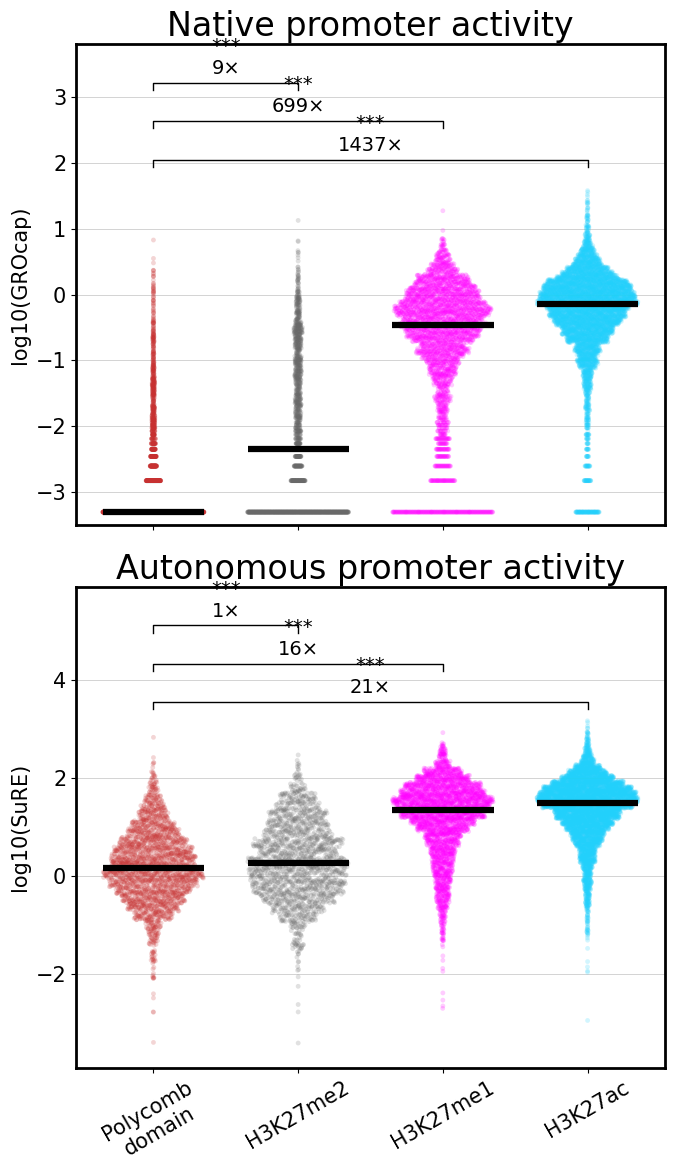

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

order   = ["me3_domain", "me2", "me1", "ac"]
labels  = ["Polycomb\ndomain", "H3K27me2", "H3K27me1", "H3K27ac"]
colors  = ["#C73131", "dimgrey", "#FF00FF", "#22D0FB"]

# (y_col, y_label, title, ylim)
panels = [
    ("max_log10_GROcap", "log10(GROcap)", "Native promoter activity", (-3.5, 3.8)),
    ("max_log10_SuRE",   "log10(SuRE)",   "Autonomous promoter activity", (-3.9, 5.9)),
]

fig, axes = plt.subplots(2, 1, figsize=(7, 12), sharex=True)

# ------------------------------------------------------------------
# 1) Draw points and medians first
# ------------------------------------------------------------------
for ax, (y_col, y_label, title, ylim) in zip(axes, panels):

    geom_quasirandom(
        ax=ax,
        data=maxRPKM,
        x_col="shape_category",
        y_col=y_col,
        order=order,
        width=0.7,
        nbins=None,
        colors=colors,
        alpha=0.2,
        size=12,
        zorder=2,
    )

    med = (
        maxRPKM
        .groupby("shape_category")[y_col]
        .median()
        .reindex(order)
    )

    for xi, y in enumerate(med):
        ax.hlines(y, xi - 0.35, xi + 0.35, linewidth=4.5, color="k", zorder=3)

    ax.set_title(title, fontsize=24)
    ax.set_ylabel(y_label)
    ax.set_ylim(*ylim)
    ax.grid(color="lightgray", linestyle="-", linewidth=0.7, axis="y", zorder=1)

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=30)

# ------------------------------------------------------------------
# 2) Collect all tests versus Polycomb domain across both panels
# ------------------------------------------------------------------
results = []  # (panel_idx, compare_idx, p_raw, med_ref, med_cmp)

ref_cat = "me3_domain"
ref_idx = order.index(ref_cat)

for panel_idx, (y_col, y_label, title, ylim) in enumerate(panels):
    v_ref = maxRPKM.loc[maxRPKM["shape_category"] == ref_cat, y_col].dropna()

    if v_ref.empty:
        continue

    for compare_idx in range(1, len(order)):
        cmp_cat = order[compare_idx]
        v_cmp = maxRPKM.loc[maxRPKM["shape_category"] == cmp_cat, y_col].dropna()

        if v_cmp.empty:
            continue

        stat, p = mannwhitneyu(v_ref, v_cmp, alternative="two-sided", method="auto")

        med_ref = np.median(v_ref)
        med_cmp = np.median(v_cmp)
        results.append((panel_idx, compare_idx, p, med_ref, med_cmp))

# ------------------------------------------------------------------
# 3) Benjamini–Hochberg FDR across all tests
# ------------------------------------------------------------------
if results:
    pvals = np.array([r[2] for r in results], dtype=float)
    m = len(pvals)

    sort_idx = np.argsort(pvals)
    p_sorted = pvals[sort_idx]
    ranks = np.arange(1, m + 1)

    bh_sorted = p_sorted * m / ranks
    bh_sorted = np.minimum.accumulate(bh_sorted[::-1])[::-1]
    bh_sorted = np.clip(bh_sorted, 0, 1)

    padj = np.empty_like(bh_sorted)
    padj[sort_idx] = bh_sorted

    results_with_fdr = []
    for r, pa in zip(results, padj):
        panel_idx, compare_idx, p_raw, med_ref, med_cmp = r
        results_with_fdr.append((panel_idx, compare_idx, p_raw, pa, med_ref, med_cmp))
else:
    results_with_fdr = []

# ------------------------------------------------------------------
# 4) Draw brackets, stars, and fold changes for significant pairs
# ------------------------------------------------------------------
alpha_fdr = 0.05

def p_to_stars(p):
    if p < 1e-4:
        return "***"
    elif p < 1e-3:
        return "**"
    elif p < 1e-2:
        return "*"
    else:
        return "ns"

for panel_idx, compare_idx, p_raw, p_adj, med_ref, med_cmp in results_with_fdr:
    ax = axes[panel_idx]
    _, _, _, ylim = panels[panel_idx]
    y_min, y_max = ylim
    y_range = y_max - y_min

    x1, x2 = ref_idx, compare_idx
    x_center = 0.5 * (x1 + x2)

    # stack brackets by comparison target
    base = y_max - 0.08 * y_range
    offset = 0.08 * y_range * (compare_idx - 1)
    y = base - offset
    line_y = y - 0.015 * y_range

    # fold change of compared category relative to Polycomb domain
    delta_log10 = med_cmp - med_ref
    fc = 10 ** delta_log10

    star = p_to_stars(p_adj)
    text = f"{star}\n{fc:.0f}×" if p_adj < alpha_fdr else "ns"

    ax.plot(
        [x1, x1, x2, x2],
        [line_y, y, y, line_y],
        color="k",
        linewidth=1,
    )

    ax.text(
        x_center,
        y + 0.01 * y_range,
        text,
        ha="center",
        va="bottom",
        fontsize=14,
    )

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Fig2cd_Native_vAutonomous_promoter.pdf"), bbox_inches="tight")
plt.show()

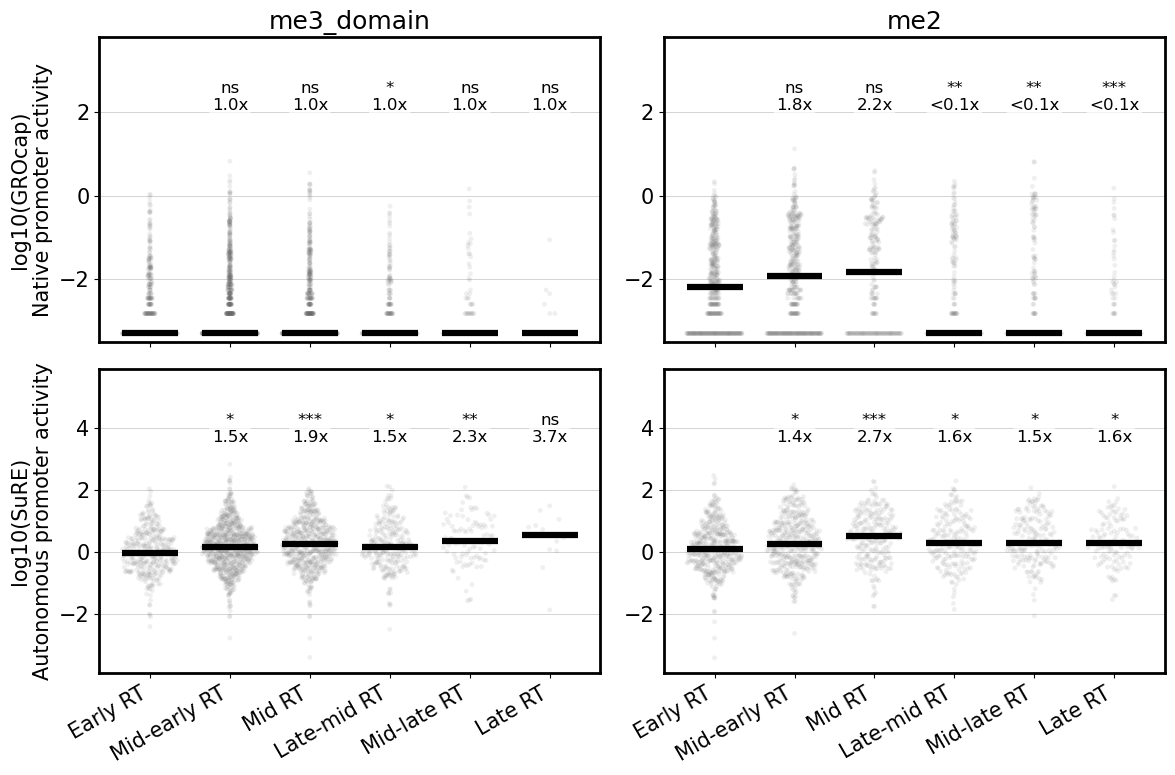

In [132]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# Assumes these already exist:
#   per_gene_max_me2_cats
#   rt_data
#   fig_dir
#   geom_quasirandom
# ------------------------------------------------------------

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
bbox_kwargs = dict(
    boxstyle="round,pad=0.15",
    facecolor="white",
    edgecolor="none",
    alpha=0.7
)

target_shapes = ["me3_domain", "me2"]

panels = [
    ("max_log10_GROcap", "log10(GROcap)", "Native promoter activity", (-3.5, 3.8)),
    ("max_log10_SuRE",   "log10(SuRE)",   "Autonomous promoter activity", (-3.9, 5.9)),
]

# RT binning
rt_bins = np.linspace(
    np.quantile(rt_data["RT"].dropna(), 0.02),
    np.quantile(rt_data["RT"].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[6] = 1

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

baseline_bin = "Early RT"
alpha_fdr = 0.05

# ------------------------------------------------------------
# Prepare plotting dataframe
# ------------------------------------------------------------
plot_df = per_gene_max_me2_cats.copy()
plot_df["gene_key"] = plot_df.index.astype(str)

rt_tmp = rt_data.copy()
rt_tmp["gene_key"] = rt_tmp.index.astype(str)

# add rt_bin to rt_data
rt_tmp["rt_bin"] = pd.cut(
    rt_tmp["RT"],
    bins=rt_bins,
    labels=rt_labels,
    include_lowest=True,
    right=True
)

# merge by index first
plot_df = plot_df.merge(
    rt_tmp[["gene_key", "RT", "shape_category", "rt_bin"]],
    on="gene_key",
    how="left"
)

# if merge by index failed badly, try gene_name
n_matched = plot_df["rt_bin"].notna().sum()
if n_matched < 100 and "gene_name" in plot_df.columns:
    tmp2 = per_gene_max_me2_cats.copy()
    tmp2 = tmp2.merge(
        rt_tmp[["RT", "shape_category", "rt_bin"]],
        left_on="gene_name",
        right_index=True,
        how="left"
    )
    if tmp2["rt_bin"].notna().sum() > n_matched:
        plot_df = tmp2.copy()

# keep only requested categories and valid RT bins
plot_df = plot_df.loc[
    plot_df["shape_category"].isin(target_shapes) &
    plot_df["rt_bin"].notna()
].copy()

plot_df["rt_bin"] = pd.Categorical(
    plot_df["rt_bin"],
    categories=rt_labels,
    ordered=True
)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if p < 1e-4:
        return "***"
    elif p < 1e-3:
        return "**"
    elif p < 1e-2:
        return "*"
    else:
        return "ns"

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    if m == 0:
        return np.array([])

    order = np.argsort(pvals)
    p_sorted = pvals[order]
    ranks = np.arange(1, m + 1)

    q_sorted = p_sorted * m / ranks
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.minimum(q_sorted, 1.0)

    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    return q

# ------------------------------------------------------------
# Plot
# 2 rows = assays
# 2 cols = shape categories (me3_domain, me2)
# x axis = RT bins
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(panels),
    ncols=len(target_shapes),
    figsize=(12, 8),
    sharex=True
)

if len(panels) == 1 and len(target_shapes) == 1:
    axes = np.array([[axes]])
elif len(panels) == 1:
    axes = axes[np.newaxis, :]
elif len(target_shapes) == 1:
    axes = axes[:, np.newaxis]

results = []
# store: (panel_idx, shape_idx, rt_idx, p_raw, med_other, med_base)

# ------------------------------------------------------------
# 1) Draw points and medians
# ------------------------------------------------------------
for shape_idx, shape_cat in enumerate(target_shapes):
    sub_shape = plot_df.loc[plot_df["shape_category"] == shape_cat].copy()

    for panel_idx, (y_col, y_label, title, ylim) in enumerate(panels):
        ax = axes[panel_idx, shape_idx]

        sub = sub_shape.loc[sub_shape[y_col].notna()].copy()

        geom_quasirandom(
            ax=ax,
            data=sub,
            x_col="rt_bin",
            y_col=y_col,
            order=rt_labels,
            width=0.7,
            nbins=None,
            colors=["dimgrey"] * len(rt_labels),
            alpha=0.1,
            size=12,
            zorder=2,
        )

        med = (
            sub.groupby("rt_bin", observed=False)[y_col]
            .median()
            .reindex(rt_labels)
        )

        for xi, y in enumerate(med):
            if pd.isna(y):
                continue
            ax.hlines(y, xi - 0.35, xi + 0.35, linewidth=4.5, color="k", zorder=3)

        # titles
        if panel_idx == 0:
            ax.set_title(shape_cat)

        if shape_idx == 0:
            ax.set_ylabel(f"{y_label}\n{title}")
        else:
            ax.set_ylabel("")

        ax.set_ylim(*ylim)
        ax.grid(color="lightgray", linestyle="-", linewidth=0.7, axis="y", zorder=1)

        # stats versus Early RT within each shape category
        v_base = sub.loc[sub["rt_bin"] == baseline_bin, y_col].dropna()
        if v_base.empty:
            continue

        med_base = np.median(v_base)

        for rt_idx, rt_bin in enumerate(rt_labels):
            if rt_bin == baseline_bin:
                continue

            v_other = sub.loc[sub["rt_bin"] == rt_bin, y_col].dropna()
            if v_other.empty:
                continue

            stat, p = mannwhitneyu(
                v_other,
                v_base,
                alternative="two-sided",
                method="auto"
            )
            med_other = np.median(v_other)

            results.append((panel_idx, shape_idx, rt_idx, p, med_other, med_base))

# shared x ticks
for shape_idx in range(len(target_shapes)):
    axes[-1, shape_idx].set_xticks(range(len(rt_labels)))
    axes[-1, shape_idx].set_xticklabels(rt_labels, rotation=30, ha="right")

for panel_idx in range(len(panels) - 1):
    for shape_idx in range(len(target_shapes)):
        axes[panel_idx, shape_idx].set_xticks(range(len(rt_labels)))

# ------------------------------------------------------------
# 2) BH-FDR across all tests
# ------------------------------------------------------------
if results:
    pvals = [r[3] for r in results]
    padj = bh_fdr(pvals)

    results_with_fdr = []
    for r, q in zip(results, padj):
        panel_idx, shape_idx, rt_idx, p_raw, med_other, med_base = r
        results_with_fdr.append(
            (panel_idx, shape_idx, rt_idx, p_raw, q, med_other, med_base)
        )
else:
    results_with_fdr = []

# ------------------------------------------------------------
# 3) Annotate fold change and significance
#    Fold change is in linear space since y values are log10
# ------------------------------------------------------------
for panel_idx, shape_idx, rt_idx, p_raw, p_adj, med_other, med_base in results_with_fdr:
    ax = axes[panel_idx, shape_idx]
    _, _, _, ylim = panels[panel_idx]
    y_min, y_max = ylim
    y_range = y_max - y_min

    delta_log10 = med_other - med_base
    fc = 10 ** delta_log10

    if fc < 0.1:
        fc_str = "<0.1x"
    elif fc < 10:
        fc_str = f"{fc:.1f}x"
    else:
        fc_str = f"{fc:.0f}x"

    star = p_to_stars(p_adj)
    label = f"{star}\n{fc_str}"

    y_text = y_max - 0.25 * y_range

    ax.text(
        rt_idx,
        y_text,
        label,
        ha="center",
        va="bottom",
        fontsize=12,
        bbox=bbox_kwargs
    )

plt.tight_layout()
fig.savefig(
    os.path.join(fig_dir, "20260319_Fig3de_Native_vAutonomous_me3domain_me2_byRTbin.pdf"),
    bbox_inches="tight"
)
plt.show()

# Circle plots

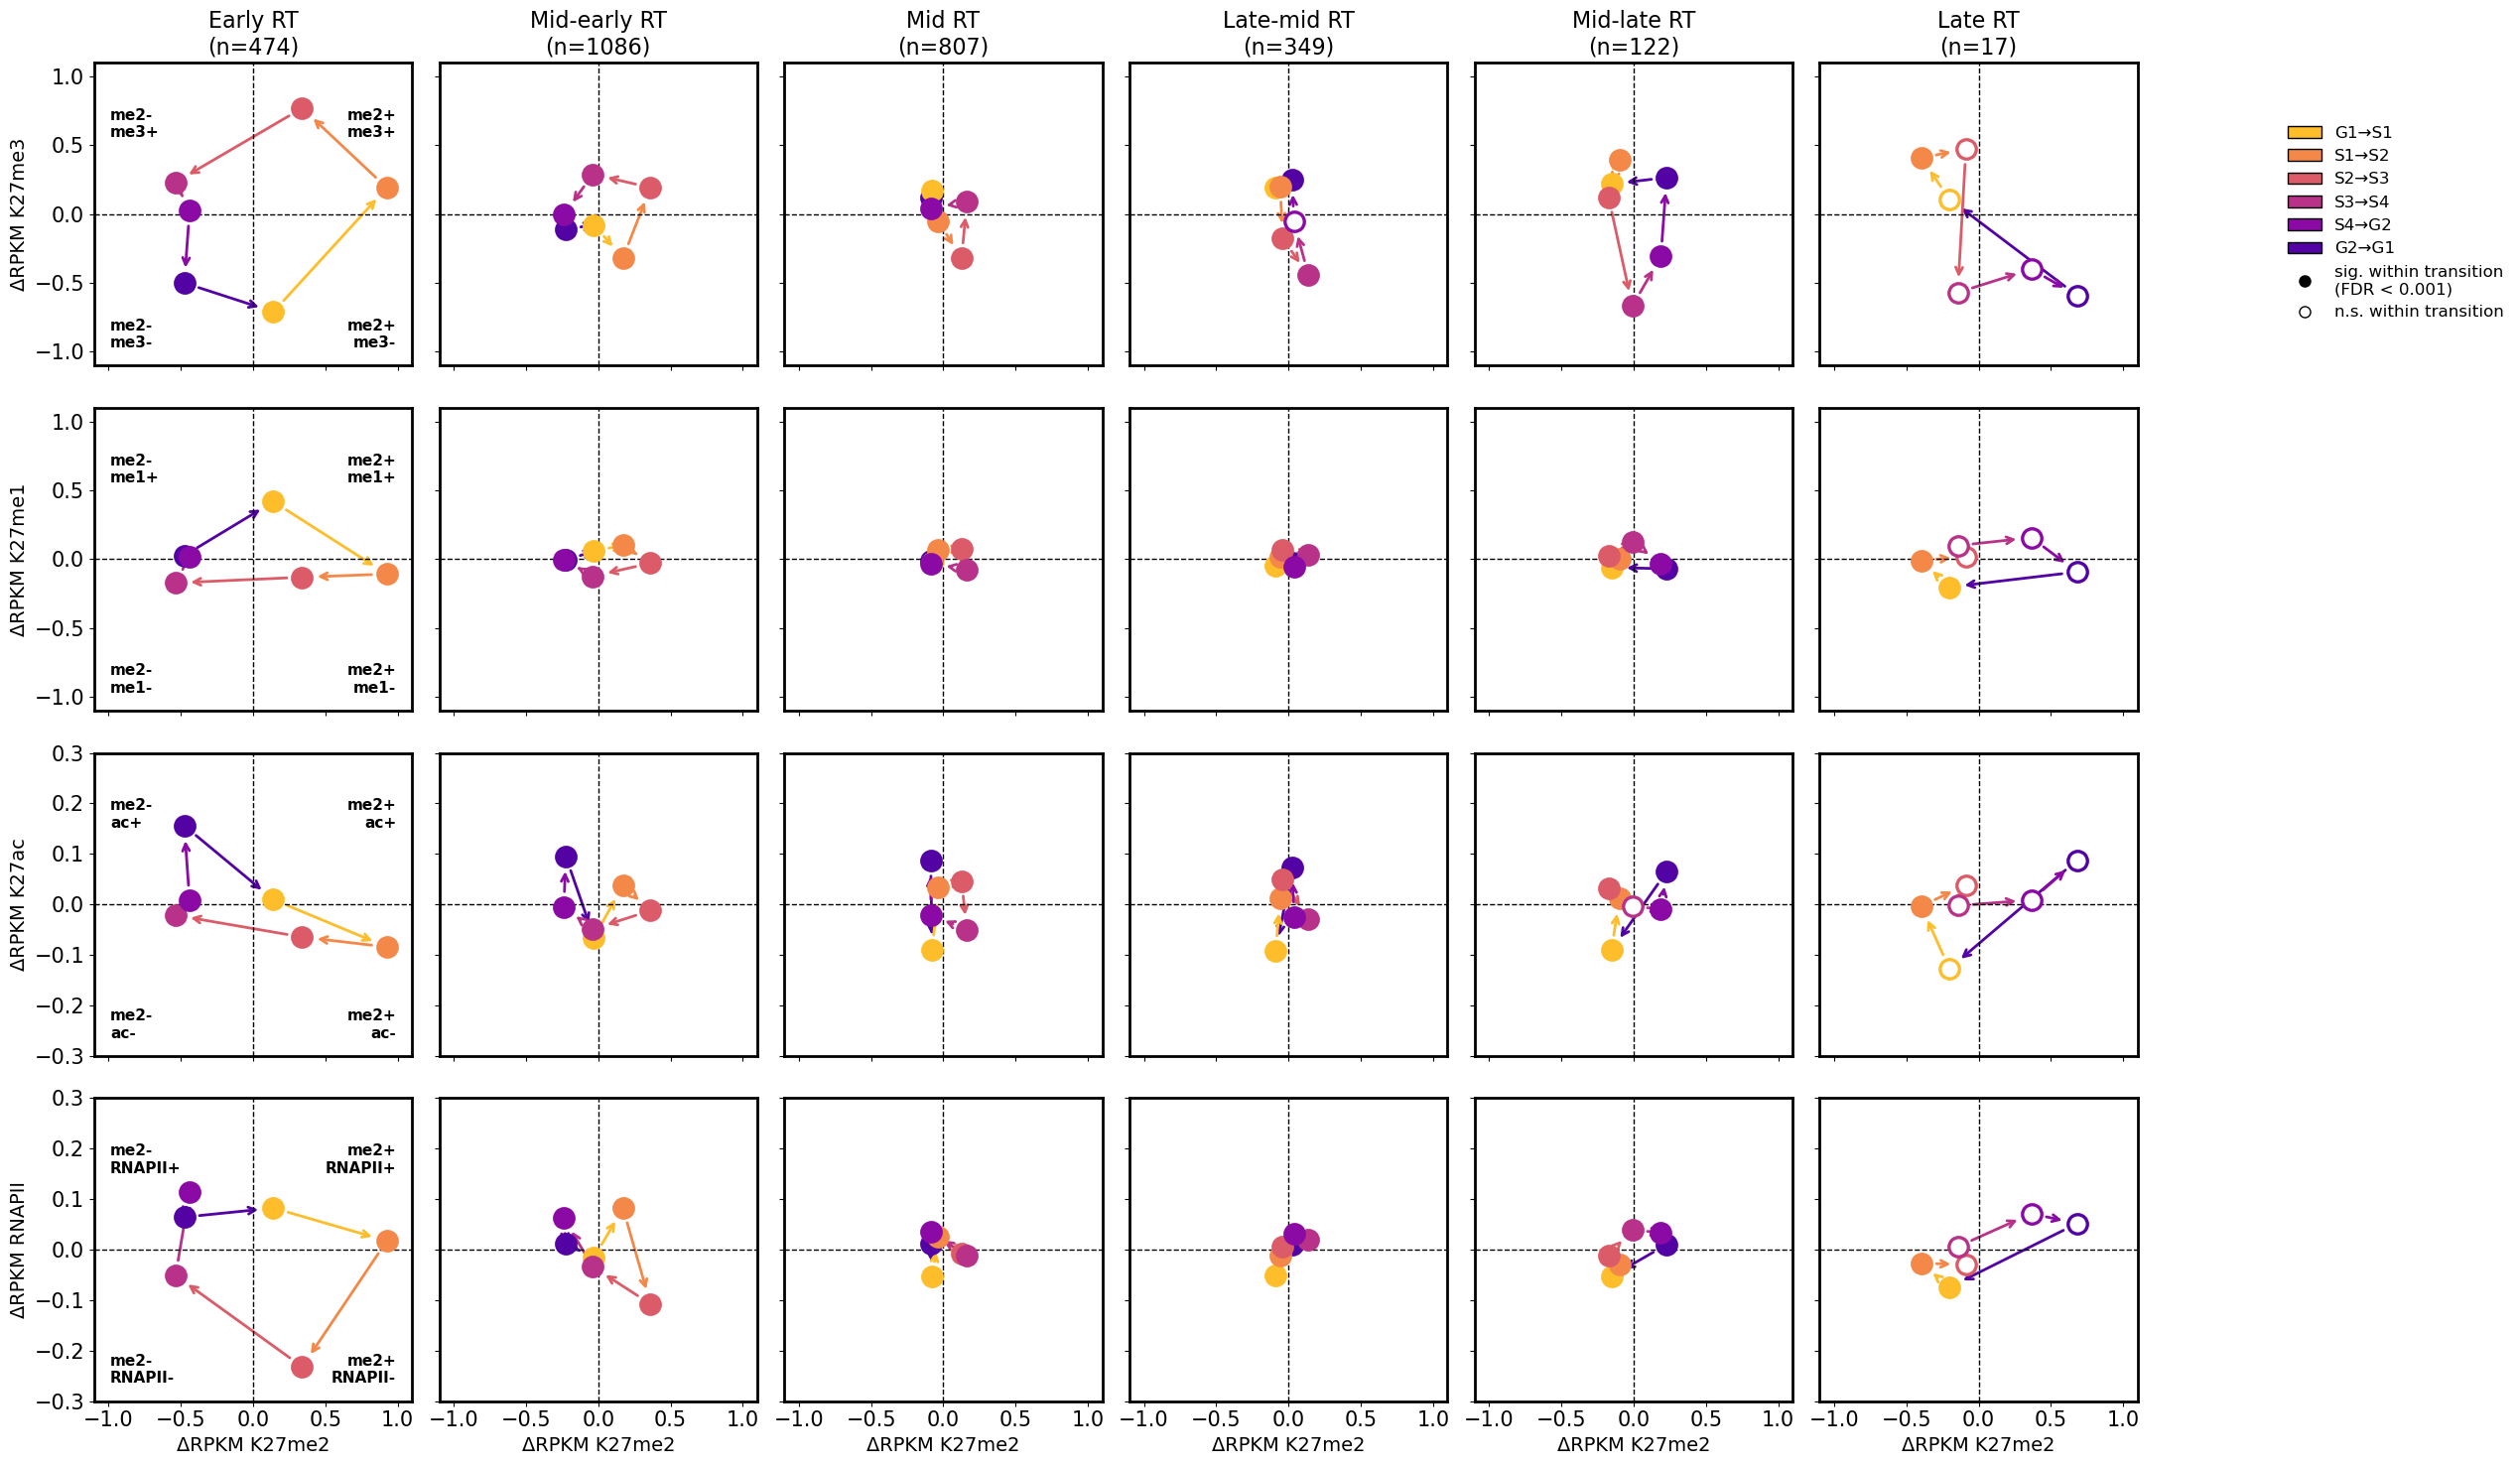

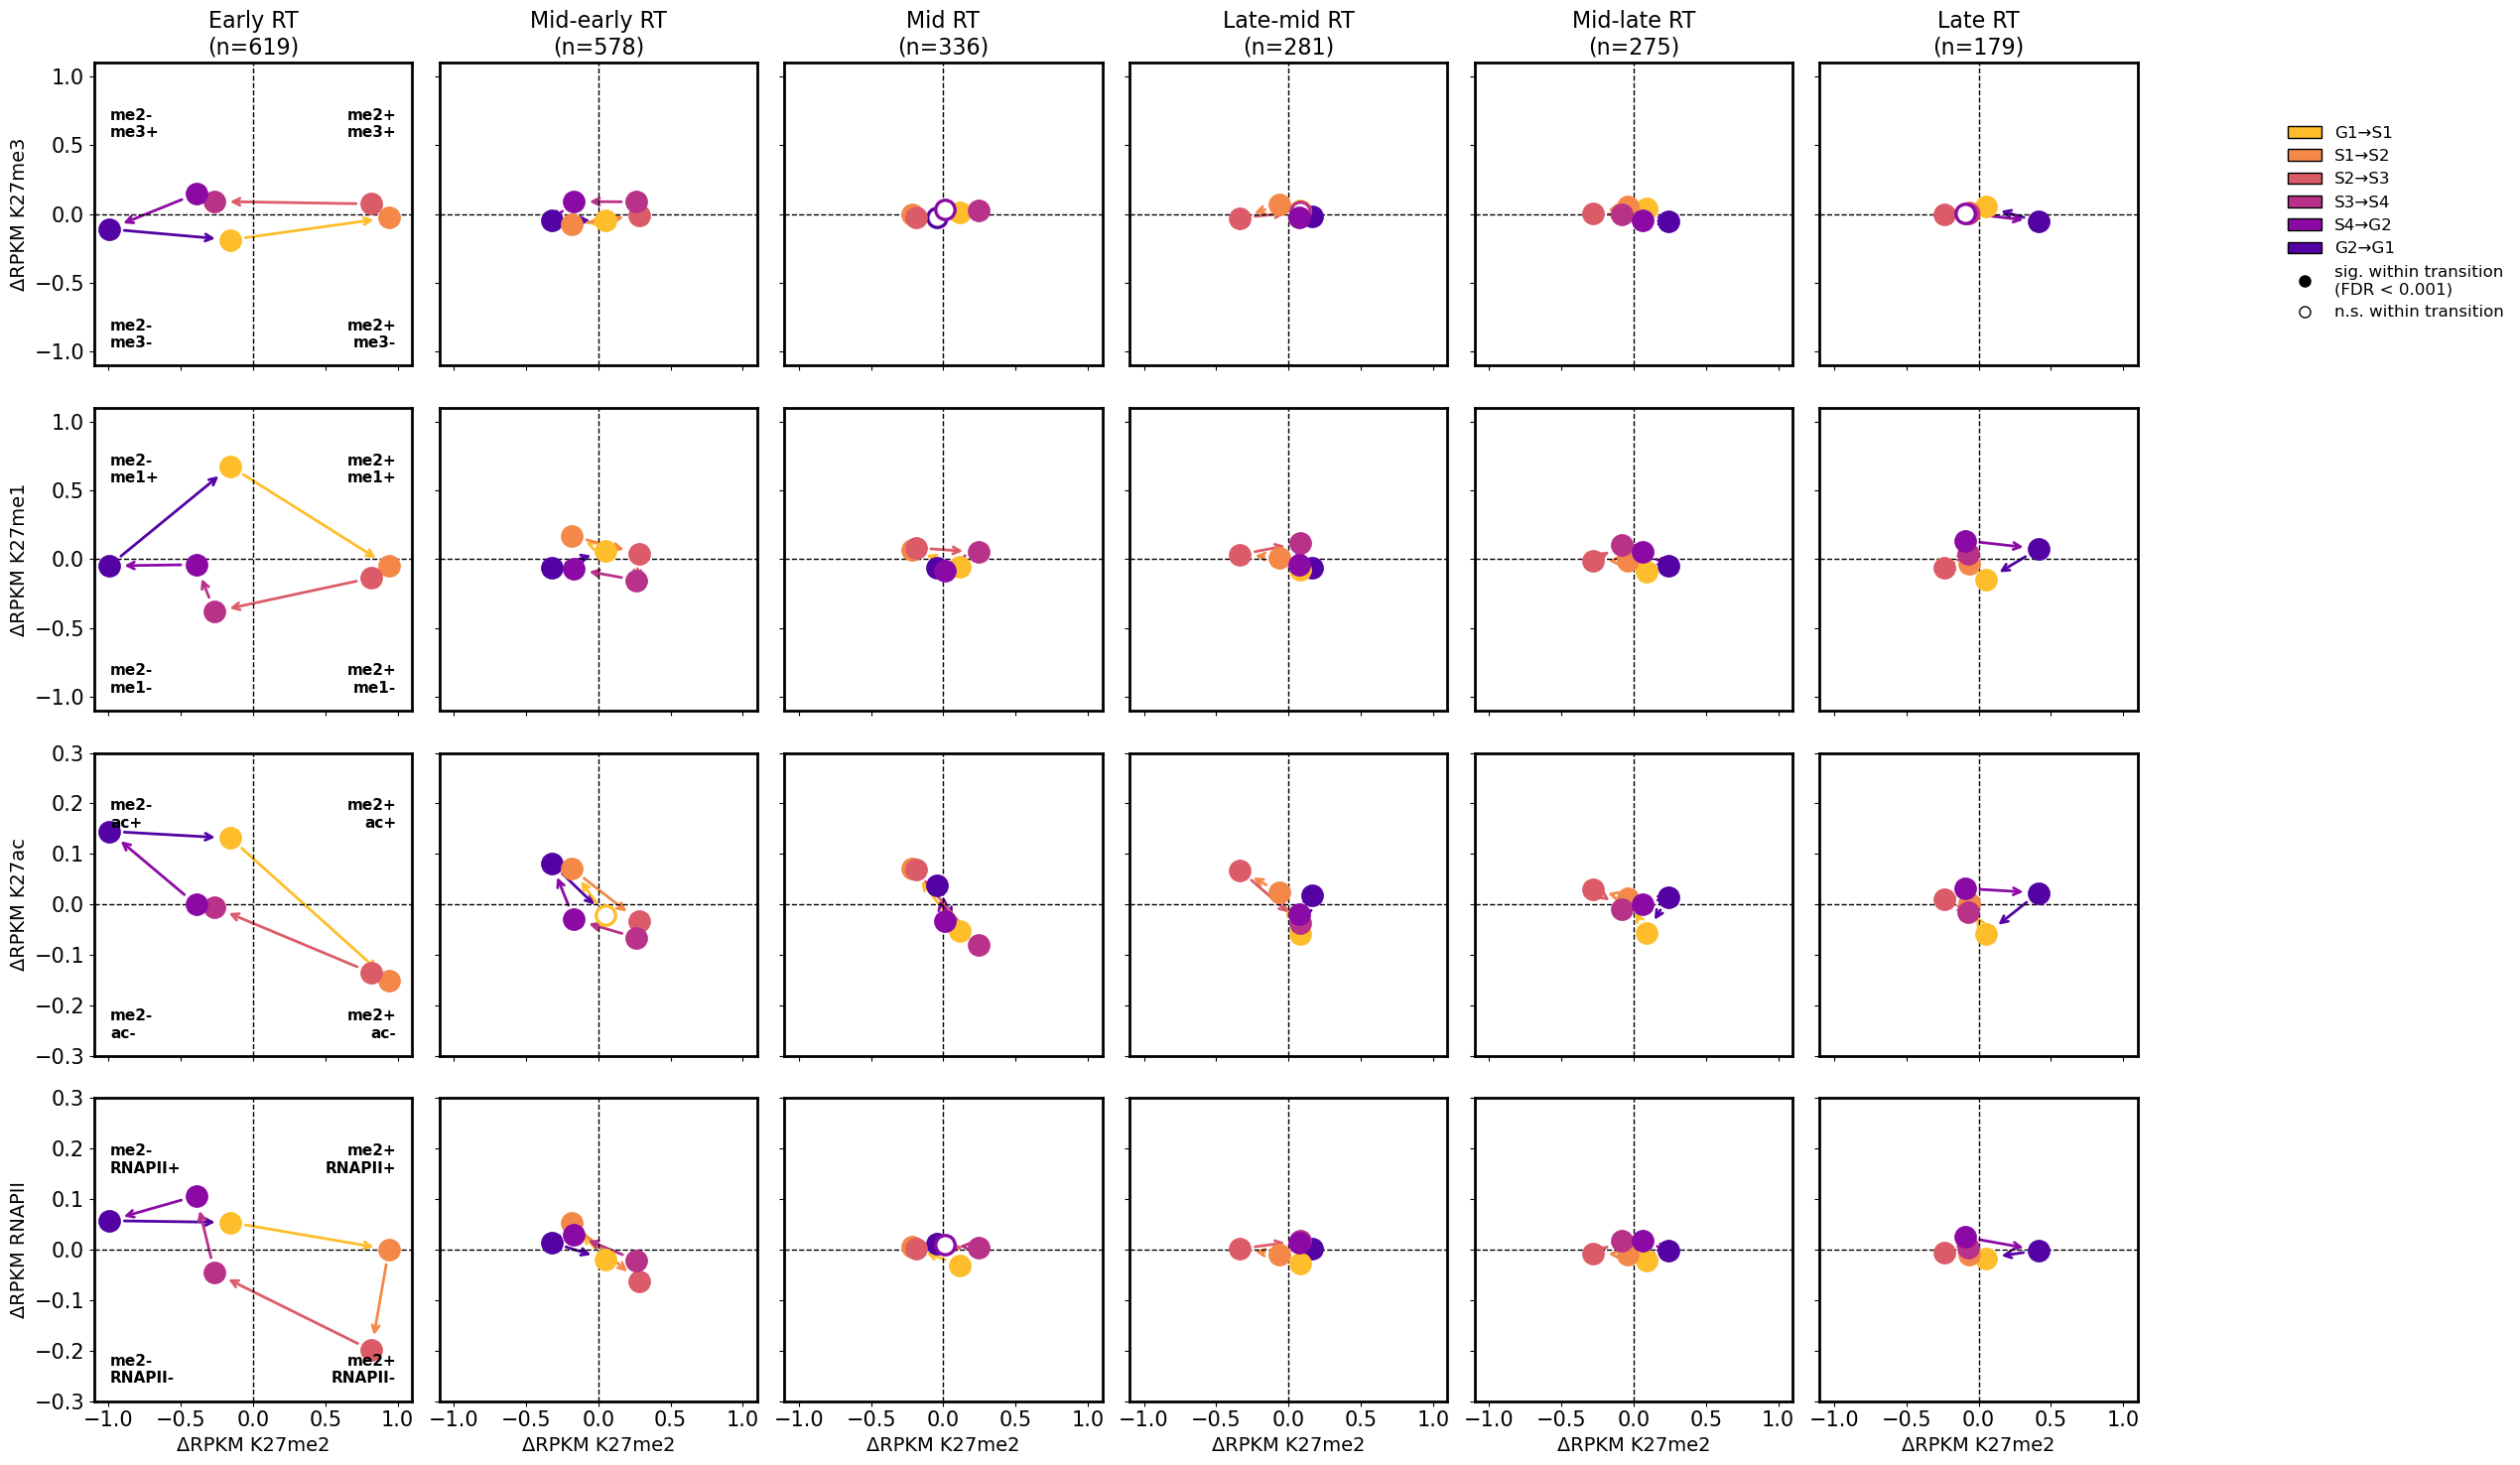

In [24]:
###figue 3
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats

# Inputs assumed to exist:
#   rt_data, bins_idx, dfs, get_norm_df(), fig_dir

# -----------------------------
# Parameters
# -----------------------------
significance_cutoff = 0.001
min_pairs = 8
marker_size = 14
marker_edgewidth = 2.4
arrow_lw = 2.0
arrow_scale_with_marker = 1.15
cat_names = ['me3_domain', 'me2']

marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
stage_with_wrap = stage_order + ['G1']
transition_order = ["G1→S1", "S1→S2", "S2→S3", "S3→S4", "S4→G2", "G2→G1"]

# each plotted point is the delta TO that fraction
stage_to_transition = {
    'G1': 'G2→G1',
    'S1': 'G1→S1',
    'S2': 'S1→S2',
    'S3': 'S2→S3',
    'S4': 'S3→S4',
    'G2': 'S4→G2',
}
transition_to_stage = {v: k for k, v in stage_to_transition.items()}

# transition colors
palette = sns.color_palette("plasma_r", len(transition_order))
transition_color_map = dict(zip(transition_order, palette))

# normalize once per mark
hm_dict = {}
hm_max = {}
for mark, df in zip(marks, dfs):
    norm_df, max_rpkm = get_norm_df(df)
    hm_dict[mark] = norm_df
    hm_max[mark] = max_rpkm

# RT binning
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[-1] = 1

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]
rt_label_map = dict(enumerate(rt_labels))

rt_series = 1 - bins_idx['RT']
rt_bin_assignment = pd.cut(
    rt_series,
    bins=rt_bins,
    labels=range(len(rt_labels)),
    include_lowest=True,
    right=True
)

for mark in hm_dict:
    df = hm_dict[mark]
    valid_idx = rt_bin_assignment.dropna().index.intersection(df.index)
    hm_dict[mark] = df.loc[valid_idx].assign(rt_bin=rt_bin_assignment.loc[valid_idx])

# stage-specific RPKM for within-transition significance testing
stage_rpkm_list = []
for mark in marks:
    df = hm_dict[mark].copy()
    stage_cols = [s for s in stage_order if s in df.columns]
    if len(stage_cols) != len(stage_order):
        print(f"Skipping {mark}: missing stage columns {set(stage_order) - set(stage_cols)}")
        continue

    max_vals = hm_max[mark].loc[df.index]
    rpkm_df = df[stage_cols].multiply(max_vals, axis=0)
    rpkm_df['gene'] = df.index
    rpkm_df['mark'] = mark
    rpkm_df['rt_bin'] = df['rt_bin'].values
    stage_rpkm_list.append(rpkm_df)

stage_rpkm_df = pd.concat(stage_rpkm_list)

stage_rpkm_long = stage_rpkm_df.melt(
    id_vars=['gene', 'mark', 'rt_bin'],
    var_name='stage',
    value_name='rpkm'
).dropna(subset=['rpkm'])

stage_rpkm_long['stage'] = pd.Categorical(stage_rpkm_long['stage'], categories=stage_order, ordered=True)
stage_rpkm_long['rt_label'] = stage_rpkm_long['rt_bin'].map(rt_label_map)
stage_rpkm_long['rt_label'] = pd.Categorical(stage_rpkm_long['rt_label'], categories=rt_labels, ordered=True)

stage_rpkm_wide = stage_rpkm_long.pivot_table(
    index=['gene', 'stage', 'rt_label'],
    columns='mark',
    values='rpkm',
    observed=True
).reset_index()

# delta RPKM table for plotting
rate_list = []
for mark in marks:
    df = hm_dict[mark].copy()
    stage_cols = [s for s in stage_order if s in df.columns]
    if len(stage_cols) != len(stage_order):
        continue

    df_stages = df[stage_cols].copy()
    df_stages['G1_wrap'] = df_stages['G1']
    diffs = df_stages[stage_with_wrap].diff(axis=1).iloc[:, 1:]

    max_vals = hm_max[mark].loc[df.index]
    scaled = diffs.multiply(max_vals, axis=0)

    scaled['gene'] = df.index
    scaled['mark'] = mark
    scaled['rt_bin'] = df['rt_bin'].values
    rate_list.append(scaled)

rate_df = pd.concat(rate_list)

transition_cols = rate_df.columns.difference(["gene", "mark", "rt_bin"], sort=False)
rate_df = rate_df.rename(columns=dict(zip(transition_cols, transition_order)))

rate_long = rate_df.melt(
    id_vars=['gene', 'mark', 'rt_bin'],
    var_name='transition',
    value_name='scaled_rate'
).dropna(subset=['scaled_rate'])

rate_long['transition'] = pd.Categorical(rate_long['transition'], categories=transition_order, ordered=True)
rate_long['stage'] = rate_long['transition'].map(transition_to_stage)
rate_long['stage'] = pd.Categorical(rate_long['stage'], categories=stage_order, ordered=True)
rate_long['rt_label'] = rate_long['rt_bin'].map(rt_label_map)
rate_long['rt_label'] = pd.Categorical(rate_long['rt_label'], categories=rt_labels, ordered=True)

rate_wide = rate_long.pivot_table(
    index=['gene', 'transition', 'stage', 'rt_label'],
    columns='mark',
    values='scaled_rate',
    observed=True
).reset_index()

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)
    ok = np.isfinite(pvals)
    if ok.sum() == 0:
        return qvals
    p = pvals[ok]
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    q_full = np.full(n, np.nan, dtype=float)
    q_full[order] = q
    qvals[ok] = q_full
    return qvals

def get_cat_rt_rate_wide(cat_name, rt_label):
    genes_cat = set(rt_data.loc[rt_data['shape_category'] == cat_name].index)
    return rate_wide[
        (rate_wide['rt_label'] == rt_label) &
        (rate_wide['gene'].isin(genes_cat))
    ].copy()

def get_cat_rt_stage_wide(cat_name, rt_label):
    genes_cat = set(rt_data.loc[rt_data['shape_category'] == cat_name].index)
    return stage_rpkm_wide[
        (stage_rpkm_wide['rt_label'] == rt_label) &
        (stage_rpkm_wide['gene'].isin(genes_cat))
    ].copy()

def compute_within_transition_sig(sub_stage, x_mark, y_mark):
    tests = []

    for stage in stage_order:
        prev_stage = stage_order[stage_order.index(stage) - 1]
        a = sub_stage[sub_stage["stage"] == prev_stage][["gene", x_mark, y_mark]].copy()
        b = sub_stage[sub_stage["stage"] == stage][["gene", x_mark, y_mark]].copy()
        merged = a.merge(b, on="gene", suffixes=("_from", "_to")).dropna()

        for mark in [x_mark, y_mark]:
            from_vals = merged[f"{mark}_from"].values
            to_vals = merged[f"{mark}_to"].values

            if len(from_vals) < min_pairs:
                p = np.nan
            else:
                diff = to_vals - from_vals
                if np.allclose(diff, 0):
                    p = 1.0
                else:
                    try:
                        p = stats.wilcoxon(from_vals, to_vals, alternative='two-sided').pvalue
                    except ValueError:
                        p = np.nan

            tests.append({
                "stage": stage,
                "mark": mark,
                "p": p
            })

    test_df = pd.DataFrame(tests)
    test_df["q"] = bh_fdr(test_df["p"].values)

    sig_map = {}
    for stage, grp in test_df.groupby("stage", observed=True):
        grp = grp.set_index("mark")
        sig_x = x_mark in grp.index and pd.notna(grp.loc[x_mark, "q"]) and grp.loc[x_mark, "q"] < significance_cutoff
        sig_y = y_mark in grp.index and pd.notna(grp.loc[y_mark, "q"]) and grp.loc[y_mark, "q"] < significance_cutoff
        sig_map[stage] = bool(sig_x or sig_y)

    return sig_map

def plot_comparison(ax, sub_rate, sub_stage, x_mark, y_mark, x_label, y_label, quadrant_labels=None, xlim=(-1.1, 1.1), ylim=(-1.1, 1.1)):
    sub_rate = sub_rate.dropna(subset=[x_mark, y_mark]).copy()
    sub_stage = sub_stage.dropna(subset=[x_mark, y_mark]).copy()

    ax.axvline(0, ls='--', color='black', lw=1)
    ax.axhline(0, ls='--', color='black', lw=1)

    sig_map = compute_within_transition_sig(sub_stage, x_mark, y_mark)

    mids = []
    for stage in stage_order:
        group = sub_rate[sub_rate["stage"] == stage]
        if group.empty:
            continue
        x_med = group[x_mark].median()
        y_med = group[y_mark].median()
        trans = stage_to_transition[stage]
        mids.append((stage, trans, x_med, y_med))

    shrink_pts = (marker_size * 0.55 + marker_edgewidth * 0.8) * arrow_scale_with_marker

    if len(mids) > 1:
        mids_closed = mids + [mids[0]]
        for (_, trans0, x0, y0), (_, _, x1, y1) in zip(mids_closed[:-1], mids_closed[1:]):
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                zorder=1,
                arrowprops=dict(
                    arrowstyle="->",
                    color=transition_color_map[trans0],
                    lw=arrow_lw,
                    shrinkA=shrink_pts,
                    shrinkB=shrink_pts,
                    mutation_scale=marker_size * 0.9
                ),
            )

    for stage, trans, x_med, y_med in mids:
        color = transition_color_map[trans]
        is_sig = sig_map.get(stage, False)
        ax.plot(
            x_med, y_med,
            marker='o',
            linestyle='None',
            markersize=marker_size,
            markeredgewidth=marker_edgewidth,
            markeredgecolor=color,
            markerfacecolor=color if is_sig else 'white',
            zorder=3
        )

    if quadrant_labels:
        ax.text(0.95, 0.85, quadrant_labels[0], fontsize=11, fontweight='bold',
                ha='right', va='top', transform=ax.transAxes)
        ax.text(0.05, 0.85, quadrant_labels[1], fontsize=11, fontweight='bold',
                ha='left', va='top', transform=ax.transAxes)
        ax.text(0.05, 0.05, quadrant_labels[2], fontsize=11, fontweight='bold',
                ha='left', va='bottom', transform=ax.transAxes)
        ax.text(0.95, 0.05, quadrant_labels[3], fontsize=11, fontweight='bold',
                ha='right', va='bottom', transform=ax.transAxes)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

for cat in cat_names:
    fig, axes = plt.subplots(
        4, len(rt_labels),
        figsize=(3.8 * len(rt_labels), 15.8),
        sharex=True,
        sharey='row'
    )

    if len(rt_labels) == 1:
        axes = np.array(axes).reshape(4, 1)

    for col_idx, rt_label in enumerate(rt_labels):
        sub_rate = get_cat_rt_rate_wide(cat, rt_label)
        sub_stage = get_cat_rt_stage_wide(cat, rt_label)
        n_genes = sub_rate['gene'].nunique()

        plot_comparison(
            axes[0, col_idx],
            sub_rate=sub_rate,
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27me3",
            x_label="",
            y_label="ΔRPKM K27me3" if col_idx == 0 else "",
            quadrant_labels=['me2+\nme3+', 'me2-\nme3+', 'me2-\nme3-', 'me2+\nme3-'] if col_idx == 0 else None
        )
        axes[0, col_idx].set_title(f"{rt_label}\n(n={n_genes})", fontsize=16)

        plot_comparison(
            axes[1, col_idx],
            sub_rate=sub_rate,
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27me1",
            x_label="",
            y_label="ΔRPKM K27me1" if col_idx == 0 else "",
            quadrant_labels=['me2+\nme1+', 'me2-\nme1+', 'me2-\nme1-', 'me2+\nme1-'] if col_idx == 0 else None
        )

        plot_comparison(
            axes[2, col_idx],
            sub_rate=sub_rate,
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27ac",
            x_label="",
            y_label="ΔRPKM K27ac" if col_idx == 0 else "",
            quadrant_labels=['me2+\nac+', 'me2-\nac+', 'me2-\nac-', 'me2+\nac-'] if col_idx == 0 else None,
            ylim=(-0.3, 0.3)
        )

        plot_comparison(
            axes[3, col_idx],
            sub_rate=sub_rate,
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="RNAPII",
            x_label="ΔRPKM K27me2",
            y_label="ΔRPKM RNAPII" if col_idx == 0 else "",
            quadrant_labels=['me2+\nRNAPII+', 'me2-\nRNAPII+', 'me2-\nRNAPII-', 'me2+\nRNAPII-'] if col_idx == 0 else None,
            ylim=(-0.3, 0.3)
        )

    legend_elements = [
        Patch(facecolor=transition_color_map[t], edgecolor='black', label=t)
        for t in transition_order
    ]
    sig_handles = [
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='black', markeredgecolor='black',
               markersize=8, label=f'sig. within transition\n(FDR < {significance_cutoff})'),
        Line2D([0], [0], marker='o', linestyle='None',
               markerfacecolor='white', markeredgecolor='black',
               markersize=8, label='n.s. within transition')
    ]

    fig.legend(
        handles=legend_elements + sig_handles,
        bbox_to_anchor=(1.01, 0.8),
        loc="center left",
        fontsize=12,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 0.96, 0.95])
    fig.savefig(
        os.path.join(fig_dir, f"20260205_Sup7_circlePlot_{cat}_byRTbin_sigWithinTransition.pdf"),
        bbox_inches="tight"
    )
    plt.show()

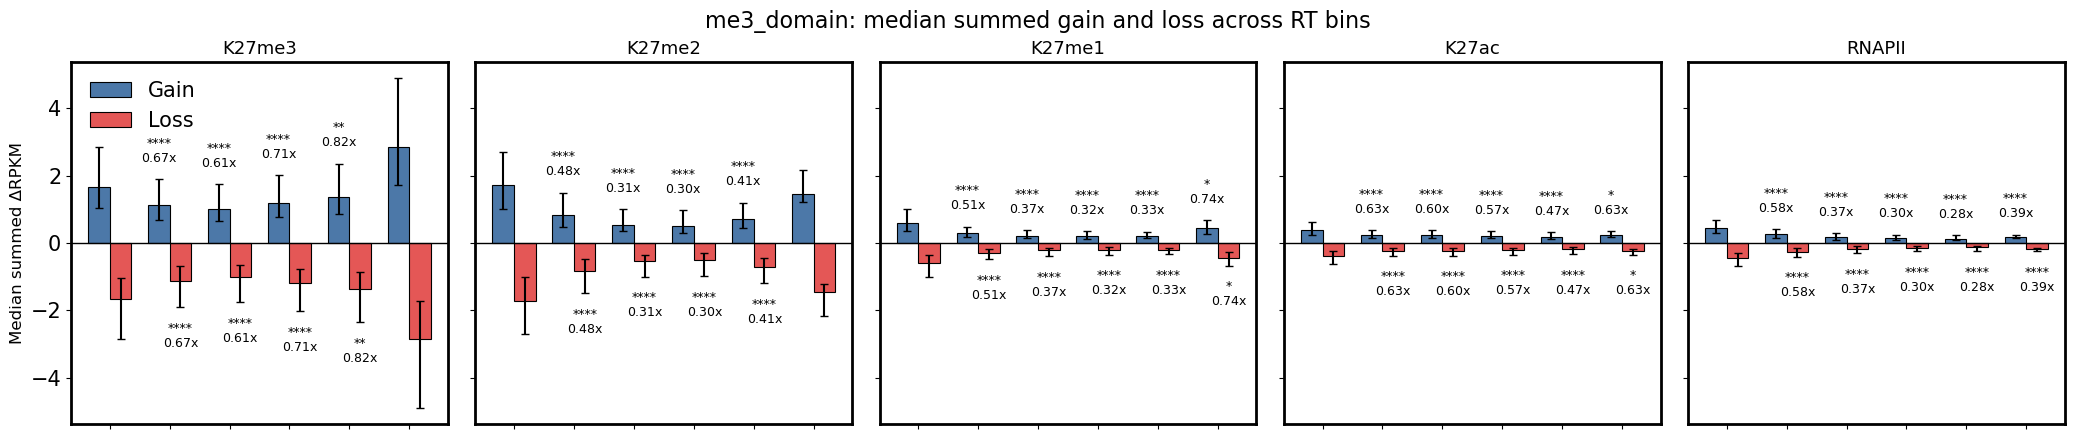

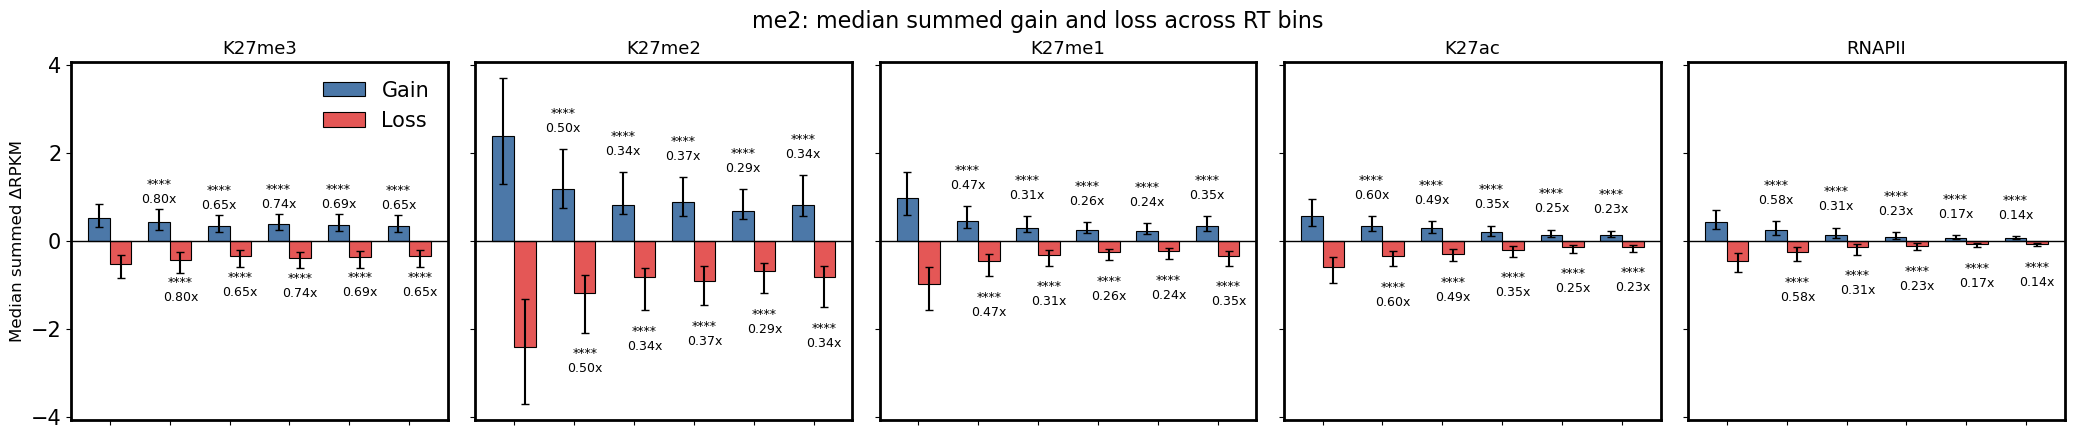

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ======================================================
# Inputs assumed to already exist
#   rt_data
#   bins_idx
#   dfs
#   get_norm_df()
#   fig_dir
# ======================================================

# ======================================================
# Parameters
# ======================================================
cat_names = ['me3_domain', 'me2']
marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']

stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
stage_with_wrap = stage_order + ['G1']
transition_order = ["G1→S1", "S1→S2", "S2→S3", "S3→S4", "S4→G2", "G2→G1"]

plot_mode = "separate"   # kept for compatibility; intended use here is "separate"
alpha = 0.05

gain_loss_colors = {'Gain': '#4C78A8', 'Loss': '#E45756'}

# ======================================================
# RT binning
# ======================================================
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num=7
)
rt_bins[0] = 0
rt_bins[-1] = 1

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]
rt_label_map = dict(enumerate(rt_labels))

# matches your previous logic
rt_series = 1 - bins_idx['RT']
rt_bin_assignment = pd.cut(
    rt_series,
    bins=rt_bins,
    labels=range(len(rt_labels)),
    include_lowest=True,
    right=True
)

# ======================================================
# Normalize once per mark and attach RT bin
# ======================================================
hm_dict = {}
hm_max = {}

for mark, df in zip(marks, dfs):
    norm_df, max_rpkm = get_norm_df(df)
    hm_dict[mark] = norm_df.copy()
    hm_max[mark] = max_rpkm.copy()

for mark in hm_dict:
    df = hm_dict[mark]
    valid_idx = rt_bin_assignment.dropna().index.intersection(df.index)
    hm_dict[mark] = df.loc[valid_idx].copy()
    hm_dict[mark]['rt_bin'] = rt_bin_assignment.loc[valid_idx].values

# ======================================================
# Build per transition delta RPKM table
# ======================================================
rate_list = []

for mark in marks:
    df = hm_dict[mark].copy()

    stage_cols = [s for s in stage_order if s in df.columns]
    if len(stage_cols) != len(stage_order):
        print(f"Skipping {mark}: missing stage columns {set(stage_order) - set(stage_cols)}")
        continue

    # normalized stage profiles
    df_stages = df[stage_cols].copy()
    df_stages['G1_wrap'] = df_stages['G1']

    # transition deltas on normalized scale
    diffs = df_stages[stage_with_wrap].diff(axis=1).iloc[:, 1:]

    # convert back to RPKM scale
    max_vals = hm_max[mark].loc[df.index]
    delta_rpkm = diffs.multiply(max_vals, axis=0)

    delta_rpkm['gene'] = df.index
    delta_rpkm['mark'] = mark
    delta_rpkm['rt_bin'] = df['rt_bin'].values

    rate_list.append(delta_rpkm)

rate_df = pd.concat(rate_list, axis=0)

transition_cols = [c for c in rate_df.columns if c not in ['gene', 'mark', 'rt_bin']]
rate_df = rate_df.rename(columns=dict(zip(transition_cols, transition_order)))

rate_long = rate_df.melt(
    id_vars=['gene', 'mark', 'rt_bin'],
    var_name='transition',
    value_name='delta_rpkm'
).dropna(subset=['delta_rpkm'])

rate_long['transition'] = pd.Categorical(
    rate_long['transition'],
    categories=transition_order,
    ordered=True
)
rate_long['rt_label'] = rate_long['rt_bin'].map(rt_label_map)
rate_long['rt_label'] = pd.Categorical(
    rate_long['rt_label'],
    categories=rt_labels,
    ordered=True
)

rate_long['shape_category'] = rate_long['gene'].map(rt_data['shape_category'])
rate_long = rate_long.loc[rate_long['shape_category'].isin(cat_names)].copy()

# ======================================================
# Sum gains and losses across all transitions per gene per mark
# ======================================================
def sum_gain(vals):
    vals = pd.Series(vals).dropna()
    pos = vals[vals > 0]
    return pos.sum() if len(pos) else 0.0

def sum_loss(vals):
    vals = pd.Series(vals).dropna()
    neg = vals[vals < 0]
    return neg.sum() if len(neg) else 0.0

gene_sums = (
    rate_long
    .groupby(['gene', 'shape_category', 'mark', 'rt_label'], observed=True)['delta_rpkm']
    .agg(
        gain_sum=sum_gain,
        loss_sum=sum_loss
    )
    .reset_index()
)

sum_long = gene_sums.melt(
    id_vars=['gene', 'shape_category', 'mark', 'rt_label'],
    value_vars=['gain_sum', 'loss_sum'],
    var_name='direction_key',
    value_name='summed_delta_rpkm'
)

sum_long['direction_label'] = sum_long['direction_key'].map({
    'gain_sum': 'Gain',
    'loss_sum': 'Loss'
})
sum_long['rt_label'] = pd.Categorical(sum_long['rt_label'], categories=rt_labels, ordered=True)

# ======================================================
# Helpers
# ======================================================
def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def summarize_values(vals):
    vals = pd.Series(vals).dropna()
    if len(vals) == 0:
        return {'median': np.nan, 'q1': np.nan, 'q3': np.nan, 'n': 0}
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    return {'median': med, 'q1': q1, 'q3': q3, 'n': len(vals)}

def fold_label(cur_med, ref_med):
    if pd.isna(cur_med) or pd.isna(ref_med) or ref_med == 0:
        return ""
    return f"{cur_med / ref_med:.2f}x"

def run_test(cur_vals, early_vals, direction):
    cur_vals = pd.Series(cur_vals).dropna()
    early_vals = pd.Series(early_vals).dropna()

    if len(cur_vals) == 0 or len(early_vals) == 0:
        return np.nan

    try:
        if direction == 'Gain':
            # test whether current has less gain than early
            return mannwhitneyu(cur_vals, early_vals, alternative='less').pvalue

        if direction == 'Loss':
            # losses are negative sums
            # less loss than early means current values are less negative
            return mannwhitneyu(cur_vals, early_vals, alternative='greater').pvalue

    except ValueError:
        return np.nan

    return np.nan

def build_summary_and_stats(df, early_rt_label):
    rows = []

    for (cat, mark, direction), sub_all in df.groupby(
        ['shape_category', 'mark', 'direction_label'],
        observed=True
    ):
        early_vals = sub_all.loc[sub_all['rt_label'] == early_rt_label, 'summed_delta_rpkm']
        early_stats = summarize_values(early_vals)
        early_med = early_stats['median']

        for rt in rt_labels:
            cur_vals = sub_all.loc[sub_all['rt_label'] == rt, 'summed_delta_rpkm']
            cur_stats = summarize_values(cur_vals)
            cur_med = cur_stats['median']

            pval = np.nan
            if rt != early_rt_label:
                pval = run_test(cur_vals, early_vals, direction)

            stars = p_to_stars(pval) if (rt != early_rt_label and pd.notna(pval) and pval < alpha) else ""
            fc = fold_label(cur_med, early_med) if stars else ""
            anno = f"{stars}\n{fc}" if stars and fc else stars

            rows.append({
                'shape_category': cat,
                'mark': mark,
                'direction_label': direction,
                'rt_label': rt,
                'median': cur_stats['median'],
                'q1': cur_stats['q1'],
                'q3': cur_stats['q3'],
                'n': cur_stats['n'],
                'pvalue_vs_early': pval,
                'label_vs_early': anno
            })

    out = pd.DataFrame(rows)
    out['rt_label'] = pd.Categorical(out['rt_label'], categories=rt_labels, ordered=True)
    return out

def draw_bars(ax, df, x_order, hue_col=None, hue_order=None, width=0.36,
              y_col='median', q1_col='q1', q3_col='q3',
              colors=None, show_legend=False):
    x = np.arange(len(x_order))

    if hue_col is None:
        sub = df.set_index('rt_label').reindex(x_order).reset_index()
        y = sub[y_col].to_numpy(float)
        q1 = sub[q1_col].to_numpy(float)
        q3 = sub[q3_col].to_numpy(float)
        yerr = np.vstack([y - q1, q3 - y])

        ax.bar(
            x, y, width=0.7, yerr=yerr, capsize=3,
            color='0.55', edgecolor='black', linewidth=0.8
        )
    else:
        offsets = np.linspace(-width / 2, width / 2, len(hue_order))
        for off, hue in zip(offsets, hue_order):
            sub = (
                df.loc[df[hue_col] == hue]
                .set_index('rt_label')
                .reindex(x_order)
                .reset_index()
            )
            y = sub[y_col].to_numpy(float)
            q1 = sub[q1_col].to_numpy(float)
            q3 = sub[q3_col].to_numpy(float)
            yerr = np.vstack([y - q1, q3 - y])

            ax.bar(
                x + off, y, width=width, yerr=yerr, capsize=3,
                color=colors[hue], edgecolor='black', linewidth=0.8, label=hue
            )

        if show_legend:
            ax.legend(frameon=False, title='')

    ax.axhline(0, color='black', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(x_order, rotation=90, ha='right')

def add_annotations(ax, df, x_order, hue_col=None, hue_order=None, width=0.36,
                    y_col='median', q1_col='q1', q3_col='q3',
                    label_col='label_vs_early', pad_frac=0.04):
    ymin, ymax = ax.get_ylim()
    yrng = ymax - ymin if ymax > ymin else 1.0
    x = np.arange(len(x_order))

    if hue_col is None:
        plot_groups = [(0, df)]
    else:
        offsets = np.linspace(-width / 2, width / 2, len(hue_order))
        plot_groups = [
            (off, df.loc[df[hue_col] == hue].copy())
            for off, hue in zip(offsets, hue_order)
        ]

    for off, sub_df in plot_groups:
        sub = sub_df.set_index('rt_label').reindex(x_order).reset_index()

        for i, row in sub.iterrows():
            label = row.get(label_col, "")
            if not label:
                continue

            med = row[y_col]
            q1 = row[q1_col]
            q3 = row[q3_col]
            if pd.isna(med):
                continue

            y_text = (q3 if med >= 0 else q1) + (pad_frac * yrng if med >= 0 else -pad_frac * yrng)
            va = 'bottom' if med >= 0 else 'top'
            ax.text(x[i] + off, y_text, label, ha='center', va=va, fontsize=9)

def plot_panel(ax, sub, mark, show_legend=False):
    draw_bars(
        ax=ax,
        df=sub,
        x_order=rt_labels,
        hue_col='direction_label',
        hue_order=['Gain', 'Loss'],
        width=0.36,
        colors=gain_loss_colors,
        show_legend=show_legend
    )
    add_annotations(
        ax=ax,
        df=sub,
        x_order=rt_labels,
        hue_col='direction_label',
        hue_order=['Gain', 'Loss'],
        width=0.36
    )
    ax.set_title(mark, fontsize=13)
    ax.set_xlabel("")

# ======================================================
# Build stats table
# ======================================================
early_rt = rt_labels[0]

plot_stats = build_summary_and_stats(
    sum_long,
    early_rt_label=early_rt
)

# optional export of underlying per gene sums and plotted stats
gene_sums.to_csv(
    os.path.join(fig_dir, "per_gene_gain_loss_sums_by_RTbin.tsv"),
    sep='\t',
    index=False
)
plot_stats.to_csv(
    os.path.join(fig_dir, "median_gain_loss_sums_by_RTbin_stats.tsv"),
    sep='\t',
    index=False
)

# ======================================================
# Plot
# ======================================================
for cat in cat_names:
    fig, axes = plt.subplots(
        1, len(marks),
        figsize=(4.2 * len(marks), 4.8),
        sharey=True
    )

    if len(marks) == 1:
        axes = [axes]

    for i, (ax, mark) in enumerate(zip(axes, marks)):
        sub = plot_stats.loc[
            (plot_stats['shape_category'] == cat) &
            (plot_stats['mark'] == mark)
        ].copy()

        plot_panel(ax, sub, mark, show_legend=(i == 0))
        ax.set_ylabel("Median summed ΔRPKM" if i == 0 else "", fontsize=12)
        ax.set_xticklabels([])

    fig.suptitle(
        f"{cat}: median summed gain and loss across RT bins",
        y=0.92,
        fontsize=16
    )
    plt.tight_layout()
    fig.savefig(
        os.path.join(fig_dir, f"median_summed_gain_loss_by_RTbin_{cat}_vsEarlyMWU.pdf"),
        bbox_inches="tight"
    )
    plt.show()

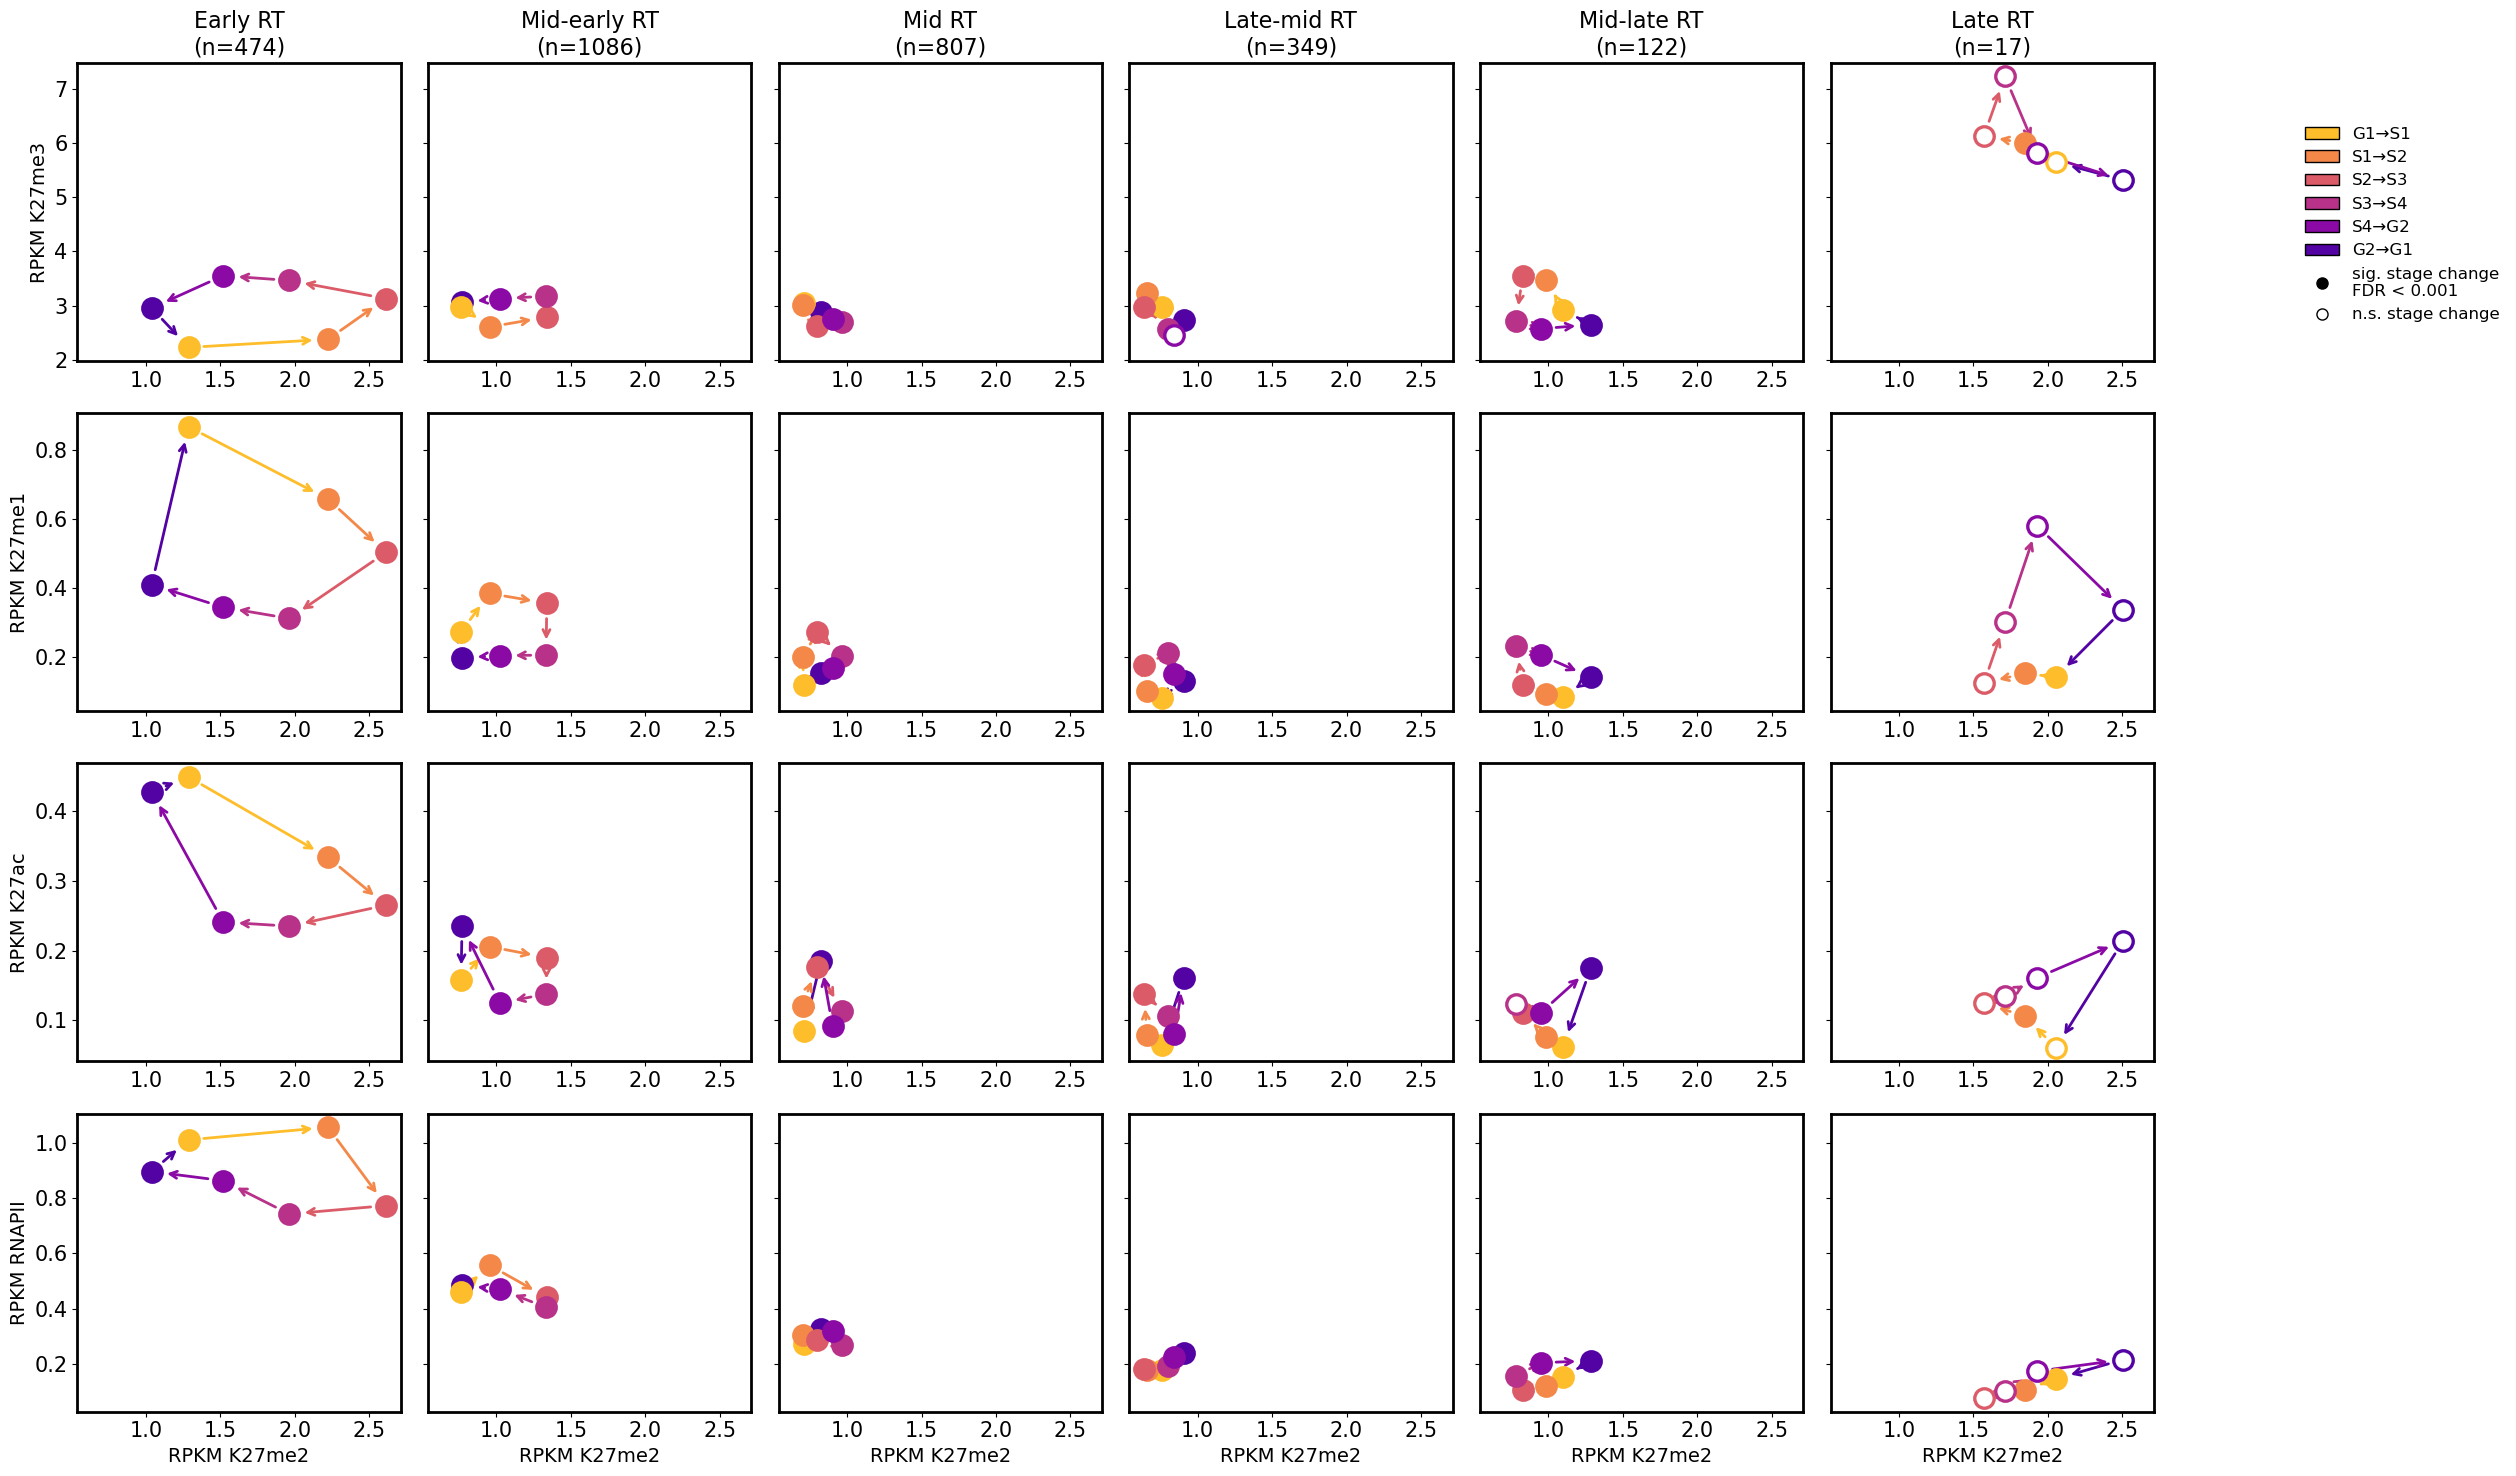

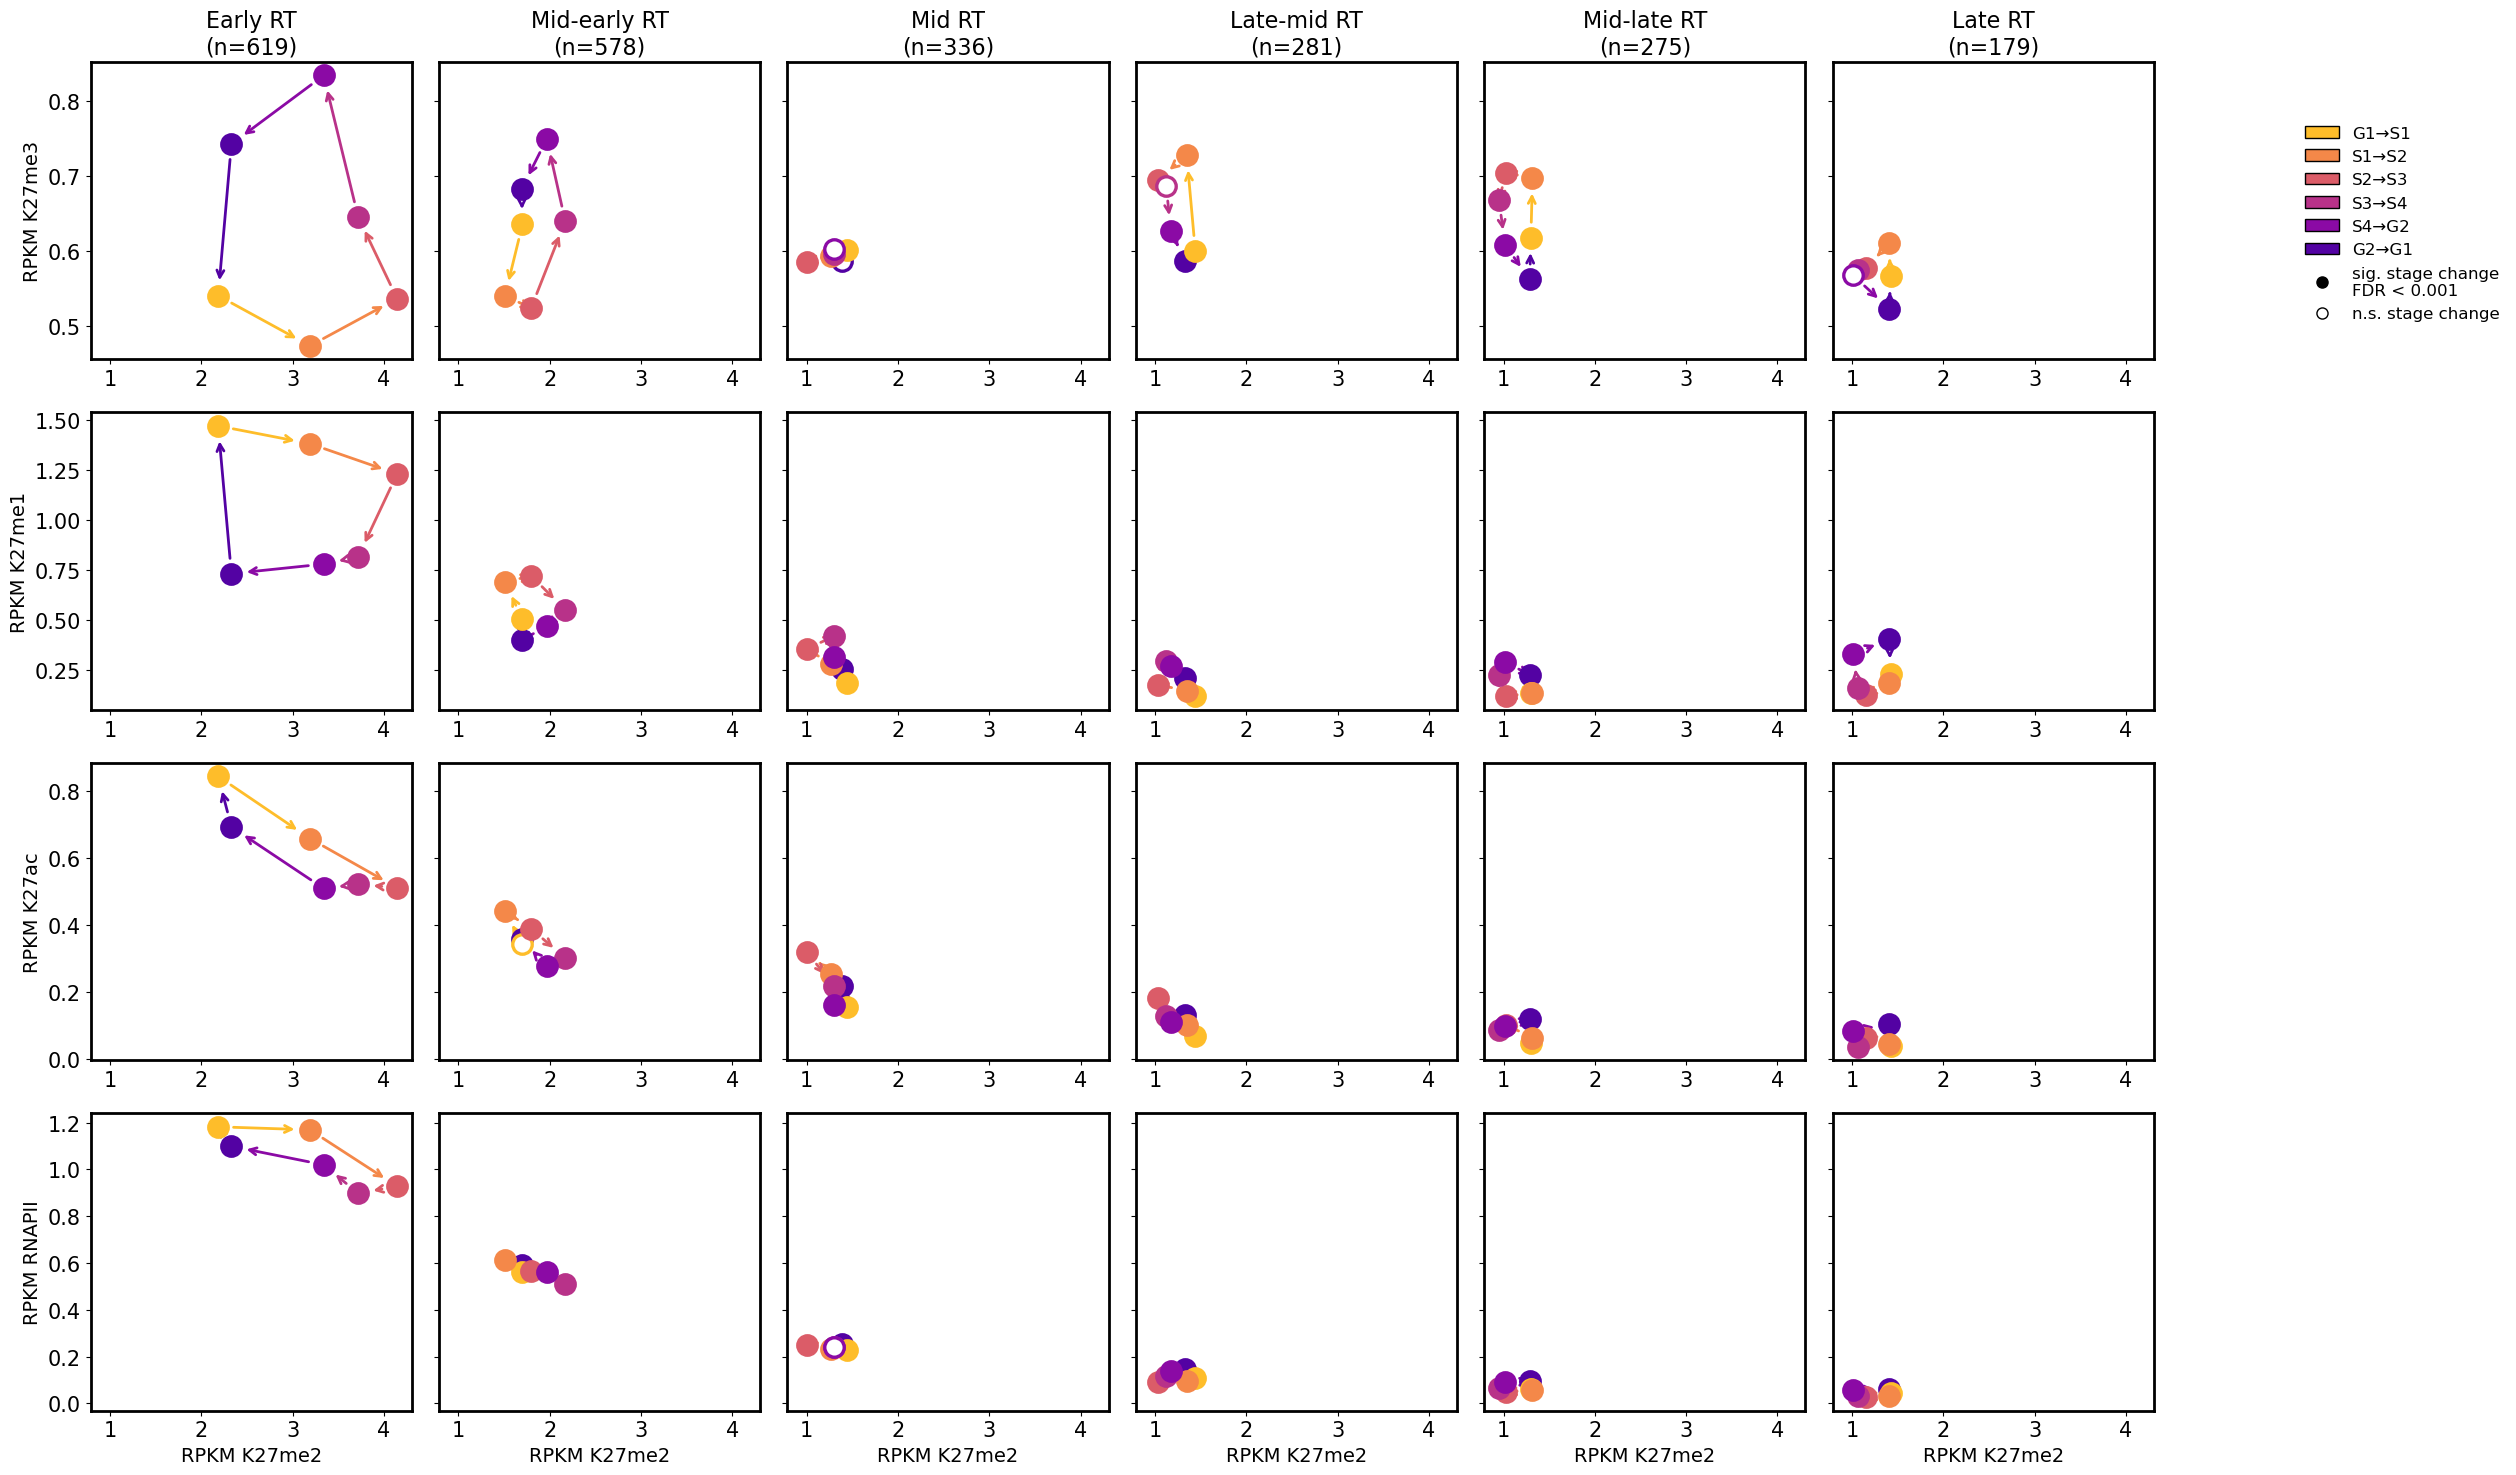

In [25]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy import stats

# Inputs assumed to exist:
#   rt_data, bins_idx, dfs, get_norm_df(), fig_dir

# -----------------------------
# Parameters
# -----------------------------
significance_cutoff = 0.001
min_pairs = 8
marker_size = 14
marker_edgewidth = 2.4
arrow_lw = 2.0
arrow_scale_with_marker = 1.15
cat_names = ['me3_domain', 'me2']

marks = ['K27me3', 'K27me2', 'K27me1', 'K27ac', 'RNAPII']
stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']

# each plotted point is the RPKM at that stage
# the color still represents the transition INTO that stage
stage_to_transition = {
    'G1': 'G2→G1',
    'S1': 'G1→S1',
    'S2': 'S1→S2',
    'S3': 'S2→S3',
    'S4': 'S3→S4',
    'G2': 'S4→G2',
}

transition_order = ["G1→S1", "S1→S2", "S2→S3", "S3→S4", "S4→G2", "G2→G1"]

# transition colors
palette = sns.color_palette("plasma_r", len(transition_order))
transition_color_map = dict(zip(transition_order, palette))

# -----------------------------
# Normalize once per mark
# -----------------------------
hm_dict = {}
hm_max = {}

for mark, df in zip(marks, dfs):
    norm_df, max_rpkm = get_norm_df(df)
    hm_dict[mark] = norm_df
    hm_max[mark] = max_rpkm

# -----------------------------
# RT binning
# -----------------------------
rt_bins = np.linspace(
    np.quantile(rt_data['RT'].dropna(), 0.02),
    np.quantile(rt_data['RT'].dropna(), 0.98),
    num=7
)

rt_bins[0] = 0
rt_bins[-1] = 1

rt_labels = [
    "Early RT",
    "Mid-early RT",
    "Mid RT",
    "Late-mid RT",
    "Mid-late RT",
    "Late RT",
]

rt_label_map = dict(enumerate(rt_labels))

rt_series = 1 - bins_idx['RT']

rt_bin_assignment = pd.cut(
    rt_series,
    bins=rt_bins,
    labels=range(len(rt_labels)),
    include_lowest=True,
    right=True
)

for mark in hm_dict:
    df = hm_dict[mark]
    valid_idx = rt_bin_assignment.dropna().index.intersection(df.index)
    hm_dict[mark] = df.loc[valid_idx].assign(
        rt_bin=rt_bin_assignment.loc[valid_idx]
    )

# -----------------------------
# Stage-specific RPKM table
# -----------------------------
stage_rpkm_list = []

for mark in marks:
    df = hm_dict[mark].copy()

    stage_cols = [s for s in stage_order if s in df.columns]

    if len(stage_cols) != len(stage_order):
        print(f"Skipping {mark}: missing stage columns {set(stage_order) - set(stage_cols)}")
        continue

    # get_norm_df() returns normalized values.
    # multiply by per-gene max RPKM to recover stage-level RPKM.
    max_vals = hm_max[mark].loc[df.index]
    rpkm_df = df[stage_cols].multiply(max_vals, axis=0)

    rpkm_df['gene'] = df.index
    rpkm_df['mark'] = mark
    rpkm_df['rt_bin'] = df['rt_bin'].values

    stage_rpkm_list.append(rpkm_df)

stage_rpkm_df = pd.concat(stage_rpkm_list)

stage_rpkm_long = stage_rpkm_df.melt(
    id_vars=['gene', 'mark', 'rt_bin'],
    var_name='stage',
    value_name='rpkm'
).dropna(subset=['rpkm'])

stage_rpkm_long['stage'] = pd.Categorical(
    stage_rpkm_long['stage'],
    categories=stage_order,
    ordered=True
)

stage_rpkm_long['rt_label'] = stage_rpkm_long['rt_bin'].map(rt_label_map)

stage_rpkm_long['rt_label'] = pd.Categorical(
    stage_rpkm_long['rt_label'],
    categories=rt_labels,
    ordered=True
)

stage_rpkm_wide = stage_rpkm_long.pivot_table(
    index=['gene', 'stage', 'rt_label'],
    columns='mark',
    values='rpkm',
    observed=True
).reset_index()

# -----------------------------
# Multiple-testing correction
# -----------------------------
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    ok = np.isfinite(pvals)

    if ok.sum() == 0:
        return qvals

    p = pvals[ok]
    n = len(p)

    order = np.argsort(p)
    ranked = p[order]

    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    q_full = np.full(n, np.nan, dtype=float)
    q_full[order] = q

    qvals[ok] = q_full

    return qvals

# -----------------------------
# Helpers
# -----------------------------
def get_cat_rt_stage_wide(cat_name, rt_label):
    genes_cat = set(rt_data.loc[rt_data['shape_category'] == cat_name].index)

    return stage_rpkm_wide[
        (stage_rpkm_wide['rt_label'] == rt_label) &
        (stage_rpkm_wide['gene'].isin(genes_cat))
    ].copy()


def compute_within_transition_sig(sub_stage, x_mark, y_mark):
    """
    Tests whether RPKM changes significantly from the previous stage
    into each plotted stage.

    For example:
        S1 point tests G1 vs S1
        S2 point tests S1 vs S2
        G1 point tests G2 vs G1
    """

    tests = []

    for stage in stage_order:
        prev_stage = stage_order[stage_order.index(stage) - 1]

        a = sub_stage[sub_stage["stage"] == prev_stage][["gene", x_mark, y_mark]].copy()
        b = sub_stage[sub_stage["stage"] == stage][["gene", x_mark, y_mark]].copy()

        merged = a.merge(
            b,
            on="gene",
            suffixes=("_from", "_to")
        ).dropna()

        for mark in [x_mark, y_mark]:
            from_vals = merged[f"{mark}_from"].values
            to_vals = merged[f"{mark}_to"].values

            if len(from_vals) < min_pairs:
                p = np.nan
            else:
                diff = to_vals - from_vals

                if np.allclose(diff, 0):
                    p = 1.0
                else:
                    try:
                        p = stats.wilcoxon(
                            from_vals,
                            to_vals,
                            alternative='two-sided'
                        ).pvalue
                    except ValueError:
                        p = np.nan

            tests.append({
                "stage": stage,
                "mark": mark,
                "p": p
            })

    test_df = pd.DataFrame(tests)
    test_df["q"] = bh_fdr(test_df["p"].values)

    sig_map = {}

    for stage, grp in test_df.groupby("stage", observed=True):
        grp = grp.set_index("mark")

        sig_x = (
            x_mark in grp.index and
            pd.notna(grp.loc[x_mark, "q"]) and
            grp.loc[x_mark, "q"] < significance_cutoff
        )

        sig_y = (
            y_mark in grp.index and
            pd.notna(grp.loc[y_mark, "q"]) and
            grp.loc[y_mark, "q"] < significance_cutoff
        )

        sig_map[stage] = bool(sig_x or sig_y)

    return sig_map


def plot_comparison(
    ax,
    sub_stage,
    x_mark,
    y_mark,
    x_label,
    y_label,
    xlim=None,
    ylim=None
):
    """
    Plots median stage RPKM for x_mark and y_mark.

    Each point is the median RPKM at one cell-cycle stage.
    Arrows connect stages in cell-cycle order.
    Filled points indicate significant RPKM change into that stage.
    """

    sub_stage = sub_stage.dropna(subset=[x_mark, y_mark]).copy()

    sig_map = compute_within_transition_sig(
        sub_stage=sub_stage,
        x_mark=x_mark,
        y_mark=y_mark
    )

    mids = []

    for stage in stage_order:
        group = sub_stage[sub_stage["stage"] == stage]

        if group.empty:
            continue

        x_med = group[x_mark].median()
        y_med = group[y_mark].median()
        trans = stage_to_transition[stage]

        mids.append((stage, trans, x_med, y_med))

    shrink_pts = (
        marker_size * 0.55 +
        marker_edgewidth * 0.8
    ) * arrow_scale_with_marker

    # connect stages in order, wrapping G2 back to G1
    if len(mids) > 1:
        mids_closed = mids + [mids[0]]

        for (_, trans0, x0, y0), (_, _, x1, y1) in zip(
            mids_closed[:-1],
            mids_closed[1:]
        ):
            ax.annotate(
                "",
                xy=(x1, y1),
                xytext=(x0, y0),
                zorder=1,
                arrowprops=dict(
                    arrowstyle="->",
                    color=transition_color_map[trans0],
                    lw=arrow_lw,
                    shrinkA=shrink_pts,
                    shrinkB=shrink_pts,
                    mutation_scale=marker_size * 0.9
                ),
            )

    for stage, trans, x_med, y_med in mids:
        color = transition_color_map[trans]
        is_sig = sig_map.get(stage, False)

        ax.plot(
            x_med,
            y_med,
            marker='o',
            linestyle='None',
            markersize=marker_size,
            markeredgewidth=marker_edgewidth,
            markeredgecolor=color,
            markerfacecolor=color if is_sig else 'white',
            zorder=3
        )

    if xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)


# -----------------------------
# Plot
# -----------------------------
for cat in cat_names:
    fig, axes = plt.subplots(
        4,
        len(rt_labels),
        figsize=(3.8 * len(rt_labels), 15.8),
        sharex='row',
        sharey='row'
    )

    if len(rt_labels) == 1:
        axes = np.array(axes).reshape(4, 1)

    for col_idx, rt_label in enumerate(rt_labels):
        sub_stage = get_cat_rt_stage_wide(cat, rt_label)
        n_genes = sub_stage['gene'].nunique()

        plot_comparison(
            axes[0, col_idx],
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27me3",
            x_label="",
            y_label="RPKM K27me3" if col_idx == 0 else ""
        )

        axes[0, col_idx].set_title(
            f"{rt_label}\n(n={n_genes})",
            fontsize=16
        )

        plot_comparison(
            axes[1, col_idx],
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27me1",
            x_label="",
            y_label="RPKM K27me1" if col_idx == 0 else ""
        )

        plot_comparison(
            axes[2, col_idx],
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="K27ac",
            x_label="",
            y_label="RPKM K27ac" if col_idx == 0 else ""
        )

        plot_comparison(
            axes[3, col_idx],
            sub_stage=sub_stage,
            x_mark="K27me2",
            y_mark="RNAPII",
            x_label="RPKM K27me2",
            y_label="RPKM RNAPII" if col_idx == 0 else ""
        )

    legend_elements = [
        Patch(
            facecolor=transition_color_map[t],
            edgecolor='black',
            label=t
        )
        for t in transition_order
    ]

    sig_handles = [
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='None',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=8,
            label=f'sig. stage change\nFDR < {significance_cutoff}'
        ),
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='None',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=8,
            label='n.s. stage change'
        )
    ]

    fig.legend(
        handles=legend_elements + sig_handles,
        bbox_to_anchor=(1.01, 0.8),
        loc="center left",
        fontsize=12,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, 0.96, 0.95])

    fig.savefig(
        os.path.join(
            fig_dir,
            f"20260205_Sup7_circlePlot_{cat}_byRTbin_stageRPKM_sigWithinTransition.pdf"
        ),
        bbox_inches="tight"
    )

    plt.show()

# Domain kinetics

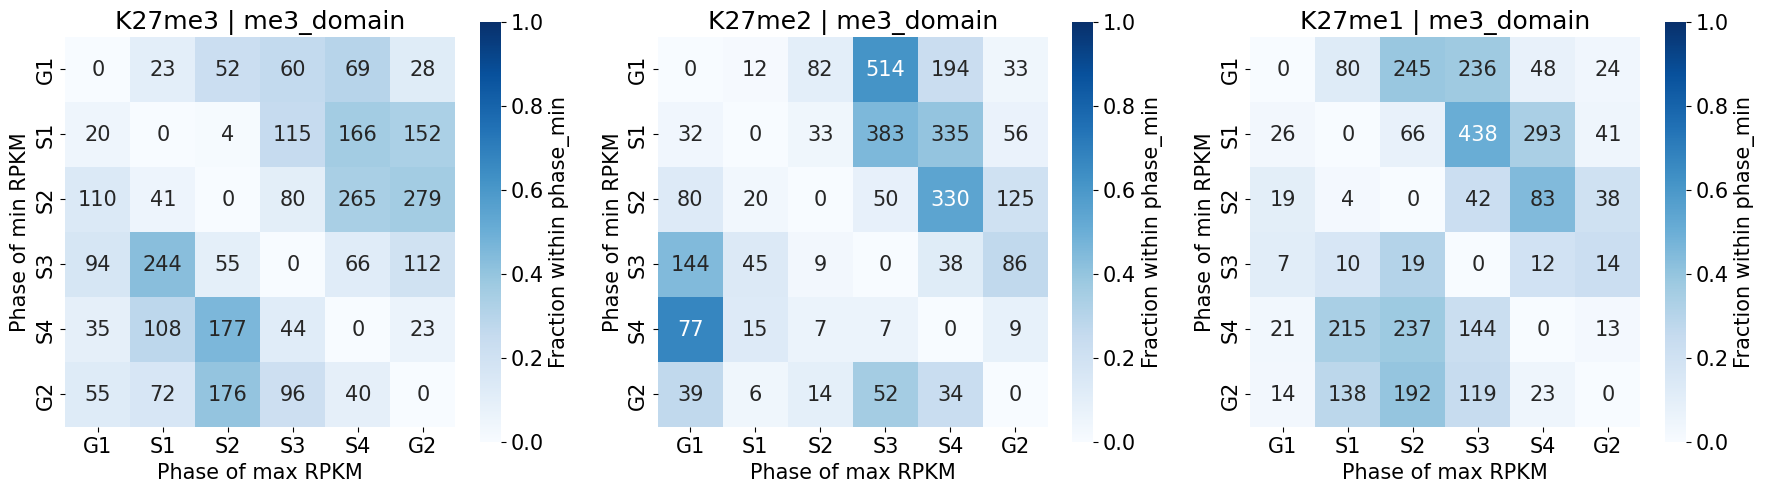

In [328]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

names = ["K27me3", "K27me2", "K27me1"]  # dfs[0..2]
phase_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
MIN_RPKM = 0
CAT_NAME = "me3_domain"   # e.g. "me3_domain", "me2", "me1", ...

def ensure_gene_index(df, gene_col="Geneid"):
    # df already indexed by Geneid (typical)
    if df.index.name == gene_col:
        return df
    # fallback: Geneid column exists
    if gene_col in df.columns:
        out = df.copy()
        out[gene_col] = out[gene_col].astype(str)
        return out.set_index(gene_col, drop=False)
    return df  # assume index already gene ids

def add_phase_bins_from_meanCPM(df, genes_keep, min_rpkm=MIN_RPKM):
    sub = ensure_gene_index(df)

    # subset by rt_data gene set (robust / matches your other code)
    sub = sub.loc[sub.index.intersection(genes_keep)].copy()

    # guard bad lengths
    sub = sub[sub["Length"] > 0].copy()

    # use your actual columns
    stage_cols = [f"meanCPM_{p}" for p in phase_order]
    missing = [c for c in stage_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing meanCPM stage columns: {missing}")

    # CPM → RPKM: RPKM = CPM / (kb)
    rpkm = sub[stage_cols].div(sub["Length"] / 1000.0, axis=0)
    rpkm.columns = phase_order  # make phases clean for idxmax/idxmin

    sub["max_rpkm"] = rpkm.max(axis=1)
    sub["min_rpkm"] = rpkm.min(axis=1)
    sub["phase_max"] = rpkm.idxmax(axis=1)
    sub["phase_min"] = rpkm.idxmin(axis=1)

    # keep if you want it later
    sub["RT_plot"] = 1 - sub["RT"]

    out = sub.loc[sub["max_rpkm"] >= min_rpkm, ["phase_min", "phase_max", "RT_plot"]]
    return out.dropna(subset=["phase_min", "phase_max"])

# gene set from rt_data (same logic as your working get_rt_bin_wide)
genes_cat = set(rt_data.loc[rt_data["shape_category"] == CAT_NAME].index.astype(str))

phase_df_per_mark = [add_phase_bins_from_meanCPM(dfs[i], genes_cat, MIN_RPKM) for i in range(3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, df_, title in zip(axes, phase_df_per_mark, names):
    conf = pd.crosstab(df_["phase_min"], df_["phase_max"])
    conf = conf.reindex(index=phase_order, columns=phase_order, fill_value=0)
    conf_norm = conf.div(conf.sum(axis=1).replace(0, np.nan), axis=0)

    sns.heatmap(
        conf_norm, ax=ax,
        annot=conf, fmt="d",
        cmap="Blues",
        vmin=0, vmax=1,
        square = True,
        cbar_kws={"label": "Fraction within phase_min"},
    )
    ax.set_title(f"{title} | {CAT_NAME}")
    ax.set_xlabel("Phase of max RPKM")
    ax.set_ylabel("Phase of min RPKM")

fig.tight_layout()
plt.show()



=== K27me3: P(phase_max | phase_min) summary ===
min_phase most_likely_max  P(max | min)  n_genes
       G1              S4      0.297414      232
       S1              S4      0.363239      457
       S2              G2      0.360000      775
       S3              S1      0.427320      571
       S4              S2      0.457364      387
       G2              S2      0.400911      439

=== K27me2: P(phase_max | phase_min) summary ===
min_phase most_likely_max  P(max | min)  n_genes
       G1              S3      0.615569      835
       S1              S3      0.456496      839
       S2              S4      0.545455      605
       S3              G1      0.447205      322
       S4              G1      0.669565      115
       G2              S3      0.358621      145

=== K27me1: P(phase_max | phase_min) summary ===
min_phase most_likely_max  P(max | min)  n_genes
       G1              S2      0.387046      633
       S1              S3      0.506944      864
       S2        

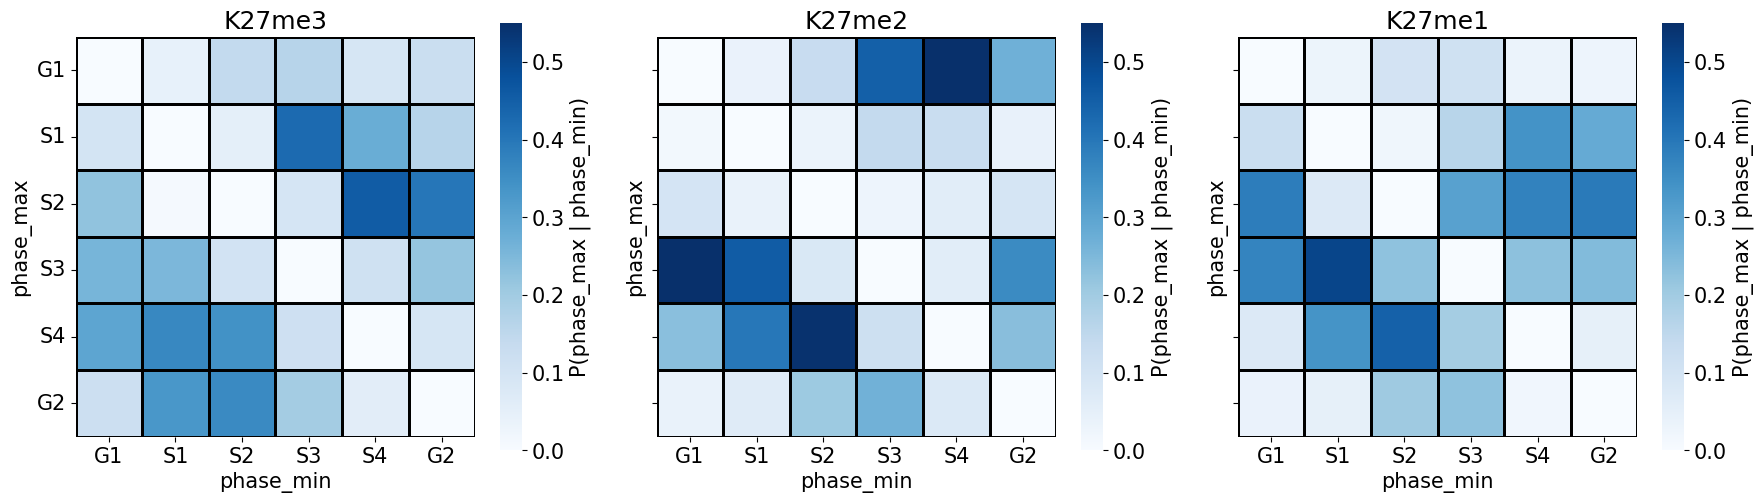

In [329]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# expects: phase_order, names, phase_df_per_mark already defined

phase_to_idx = {p: i for i, p in enumerate(phase_order)}

per_mark_conditional = {}   # row-normalized P(max | min)
per_mark_summary     = {}   # argmax + prob + n

for name, df_ in zip(names, phase_df_per_mark):
    # ---- guard: empty / missing columns ----
    if df_ is None or df_.empty:
        per_mark_conditional[name] = pd.DataFrame(index=phase_order, columns=phase_order, dtype=float)
        per_mark_summary[name] = pd.DataFrame(columns=["min_phase","most_likely_max","P(max | min)","n_genes"])
        continue
    req = {"phase_min", "phase_max"}
    if not req.issubset(df_.columns):
        raise ValueError(f"{name}: phase_df must contain columns {sorted(req)}; got {list(df_.columns)}")

    # ---- contingency: rows=min, cols=max (force categorical order) ----
    d = df_.copy()
    d["phase_min"] = pd.Categorical(d["phase_min"], categories=phase_order, ordered=True)
    d["phase_max"] = pd.Categorical(d["phase_max"], categories=phase_order, ordered=True)

    tab = pd.crosstab(d["phase_min"], d["phase_max"], dropna=False)
    tab = tab.reindex(index=phase_order, columns=phase_order, fill_value=0)

    # ---- row-normalized: P(max | min) ----
    denom = tab.sum(axis=1).replace(0, np.nan)
    row_probs = tab.div(denom, axis=0)
    per_mark_conditional[name] = row_probs

    # ---- summary: for each min, most-likely max + prob ----
    rows = []
    for min_phase in phase_order:
        n = int(tab.loc[min_phase].sum())
        if n == 0:
            continue
        probs = row_probs.loc[min_phase].dropna()
        best_max = probs.idxmax()
        best_prob = float(probs.max())
        rows.append({
            "min_phase": min_phase,
            "most_likely_max": best_max,
            "P(max | min)": best_prob,
            "n_genes": n
        })
    per_mark_summary[name] = pd.DataFrame(rows)

# ---- Look at results ----
for name in names:
    print(f"\n=== {name}: P(phase_max | phase_min) summary ===")
    print(per_mark_summary[name].to_string(index=False))

# ---- Plot: transpose so y=phase_max, x=phase_min ----
fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 5), sharey=True)

# make axes iterable if len(names)==1
axes = np.atleast_1d(axes)

for ax, name in zip(axes, names):
    row_probs = per_mark_conditional[name]

    # if empty, show blank frame with labels
    if row_probs is None or row_probs.empty:
        ax.set_title(name)
        ax.set_xlabel("phase_min")
        ax.set_ylabel("phase_max")
        ax.set_xticks(range(len(phase_order))); ax.set_xticklabels(phase_order, rotation=0)
        ax.set_yticks(range(len(phase_order))); ax.set_yticklabels(phase_order, rotation=0)
        continue

    sns.heatmap(
        row_probs.T, ax=ax, cmap="Blues",
        vmin=0, vmax=0.55,
        annot=False,
        square = True,
        linewidths = 1,
        linecolor = 'black',
        cbar_kws={"label": "P(phase_max | phase_min)"}
    )
    ax.set_title(name)
    ax.set_ylabel("phase_max")
    ax.set_xlabel("phase_min")
    ax.set_xticklabels(phase_order, rotation=0)
    ax.set_yticklabels(phase_order, rotation=0)

fig.tight_layout()
plt.show()


/loc/scratch/47691954/ipykernel_28531/3682257587.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))
/loc/scratch/47691954/ipykernel_28531/3682257587.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))
/loc/scratch/47691954/ipykernel_28531/3682257587.py:54: Depr

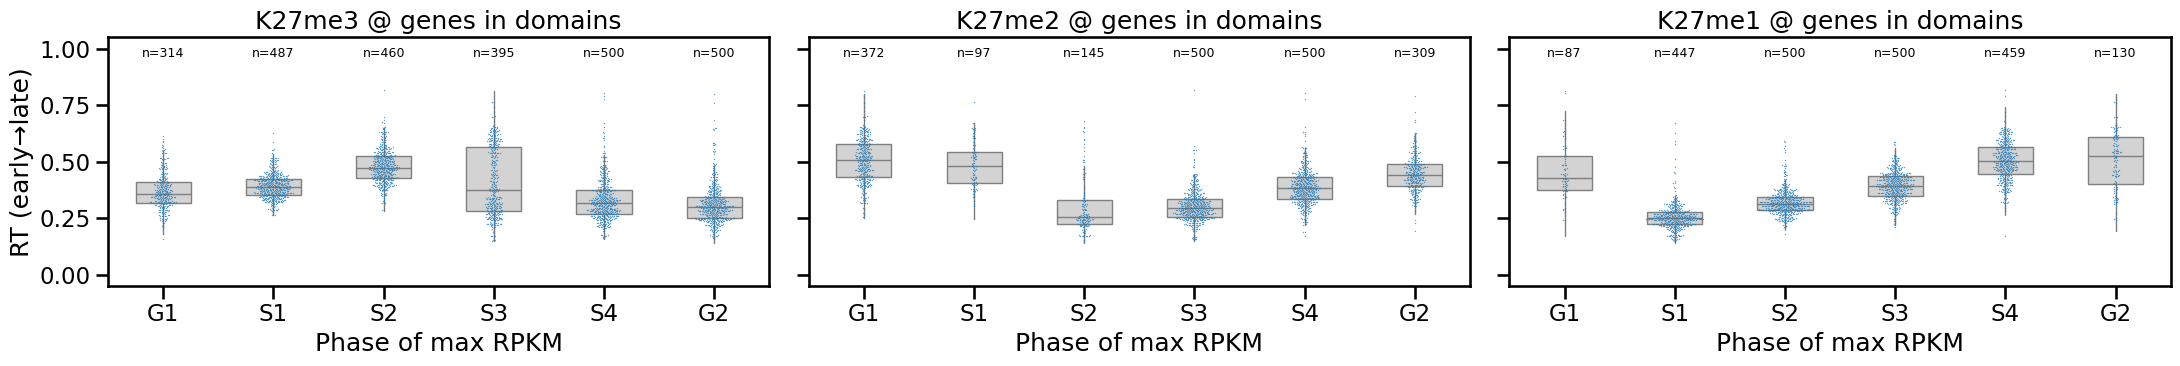

In [330]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

names = ["K27me3", "K27me2", "K27me1"]
phase_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
MIN_RPKM = 0

CAT_NAME = "me3_domain"   # or "me3_domain", "me2", "me1", ...

def ensure_gene_index(df, gene_col="Geneid"):
    if df.index.name == gene_col:
        return df
    if gene_col in df.columns:
        out = df.copy()
        out[gene_col] = out[gene_col].astype(str)
        return out.set_index(gene_col, drop=False)
    return df  # assume index is gene ids

def add_phase_bin(df, genes_keep, min_rpkm=MIN_RPKM):
    sub = ensure_gene_index(df).copy()

    # subset by rt_data-derived gene set (robust)
    sub = sub.loc[sub.index.intersection(genes_keep)].copy()

    # guard bad lengths
    sub = sub[(sub["Length"] > 0)].copy()

    # use your actual stage means
    stage_cols = [f"meanCPM_{p}" for p in phase_order]
    missing = [c for c in stage_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing stage columns: {missing}")

    # CPM -> RPKM
    rpkm = sub[stage_cols].div(sub["Length"] / 1000.0, axis=0)
    rpkm.columns = phase_order

    # phase of MAX RPKM (this was wrong in your snippet: idxmin)
    sub["max_rpkm"]  = rpkm.max(axis=1)
    sub["phase_max"] = rpkm.idxmax(axis=1)

    # RT early->late plotting as you want
    sub["RT_plot"] = 1 - sub["RT"]

    out = sub.loc[sub["max_rpkm"] >= min_rpkm, ["phase_max", "RT_plot"]]
    return out.dropna(subset=["phase_max", "RT_plot"])

def downsample_per_bin(df, cat_col="phase_max", n=500, random_state=0):
    if df is None or df.empty:
        return df
    return (df.groupby(cat_col, group_keys=False, observed=True)
              .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))

# gene set from rt_data (same pattern as your other working code)
genes_cat = set(rt_data.loc[rt_data["shape_category"] == CAT_NAME].index.astype(str))

# Build + downsample
binned = [
    downsample_per_bin(add_phase_bin(dfs[i], genes_cat, MIN_RPKM), n=500, random_state=0)
    for i in range(3)
]

sns.set_context("talk")
fig, axes = plt.subplots(1, 3, figsize=(22, 4), sharey=True)

for ax, df_, title in zip(axes, binned, names):
    if df_ is None or df_.empty:
        ax.set_title(f"{title} | {CAT_NAME} (n=0)")
        ax.set_xlabel("Phase of max RPKM")
        ax.set_xticks(range(len(phase_order)))
        ax.set_xticklabels(phase_order)
        ax.set_ylim(-0.05, 1.05)
        continue

    sns.boxplot(
        data=df_, x="phase_max", y="RT_plot",
        order=phase_order, ax=ax, showcaps=False,
        fliersize=0, width=0.5, color="lightgray"
    )
    sns.swarmplot(
        data=df_, x="phase_max", y="RT_plot",
        order=phase_order, ax=ax, size=1, alpha=0.7
    )

    ax.set_title(f"{title} @ genes in domains")
    ax.set_xlabel("Phase of max RPKM")
    ax.set_xticklabels(phase_order)
    ax.set_ylim(-0.05, 1.05)

    # annotate sampled n per phase
    counts = df_["phase_max"].value_counts().reindex(phase_order, fill_value=0)
    for i, n in enumerate(counts.tolist()):
        ax.text(i, 0.95, f"n={n}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("RT (early→late)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, f"20260205_Sup2a_minRPKM_vRT.pdf"), bbox_inches="tight")

plt.show()


/loc/scratch/46009368/ipykernel_9052/1296535866.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))
/loc/scratch/46009368/ipykernel_9052/1296535866.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))
/loc/scratch/46009368/ipykernel_9052/1296535866.py:54: Depreca

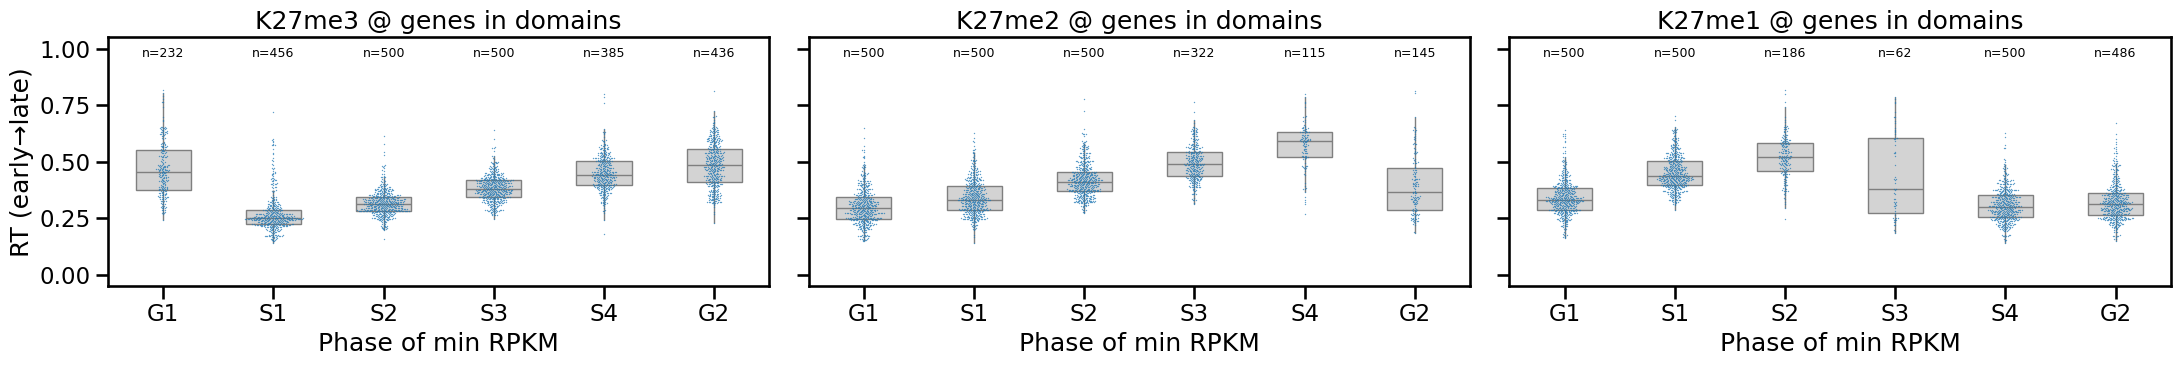

In [187]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

names = ["K27me3", "K27me2", "K27me1"]
phase_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
MIN_RPKM = 0

CAT_NAME = "me3_domain"   # or "me3_domain", "me2", "me1", ...

def ensure_gene_index(df, gene_col="Geneid"):
    if df.index.name == gene_col:
        return df
    if gene_col in df.columns:
        out = df.copy()
        out[gene_col] = out[gene_col].astype(str)
        return out.set_index(gene_col, drop=False)
    return df  # assume index is gene ids

def add_phase_bin(df, genes_keep, min_rpkm=MIN_RPKM):
    sub = ensure_gene_index(df).copy()

    # subset by rt_data-derived gene set (robust)
    sub = sub.loc[sub.index.intersection(genes_keep)].copy()

    # guard bad lengths
    sub = sub[(sub["Length"] > 0)].copy()

    # use your actual stage means
    stage_cols = [f"meanCPM_{p}" for p in phase_order]
    missing = [c for c in stage_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing stage columns: {missing}")

    # CPM -> RPKM
    rpkm = sub[stage_cols].div(sub["Length"] / 1000.0, axis=0)
    rpkm.columns = phase_order

    # phase of MAX RPKM (this was wrong in your snippet: idxmin)
    sub["max_rpkm"]  = rpkm.min(axis=1)
    sub["phase_max"] = rpkm.idxmin(axis=1)

    # RT early->late plotting as you want
    sub["RT_plot"] = 1 - sub["RT"]

    out = sub.loc[sub["max_rpkm"] >= min_rpkm, ["phase_max", "RT_plot"]]
    return out.dropna(subset=["phase_max", "RT_plot"])

def downsample_per_bin(df, cat_col="phase_max", n=500, random_state=0):
    if df is None or df.empty:
        return df
    return (df.groupby(cat_col, group_keys=False, observed=True)
              .apply(lambda g: g.sample(n=min(n, len(g)), random_state=random_state)))

# gene set from rt_data (same pattern as your other working code)
genes_cat = set(rt_data.loc[rt_data["shape_category"] == CAT_NAME].index.astype(str))

# Build + downsample
binned = [
    downsample_per_bin(add_phase_bin(dfs[i], genes_cat, MIN_RPKM), n=500, random_state=0)
    for i in range(3)
]

sns.set_context("talk")
fig, axes = plt.subplots(1, 3, figsize=(22, 4), sharey=True)

for ax, df_, title in zip(axes, binned, names):
    if df_ is None or df_.empty:
        ax.set_title(f"{title} @ genes in domains (n=0)")
        ax.set_xlabel("Phase of min RPKM")
        ax.set_xticks(range(len(phase_order)))
        ax.set_xticklabels(phase_order)
        ax.set_ylim(-0.05, 1.05)
        continue

    sns.boxplot(
        data=df_, x="phase_max", y="RT_plot",
        order=phase_order, ax=ax, showcaps=False,
        fliersize=0, width=0.5, color="lightgray"
    )
    sns.swarmplot(
        data=df_, x="phase_max", y="RT_plot",
        order=phase_order, ax=ax, size=1, alpha=0.7
    )

    ax.set_title(f"{title} @ genes in domains")
    ax.set_xlabel("Phase of min RPKM")
    ax.set_xticklabels(phase_order)
    ax.set_ylim(-0.05, 1.05)

    # annotate sampled n per phase
    counts = df_["phase_max"].value_counts().reindex(phase_order, fill_value=0)
    for i, n in enumerate(counts.tolist()):
        ax.text(i, 0.95, f"n={n}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("RT (early→late)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, f"20260205_Sup2b_maxRPKM_vRT.pdf"), bbox_inches="tight")

plt.show()


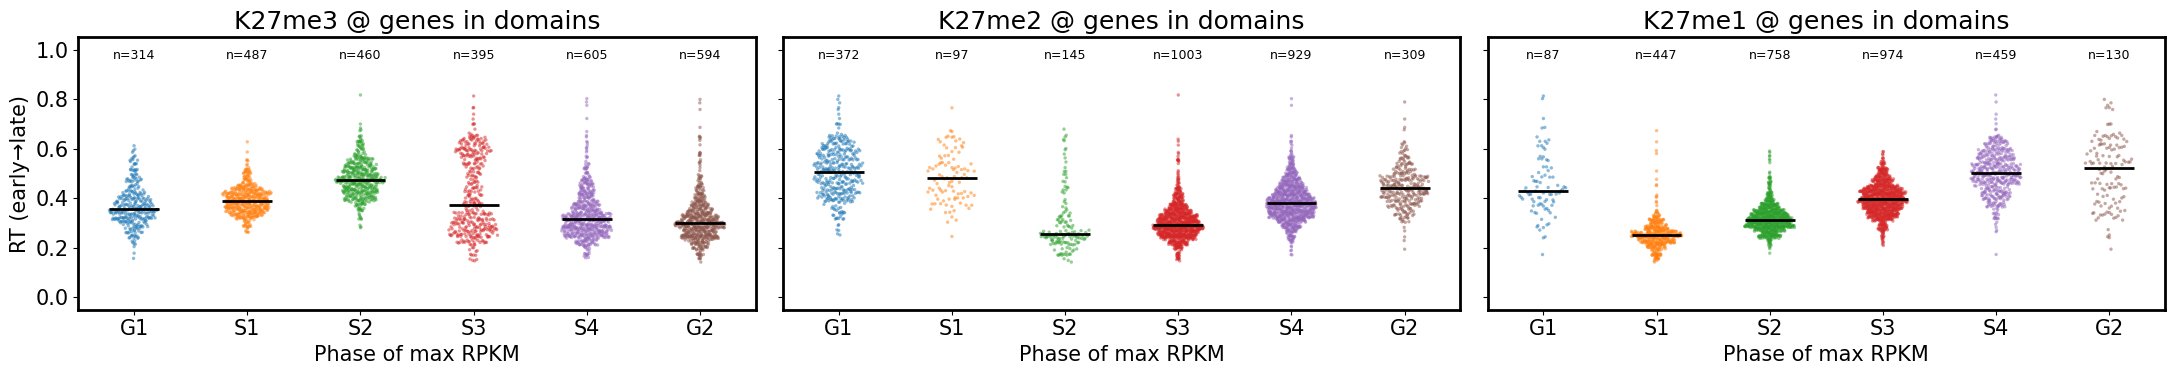

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

names = ["K27me3", "K27me2", "K27me1"]
phase_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
MIN_RPKM = 0

CAT_NAME = "me3_domain"   # or "me2", "me1", ...

# ----------------------------
# Helpers: data prep
# ----------------------------
def ensure_gene_index(df, gene_col="Geneid"):
    if df.index.name == gene_col:
        return df
    if gene_col in df.columns:
        out = df.copy()
        out[gene_col] = out[gene_col].astype(str)
        return out.set_index(gene_col, drop=False)
    return df  # assume index is gene ids

def add_phase_bin(df, genes_keep, min_rpkm=MIN_RPKM):
    sub = ensure_gene_index(df).copy()

    # subset by rt_data-derived gene set (robust)
    sub = sub.loc[sub.index.intersection(genes_keep)].copy()

    # guard bad lengths
    sub = sub[(sub["Length"] > 0)].copy()

    # use your actual stage means
    stage_cols = [f"meanCPM_{p}" for p in phase_order]
    missing = [c for c in stage_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing stage columns: {missing}")

    # CPM -> RPKM
    rpkm = sub[stage_cols].div(sub["Length"] / 1000.0, axis=0)
    rpkm.columns = phase_order

    # phase of MAX RPKM
    sub["max_rpkm"]  = rpkm.max(axis=1)
    sub["phase_max"] = rpkm.idxmax(axis=1)

    # RT early->late plotting
    sub["RT_plot"] = 1 - sub["RT"]

    out = sub.loc[sub["max_rpkm"] >= min_rpkm, ["phase_max", "RT_plot"]]
    return out.dropna(subset=["phase_max", "RT_plot"])


# ----------------------------
# Build (NO DOWNSAMPLING)
# ----------------------------
genes_cat = set(rt_data.loc[rt_data["shape_category"] == CAT_NAME].index.astype(str))

binned = [add_phase_bin(dfs[i], genes_cat, MIN_RPKM) for i in range(3)]

# ----------------------------
# Plot
# ----------------------------
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(22, 4), sharey=True)

for ax, df_, title in zip(axes, binned, names):
    if df_ is None or df_.empty:
        ax.set_title(f"{title} | {CAT_NAME} (n=0)")
        ax.set_xlabel("Phase of max RPKM")
        ax.set_xticks(range(len(phase_order)))
        ax.set_xticklabels(phase_order)
        ax.set_ylim(-0.05, 1.05)
        continue

    # quasirandom points
    geom_quasirandom(
        ax=ax,
        data=df_,
        x_col="phase_max",
        y_col="RT_plot",
        order=phase_order,
        width=0.45,
        nbins=None,
        alpha=0.5,
        size=6,  # matplotlib "s" is area; tune as needed
    )

    # optional: add per-phase median line (replaces boxplot summary)
    for i, p in enumerate(phase_order):
        vals = df_.loc[df_["phase_max"] == p, "RT_plot"].dropna().values
        if vals.size == 0:
            continue
        med = np.median(vals)
        ax.hlines(med, i - 0.22, i + 0.22, linewidth=2, colors = 'black')

    ax.set_title(f"{title} @ genes in domains")
    ax.set_xlabel("Phase of max RPKM")
    ax.set_ylim(-0.05, 1.05)

    # annotate n per phase (FULL COUNTS, no sampling)
    counts = df_["phase_max"].value_counts().reindex(phase_order, fill_value=0)
    for i, n in enumerate(counts.tolist()):
        ax.text(i, 0.95, f"n={n}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("RT (early→late)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Sup2b_maxRPKM_vRT.pdf"), bbox_inches="tight")
plt.show()


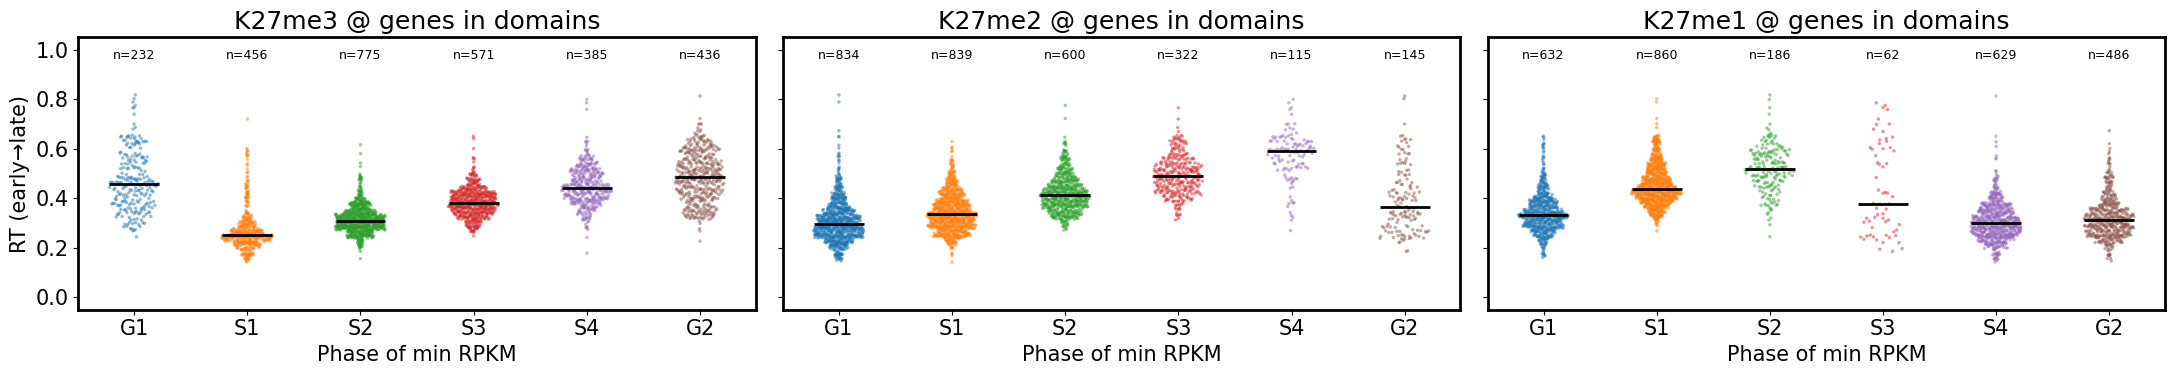

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

names = ["K27me3", "K27me2", "K27me1"]
phase_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
MIN_RPKM = 0

CAT_NAME = "me3_domain"   # or "me2", "me1", ...

# ----------------------------
# Helpers: data prep
# ----------------------------
def ensure_gene_index(df, gene_col="Geneid"):
    if df.index.name == gene_col:
        return df
    if gene_col in df.columns:
        out = df.copy()
        out[gene_col] = out[gene_col].astype(str)
        return out.set_index(gene_col, drop=False)
    return df  # assume index is gene ids

def add_phase_bin(df, genes_keep, min_rpkm=MIN_RPKM):
    sub = ensure_gene_index(df).copy()

    # subset by rt_data-derived gene set (robust)
    sub = sub.loc[sub.index.intersection(genes_keep)].copy()

    # guard bad lengths
    sub = sub[(sub["Length"] > 0)].copy()

    # use your actual stage means
    stage_cols = [f"meanCPM_{p}" for p in phase_order]
    missing = [c for c in stage_cols if c not in sub.columns]
    if missing:
        raise ValueError(f"Missing stage columns: {missing}")

    # CPM -> RPKM
    rpkm = sub[stage_cols].div(sub["Length"] / 1000.0, axis=0)
    rpkm.columns = phase_order

    # phase of MAX RPKM
    sub["max_rpkm"]  = rpkm.min(axis=1)
    sub["phase_max"] = rpkm.idxmin(axis=1)

    # RT early->late plotting
    sub["RT_plot"] = 1 - sub["RT"]

    out = sub.loc[sub["max_rpkm"] >= min_rpkm, ["phase_max", "RT_plot"]]
    return out.dropna(subset=["phase_max", "RT_plot"])


# ----------------------------
# Build (NO DOWNSAMPLING)
# ----------------------------
genes_cat = set(rt_data.loc[rt_data["shape_category"] == CAT_NAME].index.astype(str))

binned = [add_phase_bin(dfs[i], genes_cat, MIN_RPKM) for i in range(3)]

# ----------------------------
# Plot
# ----------------------------
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig, axes = plt.subplots(1, 3, figsize=(22, 4), sharey=True)

for ax, df_, title in zip(axes, binned, names):
    if df_ is None or df_.empty:
        ax.set_title(f"{title} | {CAT_NAME} (n=0)")
        ax.set_xlabel("Phase of min RPKM")
        ax.set_xticks(range(len(phase_order)))
        ax.set_xticklabels(phase_order)
        ax.set_ylim(-0.05, 1.05)
        continue

    # quasirandom points
    geom_quasirandom(
        ax=ax,
        data=df_,
        x_col="phase_max",
        y_col="RT_plot",
        order=phase_order,
        width=0.45,
        nbins=None,
        alpha=0.5,
        size=6,  # matplotlib "s" is area; tune as needed
    )

    # optional: add per-phase median line (replaces boxplot summary)
    for i, p in enumerate(phase_order):
        vals = df_.loc[df_["phase_max"] == p, "RT_plot"].dropna().values
        if vals.size == 0:
            continue
        med = np.median(vals)
        ax.hlines(med, i - 0.22, i + 0.22, linewidth=2, colors = 'black')

    ax.set_title(f"{title} @ genes in domains")
    ax.set_xlabel("Phase of min RPKM")
    ax.set_ylim(-0.05, 1.05)

    # annotate n per phase (FULL COUNTS, no sampling)
    counts = df_["phase_max"].value_counts().reindex(phase_order, fill_value=0)
    for i, n in enumerate(counts.tolist()):
        ax.text(i, 0.95, f"n={n}", ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("RT (early→late)")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "20260205_Sup2a_minRPKM_vRT.pdf"), bbox_inches="tight")
plt.show()


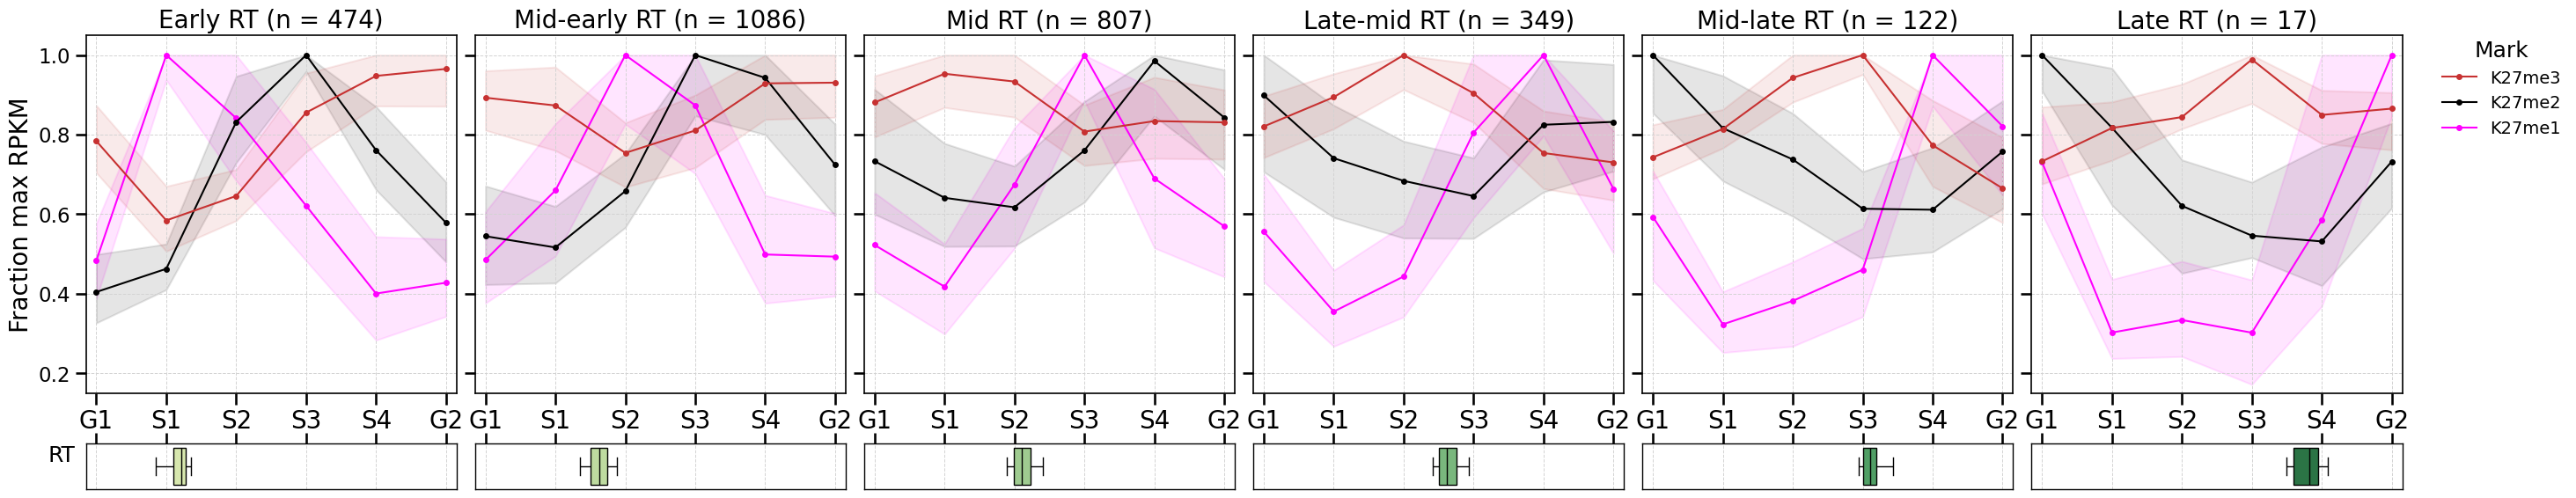

In [188]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# Inputs assumed to already exist:
#   rt_data (index=Geneid, columns include shape_category)
#   bins_idx (index=Geneid, column "RT")
#   rt_bins, rt_labels
#   dfs (same order as marks) and get_norm_df()
# ------------------------------------------------------------

cat_names = ['me3_domains']  # user input, may be plural/alias
marks = ['K27me3', 'K27me2', 'K27me1']
stage_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
stage_to_time = {'G1': 0.0, 'S1': 0.2, 'S2': 0.4, 'S3': 0.6, 'S4': 0.8, 'G2': 1.0}
xlow, xhi = -0.03, 1.03

color_palette = {
    'K27me3': '#C73131',
    'K27me2': '#000000',
    'K27me1': '#FF00FF',
    'K27ac':  '#22D0FB',
    'RNAPII': '#FFC60B'
}

# --- allow common category aliases / typos ---
cat_alias = {
    "me3_domains": "me3_domain",
    "me3_domain": "me3_domain",
    "me3_domains_super": "me3_Super",  # if you ever had this
}
cat_names = [cat_alias.get(c, c) for c in cat_names]

n_rows = len(cat_names)
n_cols = len(rt_labels)

fig = plt.figure(figsize=(28, 6 * n_rows))
gs = fig.add_gridspec(
    2 * n_rows, n_cols,
    height_ratios=[5.5, 0.7] * n_rows,
    hspace=0.25
)

# normalize once per mark (matrix is genes x stages, stages named G1..G2)
hm_dict = {mark: get_norm_df(dfs[i])[0] for i, mark in enumerate(marks)}

for row_idx, cat_name in enumerate(cat_names):

    # ------------------------------------------------------------
    # Step 1: gene set for this category from rt_data
    # ------------------------------------------------------------
    if "shape_category" not in rt_data.columns:
        raise ValueError("rt_data must contain a 'shape_category' column.")

    genes_cat = set(rt_data.index[rt_data["shape_category"] == cat_name].astype(str))

    # ------------------------------------------------------------
    # Step 2: RT series from bins_idx (invert)
    # ------------------------------------------------------------
    if "RT" not in bins_idx.columns:
        raise ValueError("bins_idx must contain an 'RT' column.")

    # keep only genes that have RT values
    rt = bins_idx["RT"].copy()
    rt.index = rt.index.astype(str)
    rt = rt.loc[rt.index.intersection(genes_cat)].dropna()
    rt = 1 - rt
    rt = rt.sort_values()
    genes_sorted = rt.index.tolist()

    # ------------------------------------------------------------
    # Step 3: Filter each mark’s matrix to these genes
    # ------------------------------------------------------------
    local_hm_dict = {}
    for mark, mat in hm_dict.items():
        mat = mat.copy()
        mat.index = mat.index.astype(str)

        keep = mat.index.intersection(genes_sorted)
        m = mat.loc[keep, [c for c in stage_order if c in mat.columns]].copy()

        # drop genes all-NA/0
        m = m.replace(0, np.nan).dropna(how="all")
        local_hm_dict[mark] = m

    # ------------------------------------------------------------
    # Step 4: RT binning on the RT series (aligned to genes)
    # ------------------------------------------------------------
    rt_bin_assignment = pd.cut(
        rt,
        bins=rt_bins,
        labels=range(len(rt_labels)),
        include_lowest=True,
        right=True
    )

    gene_counts = rt_bin_assignment.value_counts(sort=False).reindex(range(len(rt_labels)), fill_value=0)

    # attach rt_bin to each mark, keep only genes that have a bin
    for mark in list(local_hm_dict.keys()):
        m = local_hm_dict[mark]
        m["rt_bin"] = rt_bin_assignment.reindex(m.index)
        local_hm_dict[mark] = m.dropna(subset=["rt_bin"])

    # ------------------------------------------------------------
    # Step 5: Melt to long
    # ------------------------------------------------------------
    long_df = []
    for mark, m in local_hm_dict.items():
        if m.empty:
            continue
        rt_bin_col = m["rt_bin"].astype(int)
        m_stage = m.drop(columns=["rt_bin"])

        # enforce stage order subset
        m_stage = m_stage[[c for c in stage_order if c in m_stage.columns]].copy()
        m_stage["rt_bin"] = rt_bin_col

        melted = m_stage.melt(id_vars="rt_bin", var_name="stage", value_name="dilution")
        melted["mark"] = mark
        long_df.append(melted)

    if not long_df:
        # nothing to plot for this row; still create empty axes
        for col_idx in range(len(rt_labels)):
            ax = fig.add_subplot(gs[2 * row_idx, col_idx])
            ax.set_axis_off()
            ax2 = fig.add_subplot(gs[2 * row_idx + 1, col_idx])
            ax2.set_axis_off()
        continue

    df_plot = pd.concat(long_df, ignore_index=True)
    df_plot["stage"] = pd.Categorical(df_plot["stage"], categories=stage_order, ordered=True)

    # ------------------------------------------------------------
    # Step 6: Summary (median + IQR)
    # ------------------------------------------------------------
    summary = (
        df_plot.dropna(subset=["dilution"])
        .groupby(["rt_bin", "mark", "stage"], observed=False)
        .agg(
            q25=("dilution", lambda x: x.quantile(0.25)),
            median=("dilution", "median"),
            q75=("dilution", lambda x: x.quantile(0.75)),
        )
        .reset_index()
    )
    summary["stage"] = pd.Categorical(summary["stage"], categories=stage_order, ordered=True)

    # ------------------------------------------------------------
    # Step 7: Plot (line+IQR) + RT box per bin
    # ------------------------------------------------------------
    for col_idx, bin_id in enumerate(range(len(rt_labels))):
        ax = fig.add_subplot(gs[2 * row_idx, col_idx])
        bin_data = summary[summary["rt_bin"] == bin_id]

        for mark, mark_data in bin_data.groupby("mark"):
            mark_data = mark_data.sort_values("stage")
            x_vals = mark_data["stage"].map(stage_to_time).astype(float).values

            ax.plot(
                x_vals, mark_data["median"].values,
                label=mark,
                color=color_palette.get(mark, "gray"),
                marker="o", markersize=4, linewidth=1.5
            )
            ax.fill_between(
                x_vals,
                mark_data["q25"].values,
                mark_data["q75"].values,
                color=color_palette.get(mark, "gray"),
                alpha=0.1
            )

        ax.set_xlim(xlow, xhi)
        ax.set_ylim(0.15, 1.05)
        ax.set_xticks(list(stage_to_time.values()))
        ax.set_xticklabels(stage_order, rotation=0, ha="center", fontsize=20)
        ax.set_title(f"{rt_labels[bin_id]} (n = {int(gene_counts.loc[bin_id])})", fontsize=20)
        ax.grid(axis="both", color="lightgray", linestyle="--", linewidth=0.7)

        if col_idx == 0:
            ax.set_ylabel("Fraction max RPKM", fontsize=20)
        else:
            ax.set_yticklabels([])

        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1.2)

        # --- RT boxplot (uses rt values in this bin) ---
        ax2 = fig.add_subplot(gs[2 * row_idx + 1, col_idx])
        subset = rt.loc[rt_bin_assignment == bin_id].dropna()

        if subset.empty:
            ax2.set_axis_off()
            continue

        median_rt = float(subset.median())
        norm = mcolors.Normalize(vmin=0, vmax=1)
        cmap = plt.get_cmap("YlGn")
        box_color = cmap(norm(median_rt))

        sns.boxplot(
            x=subset.values,
            ax=ax2,
            color=box_color,
            fliersize=0,
            linewidth=1,
            linecolor="black",
            orient="h"
        )
        ax2.set_xlim(xlow, xhi)
        ax2.grid(axis="x", linestyle="--", color="lightgray", linewidth=0.7)
        ax2.set_xticks(list(stage_to_time.values()))
        ax2.set_xticklabels("")  # no numeric labels
        ax2.set_yticks([])

        ax2.xaxis.tick_top()
        ax2.tick_params(labelbottom=False, labeltop=False)

        if col_idx == 0:
            ax2.set_ylabel("RT", rotation=0, labelpad=20)
        else:
            ax2.set_ylabel("")

        for spine in ax2.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

# --- Legend (shared) ---
# collect from last non-empty ax
handles, labels = ax.get_legend_handles_labels()
ordered_labels = [m for m in marks if m in color_palette]
pairs = [(h, l) for h, l in zip(handles, labels) if l in ordered_labels]

if pairs:
    pairs.sort(key=lambda x: ordered_labels.index(x[1]))
    hs, ls = zip(*pairs)
    fig.legend(
        hs, ls, title="Mark",
        bbox_to_anchor=(0.98, 0.95), loc="upper left",
        frameon=False, fontsize=14
    )

fig.subplots_adjust(
    left=0.03, right=0.97,
    top=0.93, bottom=0.07,
    wspace=0.05,
    hspace=0.1
)
fig.savefig(os.path.join(fig_dir, f"20260205_Sup2c_maxRPKM_fraction_linePlot_domains.pdf"), bbox_inches="tight")

plt.show()


<Axes: xlabel='time', ylabel='scaled_total'>

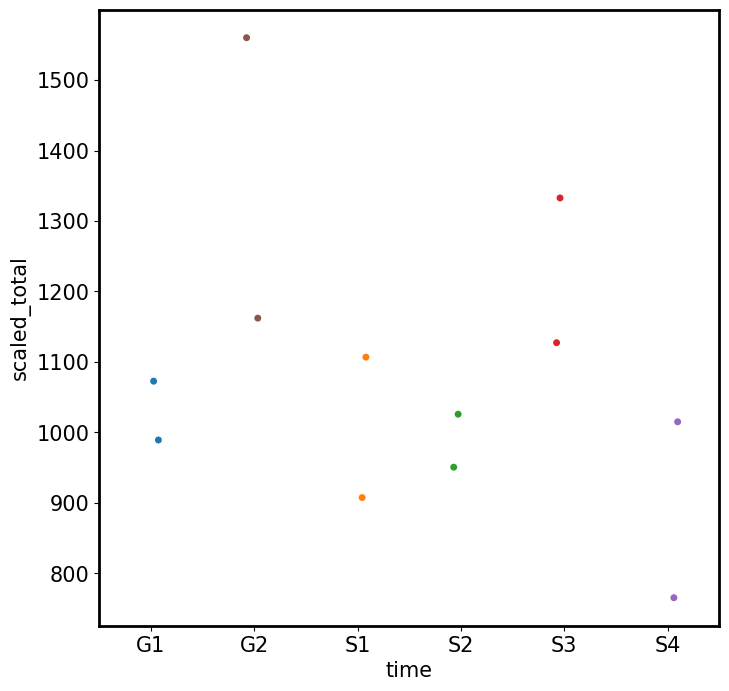

In [403]:
plot_df = gl_df[gl_df['time'] != 'WT']
sns.stripplot(
    plot_df[plot_df['mark'] == "K27me1"],
    x = 'time',
    y = 'scaled_total',
    hue = 'time',
    hue_order = ['G1', 'S1', 'S2', 'S3', 'S4', 'G2']
)

# TRIP

In [67]:
input_file = "data/2024/LAD_data/Dataset_S2_TRIP.tsv"
trip_df = pd.read_csv(input_file, sep="\t")
trip_df.head()

,seqname,strand,position,barcode,pool,expression,LMNB1_DamID,lad,promoter
0,chr18,-,40232902,AAAAAATAAAGACAAC,B,0.000099,3.400148,LAD,ADAMTS1
1,chr4,+,24796264,AAAAAGCACAATTCTG,B,0.137121,-3.067207,iLAD,ADAMTS1
2,chr3,-,153319971,AAAACAAATAGAAAAT,A,4.330387,0.147272,LAD,ADAMTS1
3,chr8,-,24234403,AAAACGAATTACCATG,A,0.159591,1.478695,LAD,ADAMTS1
4,chr6,+,155252188,AAAAGAACAAACAGGC,B,1.001733,-3.455228,iLAD,ADAMTS1


In [68]:
trip_df.reset_index(inplace = True)

In [69]:
beds = {
    "K27me3": "data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/K27me3_K_top95regions.bed",
    "K27me2": "data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/K27me2_K_top95regions.bed",
    "K27me1": "data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/K27me1_K_top95regions.bed",
    "K27ac":  "data/2024/SH_all_data/downsample_peakPRINT_slope1_min300/min350/top95/K27ac_K_top95regions.bed",
}

# centers are typically 1-based in some resources; set zero_based accordingly.
trip_df = annotate_center_overlap_multi(
    df=trip_df,                   # your enhancer dataframe
    beds=beds,
    id_col='index',
    chrom_col="seqname",
    center_col="position",
    zero_based=False,             # set False if your centers are 1-based
    flank=0,                      # or e.g., 250 for ±250 bp window
    col_prefix = ''
)
trip_df.head()

,index,seqname,strand,position,barcode,pool,expression,LMNB1_DamID,lad,promoter,K27me3,K27me2,K27me1,K27ac
0,0,chr18,-,40232902,AAAAAATAAAGACAAC,B,0.000099,3.400148,LAD,ADAMTS1,False,False,False,False
1,1,chr4,+,24796264,AAAAAGCACAATTCTG,B,0.137121,-3.067207,iLAD,ADAMTS1,True,False,False,False
2,2,chr3,-,153319971,AAAACAAATAGAAAAT,A,4.330387,0.147272,LAD,ADAMTS1,False,False,False,False
3,3,chr8,-,24234403,AAAACGAATTACCATG,A,0.159591,1.478695,LAD,ADAMTS1,False,False,False,False
4,4,chr6,+,155252188,AAAAGAACAAACAGGC,B,1.001733,-3.455228,iLAD,ADAMTS1,False,False,True,False


In [70]:
trip_df['log2expression'] = np.log2(trip_df['expression'])

In [71]:
# Booleans (if your mark columns are 0/1, coerce to bool first)
# trip_df[['K27me3','K27me2','K27me1','K27ac']] = trip_df[['K27me3','K27me2','K27me1','K27ac']].astype(bool)

m3_only = (
    trip_df["K27me3"]
    & ~trip_df["K27me2"] & ~trip_df["K27me1"] & ~trip_df["K27ac"]
    & (trip_df["lad"] != "LAD")
)

m2_only = (
    trip_df["K27me2"]
    & ~trip_df["K27me3"] & ~trip_df["K27me1"] & ~trip_df["K27ac"]
    & (trip_df["lad"] != "LAD")
)

m1_only = (
    trip_df["K27me1"]
    & ~trip_df["K27me2"] & ~trip_df["K27me3"] #& ~trip_df["K27ac"]   # exclude K27ac too
    & (trip_df["lad"] != "LAD")
)

ac_only = (
    trip_df["K27ac"]
    & ~trip_df["K27me2"] & ~trip_df["K27me3"] & ~trip_df["K27me1"]
    & (trip_df["lad"] != "LAD")
)

lad_only = (
    (trip_df["lad"] == "LAD")
    & ~trip_df["K27ac"] & ~trip_df["K27me2"] & ~trip_df["K27me3"] & ~trip_df["K27me1"]
)

none = (
    ~trip_df["K27ac"] & ~trip_df["K27me2"] & ~trip_df["K27me3"] & ~trip_df["K27me1"]
    & (trip_df["lad"] != "LAD")
)

df_marked = trip_df.copy()
conds   = [lad_only, m3_only, m2_only, m1_only, ac_only, none]
labels  = ["LAD_only", "K27me3_only", "K27me2_only", "K27me1_K27ac", "K27ac_only", "noK27_noLAD"]

df_marked["mark_group"] = np.select(conds, labels, default="mixed")

# If you want to drop mixed:
filtered_trip = df_marked[df_marked["mark_group"] != "mixed"].copy()

filtered_trip['mark_group'].value_counts()


mark_group
noK27_noLAD     5346
LAD_only        2756
K27ac_only      2601
K27me1_K27ac     553
K27me2_only      532
K27me3_only      519
Name: count, dtype: int64

In [72]:
trip_df['index'].isin(filtered_trip['index']).value_counts()

index
True     12307
False      505
Name: count, dtype: int64

In [73]:
trip_df_iLAD = trip_df[trip_df['lad'] != 'LAD']
trip_df_iLAD['index'].isin(filtered_trip['index']).value_counts()

index
True     9551
False     266
Name: count, dtype: int64

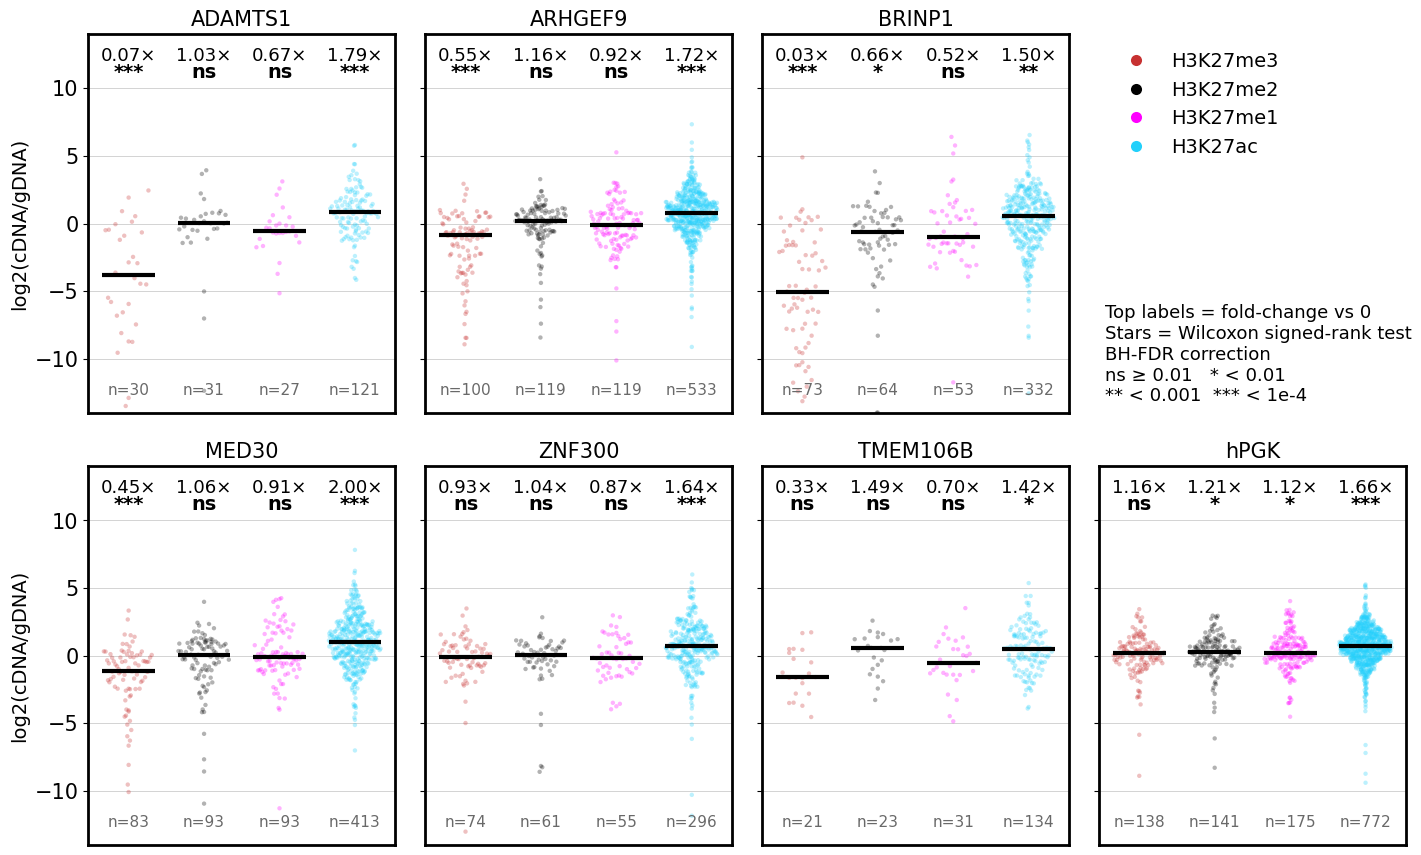

In [76]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon

# =========================
# Config
# =========================
order = ["K27me3_only", "K27me2_only", "K27me1_K27ac", "K27ac_only"]
display_labels = ["H3K27me3", "H3K27me2", "H3K27me1", "H3K27ac"]

palette = ["#C73131", "#000000", "#FF00FF", "#22D0FB"]
palette_map = dict(zip(order, palette))

promoter_order = [
    "ADAMTS1", "ARHGEF9", "BRINP1",
    "MED30", "ZNF300", "TMEM106B", "hPGK"
]

plot_df = filtered_trip[filtered_trip["promoter"].isin(promoter_order)].copy()
plot_df = plot_df[plot_df["mark_group"].isin(order)].copy()

def p_to_stars(p):
    if p < 1e-4:
        return "***"
    if p < 1e-3:
        return "**"
    if p < 1e-2:
        return "*"
    return "ns"

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    ok = np.isfinite(pvals)
    if ok.sum() == 0:
        return qvals

    p = pvals[ok]
    n = len(p)
    order_idx = np.argsort(p)
    ranked = p[order_idx]

    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    q_full = np.full(n, np.nan, dtype=float)
    q_full[order_idx] = q
    qvals[ok] = q_full
    return qvals

# =========================
# Collect ALL p-values first
# =========================
stat_results = []  # (prom, cat, p_raw)

for prom in promoter_order:
    df_sub = plot_df[plot_df["promoter"] == prom]

    for cat in order:
        vec = df_sub.loc[df_sub["mark_group"] == cat, "log2expression"].dropna()

        if len(vec) < 3:
            continue

        if np.allclose(vec, 0):
            p = 1.0
        else:
            try:
                p = wilcoxon(vec, alternative="two-sided").pvalue
            except Exception:
                p = np.nan

        stat_results.append((prom, cat, p))

# -------------------------
# BH-FDR correction
# -------------------------
raw_pvals = np.array([r[2] for r in stat_results], dtype=float)
adj_pvals = bh_fdr(raw_pvals)

p_adj_map = {}
for (prom, cat, _), p_adj in zip(stat_results, adj_pvals):
    p_adj_map[(prom, cat)] = p_adj

# =========================
# Plot
# =========================
fig, axes = plt.subplots(2, 4, figsize=(15, 8.8), sharey=True)
axes = axes.flatten()

axes_map = {
    0: "ADAMTS1", 1: "ARHGEF9", 2: "BRINP1",
    4: "MED30",   5: "ZNF300",  6: "TMEM106B", 7: "hPGK"
}

for idx, prom in axes_map.items():
    ax = axes[idx]
    df_sub = plot_df[plot_df["promoter"] == prom].copy()

    full_counts = [
        (df_sub["mark_group"] == cat).sum()
        for cat in order
    ]

    # -------------------------
    # quasirandom points
    # -------------------------
    geom_quasirandom(
        ax=ax,
        data=df_sub,
        x_col="mark_group",
        y_col="log2expression",
        order=order,
        width=0.7,
        nbins=None,
        colors=[palette_map[k] for k in order],
        alpha=0.3,
        size=10,
        zorder=2,
    )

    # -------------------------
    # medians
    # -------------------------
    med_full = (
        df_sub.groupby("mark_group")["log2expression"]
        .median()
        .reindex(order)
    )

    for xi, y in enumerate(med_full):
        if pd.notna(y):
            ax.hlines(y, xi - 0.35, xi + 0.35, lw=3, color="black", zorder=5)

    # -------------------------
    # panel limits and annotation bands
    # -------------------------
    ymin = -14
    ymax = 14
    ax.set_ylim(ymin, ymax)

    fc_y = ymax - 0.90
    star_y = ymax - 2.10
    n_y = ymin + 1.10

    for xi, cat in enumerate(order):
        vec = df_sub.loc[df_sub["mark_group"] == cat, "log2expression"].dropna()
        if len(vec) == 0:
            continue

        median = vec.median()
        fc = 2 ** median
        p_adj = p_adj_map.get((prom, cat), np.nan)
        star = p_to_stars(p_adj) if pd.notna(p_adj) else "ns"

        ax.text(
            xi, fc_y, f"{fc:.2f}×",
            ha="center", va="top",
            fontsize=13
        )

        ax.text(
            xi, star_y, star,
            ha="center", va="top",
            fontsize=14,
            fontweight="bold"
        )

    for xi, n_full in enumerate(full_counts):
        if n_full > 0:
            ax.text(
                xi, n_y, f"n={n_full:,}",
                ha="center", va="bottom",
                fontsize=11, color="dimgray"
            )

    ax.set_title(prom, fontsize=15)
    ax.set_xlabel("")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)
    ax.grid(color="lightgray", linewidth=0.7, axis="y", zorder=1)

# y labels
axes[0].set_ylabel("log2(cDNA/gDNA)", fontsize=14)
axes[4].set_ylabel("log2(cDNA/gDNA)", fontsize=14)

# =========================
# Legend panel
# =========================
legend_ax = axes[3]
legend_ax.axis("off")

handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=8,
        markerfacecolor=palette_map[k],
        markeredgecolor='none'
    )
    for k in order
]

legend_ax.legend(
    handles,
    display_labels,
    loc="upper left",
    frameon=False,
    fontsize=14
)

legend_ax.text(
    0.02, 0.02,
    "Top labels = fold-change vs 0\n"
    "Stars = Wilcoxon signed-rank test\n"
    "BH-FDR correction\n"
    "ns ≥ 0.01   * < 0.01\n"
    "** < 0.001  *** < 1e-4",
    transform=legend_ax.transAxes,
    fontsize=13,
    ha="left",
    va="bottom"
)

plt.tight_layout(w_pad=1.2, h_pad=1.4)
plt.savefig(os.path.join(fig_dir, "TRIP_K562_null_test_BHFDR.pdf"), bbox_inches="tight")
plt.show()

In [78]:
plot_df.to_csv('data/2024/LAD_data/H3K27_TRIP.tsv',sep ='\t')

# RNAPII cell cycle

In [81]:
import pandas as pd
import numpy as np
import gseapy as gp
from statsmodels.stats.multitest import multipletests


In [82]:
import json
from pathlib import Path
import pandas as pd

# — 1) point to your JSON file —
json_path = Path(
    "data/2024/RepliTag/refs/GOBP_CELL_CYCLE.v2025.1.Hs.json"
).expanduser()

# — 2) load and pull out the gene list —
with open(json_path, "r") as f:
    js = json.load(f)

# adjust this if your JSON uses a different field name:
cell_cycle_genes = set(js["GOBP_CELL_CYCLE"]["geneSymbols"])

In [83]:
# — 3) your existing DataFrame, with a "gene" column and some "meanCPM_<stage>" cols —
df = dfs[4].copy()

# — 4) add the boolean flag for membership in cell cycle —
df["in_cell_cycle"] = df.index.isin(cell_cycle_genes)

# — 5) find all the meanCPM columns (they start with "meanCPM_") —
mean_cols = [c for c in df.columns if c.startswith("meanCPM_")
             and not c.endswith("_SS")]

# (optional safety) keep only numeric meanCPM cols
# mean_cols = [c for c in mean_cols if pd.api.types.is_numeric_dtype(df[c])]

# — 6) for each row, pick the column name with the highest value —
df["max"] = df[mean_cols].idxmax(axis=1).str.replace(r"^meanCPM_", "", regex=True)

# 1) Define the exact stage order
stage_order = ["G1", "S1", "S2", "S3", "S4", "G2"]
df["max"] = pd.Categorical(df["max"], categories=stage_order, ordered=True)

# 2) sort by stage (and keep a stable within-stage order by gene index)
df = df.sort_values(["max"], kind="mergesort")

# — 7) done! —
print(df[["in_cell_cycle", "max"]].head())
df["in_cell_cycle"].value_counts()
df["max"].value_counts()

         in_cell_cycle max
Geneid                    
KLHL17           False  G1
PLEKHN1          False  G1
PERM1            False  G1
AGRN             False  G1
TNFRSF4          False  G1


max
G1    4440
S2    3790
S4    3347
G2    3153
S1    2807
S3    2470
Name: count, dtype: int64

In [17]:
FDR = 0.001
rpkm_thresh = 0.5
df_fc = df[(df['FDR_allTP'] < FDR) & (df["max_RPKM"] >= rpkm_thresh)]
df_fc

gene_set_name = 'MSigDB_Hallmark_2020' #'GO_Biological_Process_2025'
outdir_base   = 'enrichr_results'   # parent folder; gseapy will create subfolders
organism = 'Human'                  # change to 'Mouse' if needed
top_n = None   

enr = gp.enrichr(
    gene_list=df_fc.index.to_list(),
    gene_sets=gene_set_name,
    organism=organism,
)
res = enr.res2d.copy()
res

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,G2-M Checkpoint,126/200,3.045257e-44,1.522629e-42,0,0,7.748801,776.431085,JPT1;CCNF;HNRNPU;MKI67;SMC4;CDC20;RPS6KA5;PTTG...
1,MSigDB_Hallmark_2020,E2F Targets,116/200,8.248173e-36,2.062043e-34,0,0,6.263123,505.954303,DCLRE1B;JPT1;NUP107;TFRC;CSE1L;CCP110;BUB1B;MK...
2,MSigDB_Hallmark_2020,Myc Targets V1,96/200,1.268956e-21,2.114927e-20,0,0,4.158080,200.070583,YWHAE;SLC25A3;MCM7;RPLP0;HNRNPU;PWP1;UBE2L3;CD...
3,MSigDB_Hallmark_2020,mTORC1 Signaling,92/200,3.315403e-19,4.144254e-18,0,0,3.832032,163.055032,GSK3B;TFRC;PITPNB;CCNF;UBE2D3;ITGB2;SLC2A1;ATP...
4,MSigDB_Hallmark_2020,Mitotic Spindle,85/199,1.811353e-15,1.811353e-14,0,0,3.346377,113.591769,TOP2A;YWHAE;KIF11;WASL;SMC4;KIF15;LMNB1;PREX1;...
5,MSigDB_Hallmark_2020,heme Metabolism,66/200,5.688852e-07,4.740710e-06,0,0,2.196252,31.581197,NARF;TFRC;SLC2A1;SLC4A1;SLC7A11;NUDT4;UROD;CDC...
6,MSigDB_Hallmark_2020,Unfolded Protein Response,38/113,8.433998e-05,6.024285e-04,0,0,2.250127,21.107662,EIF4A2;H2AX;NOLC1;HSP90B1;HERPUD1;CKS1B;SERP1;...
7,MSigDB_Hallmark_2020,Myc Targets V2,23/58,1.332647e-04,8.329041e-04,0,0,2.913632,25.998842,PLK4;NPM1;CBX3;PLK1;NOLC1;IMP4;TFB2M;PA2G4;PPR...
8,MSigDB_Hallmark_2020,Androgen Response,32/100,7.896782e-04,4.387101e-03,0,0,2.087376,14.911972,TNFAIP8;INSIG1;ABHD2;NGLY1;UAP1;HMGCR;MYL12A;U...
9,MSigDB_Hallmark_2020,PI3K/AKT/mTOR Signaling,33/105,9.371276e-04,4.685638e-03,0,0,2.033071,14.175979,ATF1;GSK3B;RALB;CAB39;YWHAB;UBE2D3;PTEN;SLC2A1...


In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_enrichr_bubble(
    res2d: pd.DataFrame,
    library_label: str = "MSigDB Hallmark 2020",
    title_prefix: str = "RNAPII Differentially Marked Genes",
    n_input_genes: int | None = None,
    fdr_max: float | None = None,
    rpkm_min: float | None = None,
    top_n: int = 10,
    cmap: str = "autumn_r",
    figsize=(4, 6.2),
    size_scale: float = 900.0,
    size_legend_fracs=(0.20, 0.40, 0.60, 0.80),
    y_label_mode: str = "n",        # "n" (set size), "overlap" (k/n), "k" (overlap only), "none"
    xpad_frac: float = 0.04,        # pad xlim by this fraction of x-range on both sides
    right_margin: float = 0.78,     # reserve right-side space so legends/colorbar aren't truncated
):
    df = res2d.copy()

    # ---- column normalization ----
    colmap = {c.lower().strip(): c for c in df.columns}
    def _need(name):
        key = name.lower()
        if key not in colmap:
            raise ValueError(f"Missing required column: '{name}'")
        return colmap[key]

    term_col     = _need("Term")
    comb_col     = _need("Combined Score")
    fdr_col      = _need("Adjusted P-value")
    overlap_col  = _need("Overlap")

    # ---- parse Overlap "k/n" ----
    k, n = [], []
    for v in df[overlap_col].astype(str):
        m = re.match(r"^\s*(\d+)\s*/\s*(\d+)\s*$", v)
        if not m:
            k.append(np.nan); n.append(np.nan)
        else:
            k.append(int(m.group(1))); n.append(int(m.group(2)))
    df["_k"] = k
    df["_n"] = n
    df["_frac"] = df["_k"] / df["_n"]

    # ---- coerce numeric + clean ----
    df[comb_col] = pd.to_numeric(df[comb_col], errors="coerce")
    df[fdr_col]  = pd.to_numeric(df[fdr_col],  errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[term_col, comb_col, fdr_col, "_frac"])

    # ---- select top_n by FDR ----
    df = df.sort_values(fdr_col, ascending=True).head(top_n).copy()

    # ---- plot order: low->high combined score (so higher appears lower unless you invert)
    # You said: "dont truncate plot, pad xlim" (no change requested to ordering here),
    # keeping your current ascending order.
    df = df.sort_values(comb_col, ascending=True).reset_index(drop=True)

    # ---- aesthetics ----
    df["_neglog10_fdr"] = -np.log10(df[fdr_col].astype(float).clip(lower=1e-300))
    sizes = (df["_frac"].astype(float) * size_scale).to_numpy()
    x = df[comb_col].to_numpy(dtype=float)
    y = np.arange(len(df))

    # y labels
    terms = df[term_col].astype(str).tolist()
    if y_label_mode == "n":
        ylabels = [f"{t} (n={int(nn)})" if np.isfinite(nn) else t for t, nn in zip(terms, df["_n"])]
    elif y_label_mode == "overlap":
        ylabels = [f"{t} ({int(kk)}/{int(nn)})" if np.isfinite(nn) else t for t, kk, nn in zip(terms, df["_k"], df["_n"])]
    elif y_label_mode == "k":
        ylabels = [f"{t} (k={int(kk)})" if np.isfinite(kk) else t for t, kk in zip(terms, df["_k"])]
    elif y_label_mode == "none":
        ylabels = terms
    else:
        raise ValueError("y_label_mode must be one of: 'n','overlap','k','none'")

    # ---- figure ----
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        x, y,
        s=sizes,
        c=df["_neglog10_fdr"].to_numpy(),
        cmap=cmap,
        edgecolors="black",
        linewidths=0.8,
        zorder=3,
    )

    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.8, zorder=0)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    ax.set_yticks(y)
    ax.set_yticklabels(ylabels)
    ax.set_xlabel("Combined Score (-log(p) × Odds Ratio)", fontsize=18)
    ax.set_ylabel(library_label, fontsize=16, weight="bold")
    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=18)

    # ---- pad xlim on both sides ----
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    xrng = xmax - xmin
    if not np.isfinite(xrng) or xrng == 0:
        xrng = max(1.0, abs(xmax) if np.isfinite(xmax) else 1.0)
    pad = xpad_frac * xrng
    ax.set_xlim(xmin - pad, xmax + pad)

    # ---- title ----
    subtitle_bits = []
    if n_input_genes is not None:
        subtitle_bits.append(f"n={n_input_genes}")
    if fdr_max is not None:
        subtitle_bits.append(f"FDR ≤ {fdr_max:g}")
    if rpkm_min is not None:
        subtitle_bits.append(f"RPKM ≥ {rpkm_min:g}")
    subtitle = "; ".join(subtitle_bits)
    ax.set_title(
        f"{title_prefix}\n({subtitle})" if subtitle else title_prefix,
        fontsize=16, weight="bold", pad=10
    )

    # ---- size legend ----
    handles, leg_labels = [], []
    for frac in size_legend_fracs:
        handles.append(ax.scatter([], [], s=frac * size_scale, facecolor="gray", edgecolor="black", linewidth=0.8))
        leg_labels.append(f"{frac:.2f}")

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # --- AFTER you create fig, ax and plot sc ---
    
    # 1) Reserve right-side space for legend + colorbar (tune as needed)
    fig.subplots_adjust(right=0.74)  # 0.70–0.78 typically
    
    # 2) Size legend: anchor in FIGURE coordinates so it won't be clipped
    leg1 = ax.legend(
        handles, leg_labels,
        title="Fraction\ngene in set",
        scatterpoints=1,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.77, 0.86),          # (x,y) in figure fraction
        bbox_transform=fig.transFigure,        # <-- key
        borderaxespad=0.0,
        labelspacing=1.2,
        handletextpad=1.5,
    )
    plt.setp(leg1.get_title(), fontsize=16)
    for txt in leg1.get_texts():
        txt.set_fontsize(14)
    
    # 3) Colorbar: also in a dedicated inset axis inside the reserved space
    cax = fig.add_axes([0.81, 0.11, 0.03, 0.32])  # [left, bottom, width, height] in figure fraction
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(r"$-\log_{10}(\mathrm{FDR})$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    cbar.outline.set_linewidth(2.0)


    return fig, ax


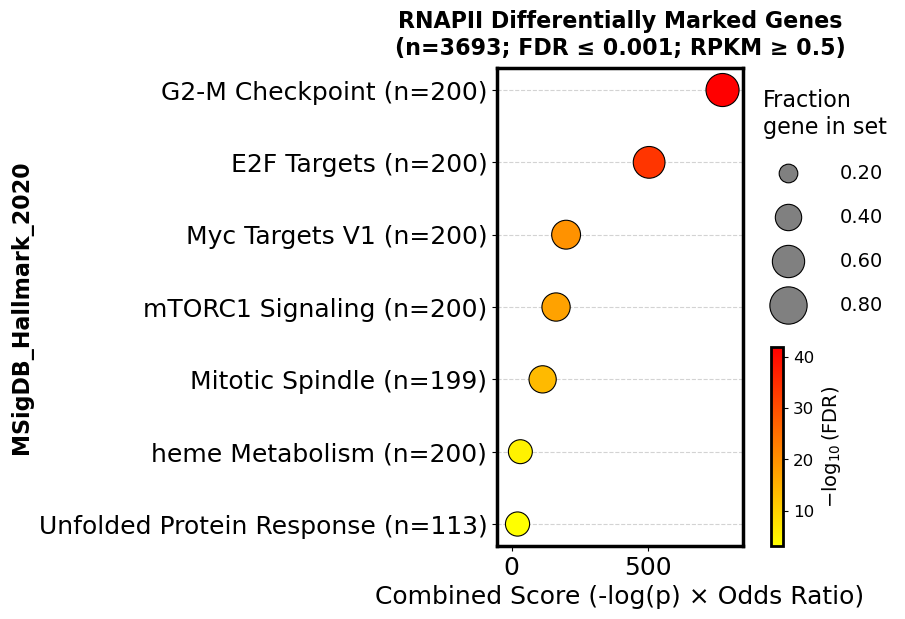

In [19]:
plot_enrichr_bubble(res, 
                    top_n=7, 
                    n_input_genes=len(df_fc), 
                    fdr_max=FDR, 
                    rpkm_min=rpkm_thresh,
                   library_label=gene_set_name,
                    xpad_frac=0.1
                   )
plt.savefig(os.path.join(fig_dir, "20260218_Sup11a_RNAPII_DEG_GO_MSIGDB2020.pdf"), bbox_inches="tight")
plt.show()

/loc/scratch/47691954/ipykernel_28531/2132009978.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/loc/scratch/47691954/ipykernel_28531/2132009978.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_fc.groupby("max").size().reindex(stage_order, fill_value=0)


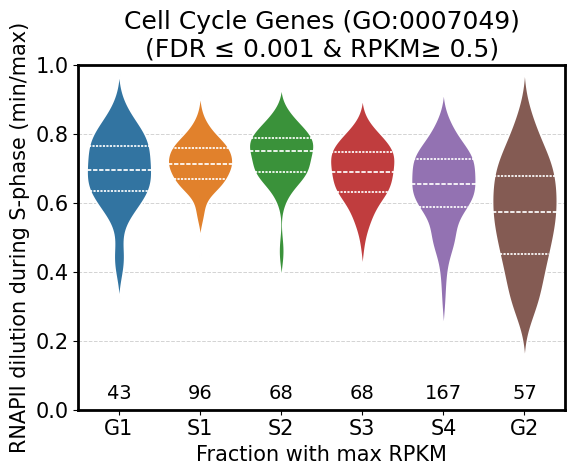

In [302]:
import seaborn as sns
import matplotlib.pyplot as plt

# — assume df_fc is your filtered DataFrame,
#   and df_fc['max'] is already an ordered Categorical with stage_order —
FDR = 0.001
rpkm_thresh = 0.5
df_fc = df[df['in_cell_cycle'] & (df['FDR_allTP'] < FDR) & (df["max_RPKM"] >= rpkm_thresh)]
stage_order = ["G1", "S1", "S2", "S3", "S4", "G2"]

# 1) pick a palette
palette = sns.color_palette("tab10", n_colors=len(stage_order))

# 2) plot only the violins
fig, ax = plt.subplots(figsize=(6,5))
sns.violinplot(
    x="max", y="ratio",
    data=df_fc,
    order=stage_order,
    palette=palette,
    inner="quartile",
    zorder=2,
    # bw_adjust=1.5,
    # cut=0,
    linecolor="white",
    ax=ax
)

# 3) annotate counts at a fixed y (just above 0)
counts = df_fc.groupby("max").size().reindex(stage_order, fill_value=0)
for i, stage in enumerate(stage_order):
    ax.text(
        i,           # x position
        0.02,        # y position
        str(counts[stage]),
        ha="center",
        va="bottom",
        fontsize=14
    )

# 4) fix y‐limits
ax.set_ylim(0, 1)
ax.grid(axis='y', color='lightgray', linestyle='--', linewidth=0.7,zorder=1)
# 5) labels & title
ax.set_xlabel("Fraction with max RPKM")
ax.set_ylabel("RNAPII dilution during S-phase (min/max)")
ax.set_title(f"Cell Cycle Genes (GO:0007049)\n(FDR ≤ {FDR} & RPKM≥ {rpkm_thresh})")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "20260218_Sup11b_cell_cycle_GO_violin.pdf"), bbox_inches="tight")

plt.show()

In [152]:
plot_df, max = get_norm_df(df_fc) 
plot_df['maxRPKM'] = df_fc['max']

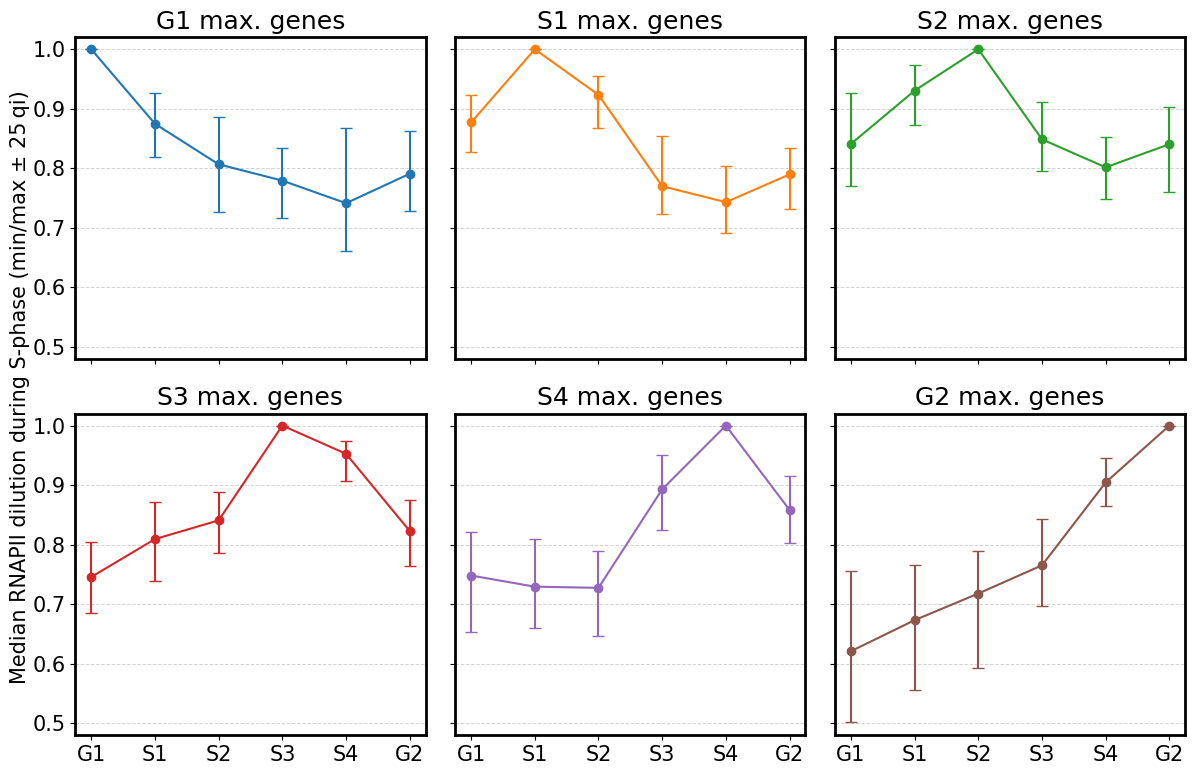

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Stages (x axis order)
order = ["G1", "S1", "S2", "S3", "S4", "G2"]

# 2) Ensure we have both maxRPKM and the stage columns available after reset_index
df = plot_df.copy()
df = df.reset_index()

# If maxRPKM ended up as the index name, bring it back (common pattern)
if "maxRPKM" not in df.columns and df.columns[0] == "index":
    df = df.rename(columns={"index": "maxRPKM"})

# 3) Melt to long form
melted = df.melt(
    id_vars=["maxRPKM"],
    value_vars=order,
    var_name="stage",
    value_name="dilution",
)

# 4) Enforce categorical ordering on stage
melted["stage"] = pd.Categorical(melted["stage"], categories=order, ordered=True)

# 5) Summarize (per peak group, per stage)
summary = (
    melted.groupby(["maxRPKM", "stage"], observed=True)["dilution"]
    .agg(
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75),
    )
    .reset_index()
)

# 6) Fixed panel order (use your labels if you already defined them, else default to order)
labels = order
group_order = labels

palette = sns.color_palette("tab10", n_colors=len(group_order))
colors = dict(zip(group_order, palette))

# 7) Build a 2 by 3 grid
fig, axes = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(12, 8))
axes = axes.flatten()

# 8) Plot each maxRPKM group in its fixed position
stage_to_x = {s: i for i, s in enumerate(order)}

for ax, grp in zip(axes, group_order):
    grp_df = summary[summary["maxRPKM"] == grp].sort_values("stage")
    x = grp_df["stage"].map(stage_to_x).to_numpy()

    y = grp_df["median"].to_numpy()
    yerr = np.vstack(
        [
            (grp_df["median"] - grp_df["q25"]).to_numpy(),
            (grp_df["q75"] - grp_df["median"]).to_numpy(),
        ]
    )

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="-o",
        capsize=4,
        color=colors[grp],
    )
    ax.grid(axis="y", color="lightgray", linestyle="--", linewidth=0.7, zorder=0)
    ax.set_ylim(0.48, 1.02)

    ax.set_title(f"{grp} max. genes") 
    ax.set_xticks(range(len(labels))) 
    ax.set_xticklabels(labels, rotation=0) 

# 7) Remove any empty panels (if fewer than 6 groups) 
for ax in axes[len(group_order):]: 
    fig.delaxes(ax) 

# 8) Add shared Y-label and layout 
fig.text(0.0, 0.5, "Median RNAPII dilution during S‑phase (min/max ± 25 qi)", 
         va="center", rotation="vertical") 
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "20260218_Sup11c_cell_cycle_trends.pdf"), bbox_inches="tight")

plt.show()


In [220]:
#save
df_fc.to_csv(f"{out_dir}/RNAPII_cellCycle_0.0001.csv", index=True)